# Telco customer churn report
## Purpose：Reduce Churn and Boost Revenue 

- Data Set： A company provided home phone and Internet services to 7043 customers IN Q3
- This Notebook includes EDA to identify business problems, build K-means models (classification) for customer groups, and predict customer churn probability using XGBoost.

In [2]:
##Import package
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats.contingency import association
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
# 设置中文字体，防止图表中的中文显示为方块
plt.rcParams['font.sans-serif'] = ['Heiti TC']  # Windows用SimHei，Mac用Arial Unicode MS
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font="Arial Unicode MS") 
import time

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [3]:
## Data_read
churn = pd.read_excel('./CustomerChurn.xlsx',index_col = 0)
tel_churn= pd.read_excel('./Telco_customer_churn.xlsx')
popu= pd.read_excel('./Telco_customer_churn_population.xlsx',index_col = 0)
services = pd.read_excel('./Telco_customer_churn_services.xlsx')
demo = pd.read_excel('./Telco_customer_churn_demographics.xlsx')
loc=pd.read_excel('./Telco_customer_churn_location.xlsx',index_col = 0)
status = pd.read_excel('./Telco_customer_churn_status.xlsx')



In [259]:
## Merge
tel_churn = tel_churn.rename(columns={"CustomerID":'Customer ID', "Payment Method":"Detail_pay_method"})
df = (
    services
    .merge(status[["Customer ID", "Churn Value", "Churn Label",
                   "CLTV", "Satisfaction Score",
                   "Churn Category", "Churn Reason",'Customer Status']],
           on="Customer ID")
    .merge(demo[["Customer ID", "Age", "Gender", "Married"]],
           on="Customer ID")
    .merge(tel_churn[['Customer ID','Detail_pay_method']],on="Customer ID")
)
df.loc[(df['Payment Method']== "Credit Card") & (df['Detail_pay_method']=='Mailed check'),'Detail_pay_method']= "Credit_Mailed_check"
df['Old']= np.where(df['Tenure in Months'] >= 9, 'Old', 'New') ## tenure in 9 month count as the new customer

### 1. Descriptive analysis （Overview churned rate)

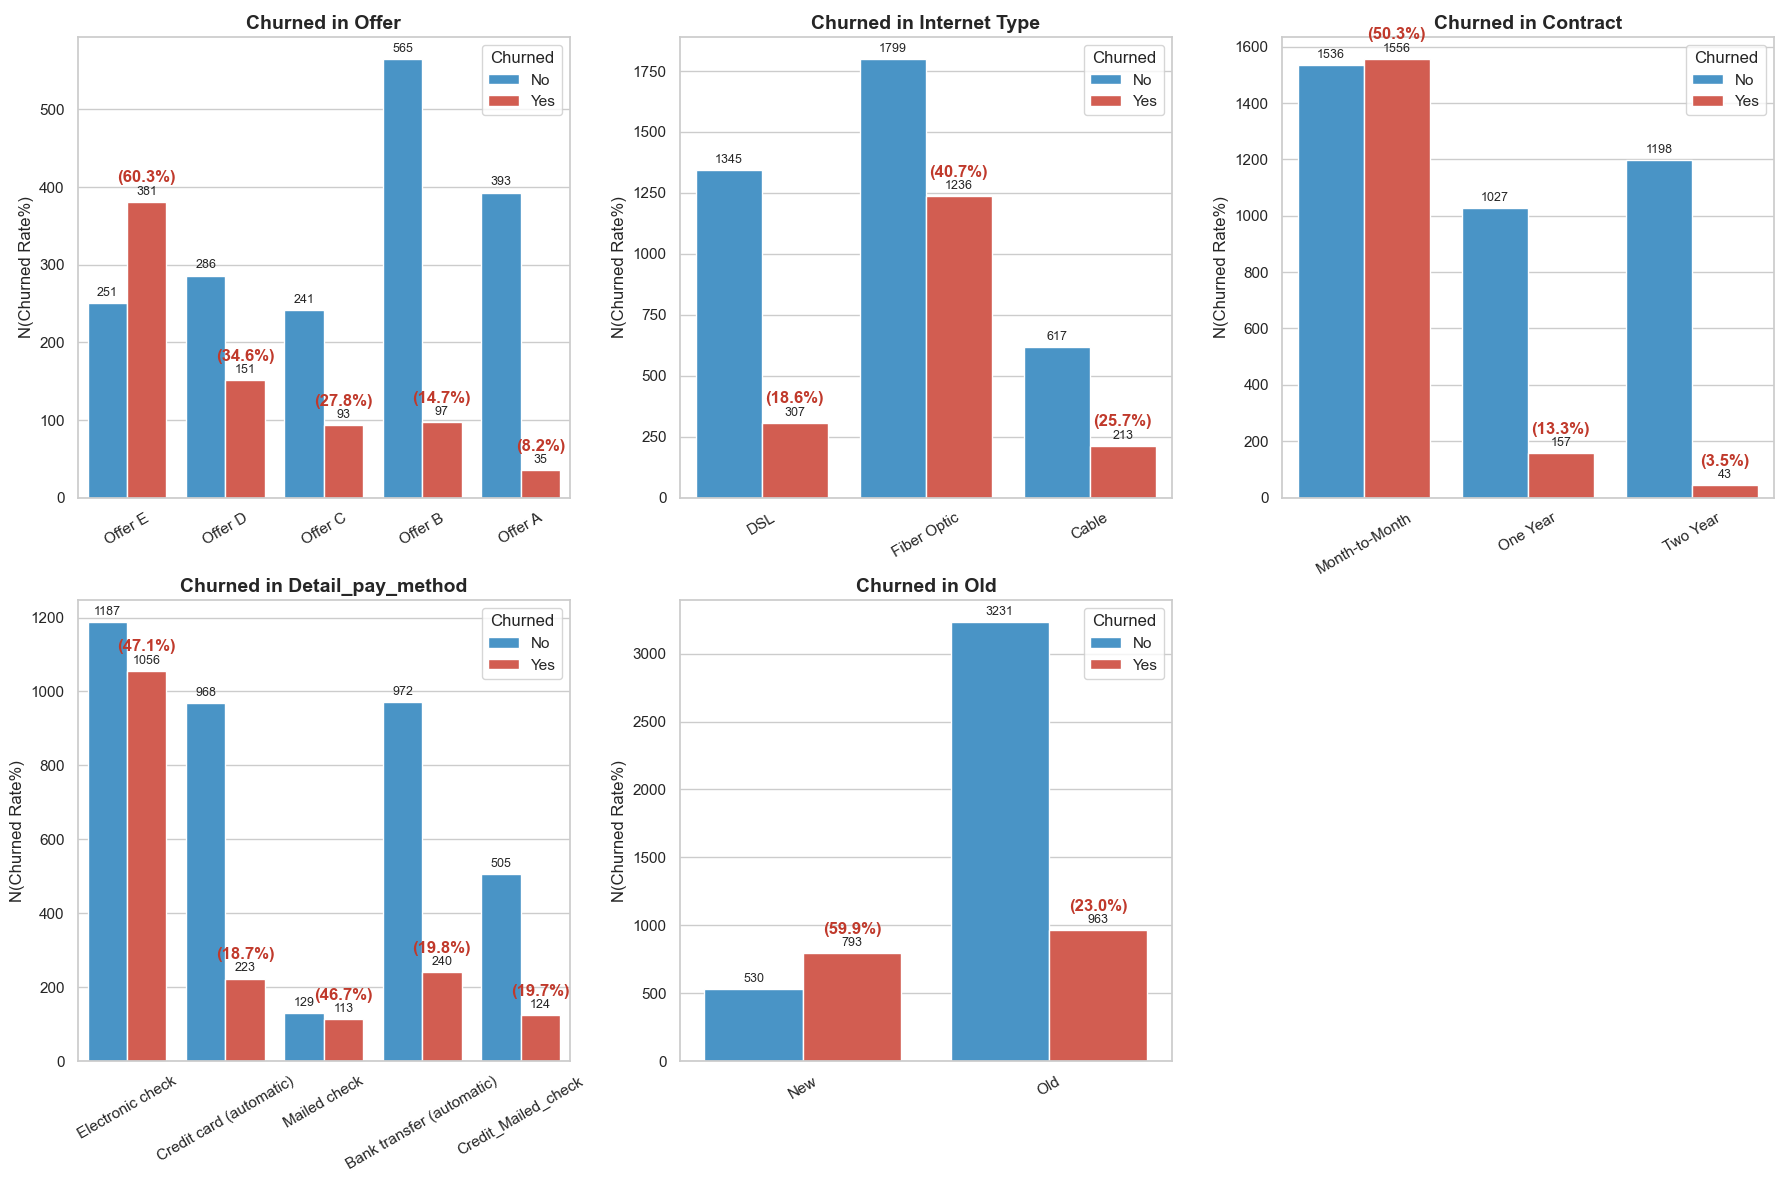

In [162]:


plt.rcParams['axes.unicode_minus'] = False

features = ['Offer', 'Internet Type', 'Contract', 'Detail_pay_method', 'Old']
target_col = 'Churn Label'
hue_order = ['No', 'Yes'] # 顯式指定順序：0為No(藍), 1為Yes(紅)

# 篩選有網路服務的用戶
df_net = df[(df['Internet Service'] == 'Yes')].copy()

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    # 1. 繪製計數圖，顯式指定 hue_order 確保 No 在左(0)，Yes 在右(1)
    ax = sns.countplot(
        data=df_net, 
        x=feature, 
        hue=target_col, 
        hue_order=hue_order, 
        ax=axes[i], 
        palette=['#3498db', '#e74c3c']
    )
    
    # 2. 精確計算每個類別下的流失率 (Yes / Total)
    # 使用 crosstab 確保即使某個類別流失為 0 也能正確對齊
    ct = pd.crosstab(df_net[feature], df_net[target_col])
    if 'Yes' not in ct.columns: ct['Yes'] = 0
    if 'No' not in ct.columns: ct['No'] = 0
    
    # 計算流失率：Yes / (Yes + No)
    churn_rate_map = (ct['Yes'] / (ct['Yes'] + ct['No']) * 100).round(1)

    # 3. 標注數值與流失率
    # ax.containers[0] 對應 hue_order 中的第一個 ('No')
    # ax.containers[1] 對應 hue_order 中的第二個 ('Yes')
    
    # 標注留存人數 (No)
    ax.bar_label(ax.containers[0], fmt='%d', padding=3, fontsize=9)
    
    # 標注流失人數 (Yes) 並在上方加上流失率
    yes_container = ax.containers[1]
    ax.bar_label(yes_container, fmt='%d', padding=3, fontsize=9)
    
    # 獲取當前 X 軸標籤的順序，以匹配 churn_rate_map
    x_labels = [t.get_text() for t in ax.get_xticklabels()]
    current_rates = [churn_rate_map.get(label, 0) for label in x_labels]
    
    # 額外標注流失率百分比
    labels_with_rate = [f'\n({r}%)' for r in current_rates]
    ax.bar_label(yes_container, labels=labels_with_rate, label_type='edge', 
                 color='#c0392b', fontweight='bold', padding=12)

    # 4. 樣式優化
    ax.set_title(f'Churned in {feature}', fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('N(Churned Rate%)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Churned', labels=['No', 'Yes'], loc='upper right')

# 移除多餘子圖
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Find out from the chart 
     1.Offer E over 60% churned rate
     2.Over 40% churned customer Chosen Fiber Optic
     3.50% of M2M contract churned
     4.OlD and New customers both churned in high rate
    
     

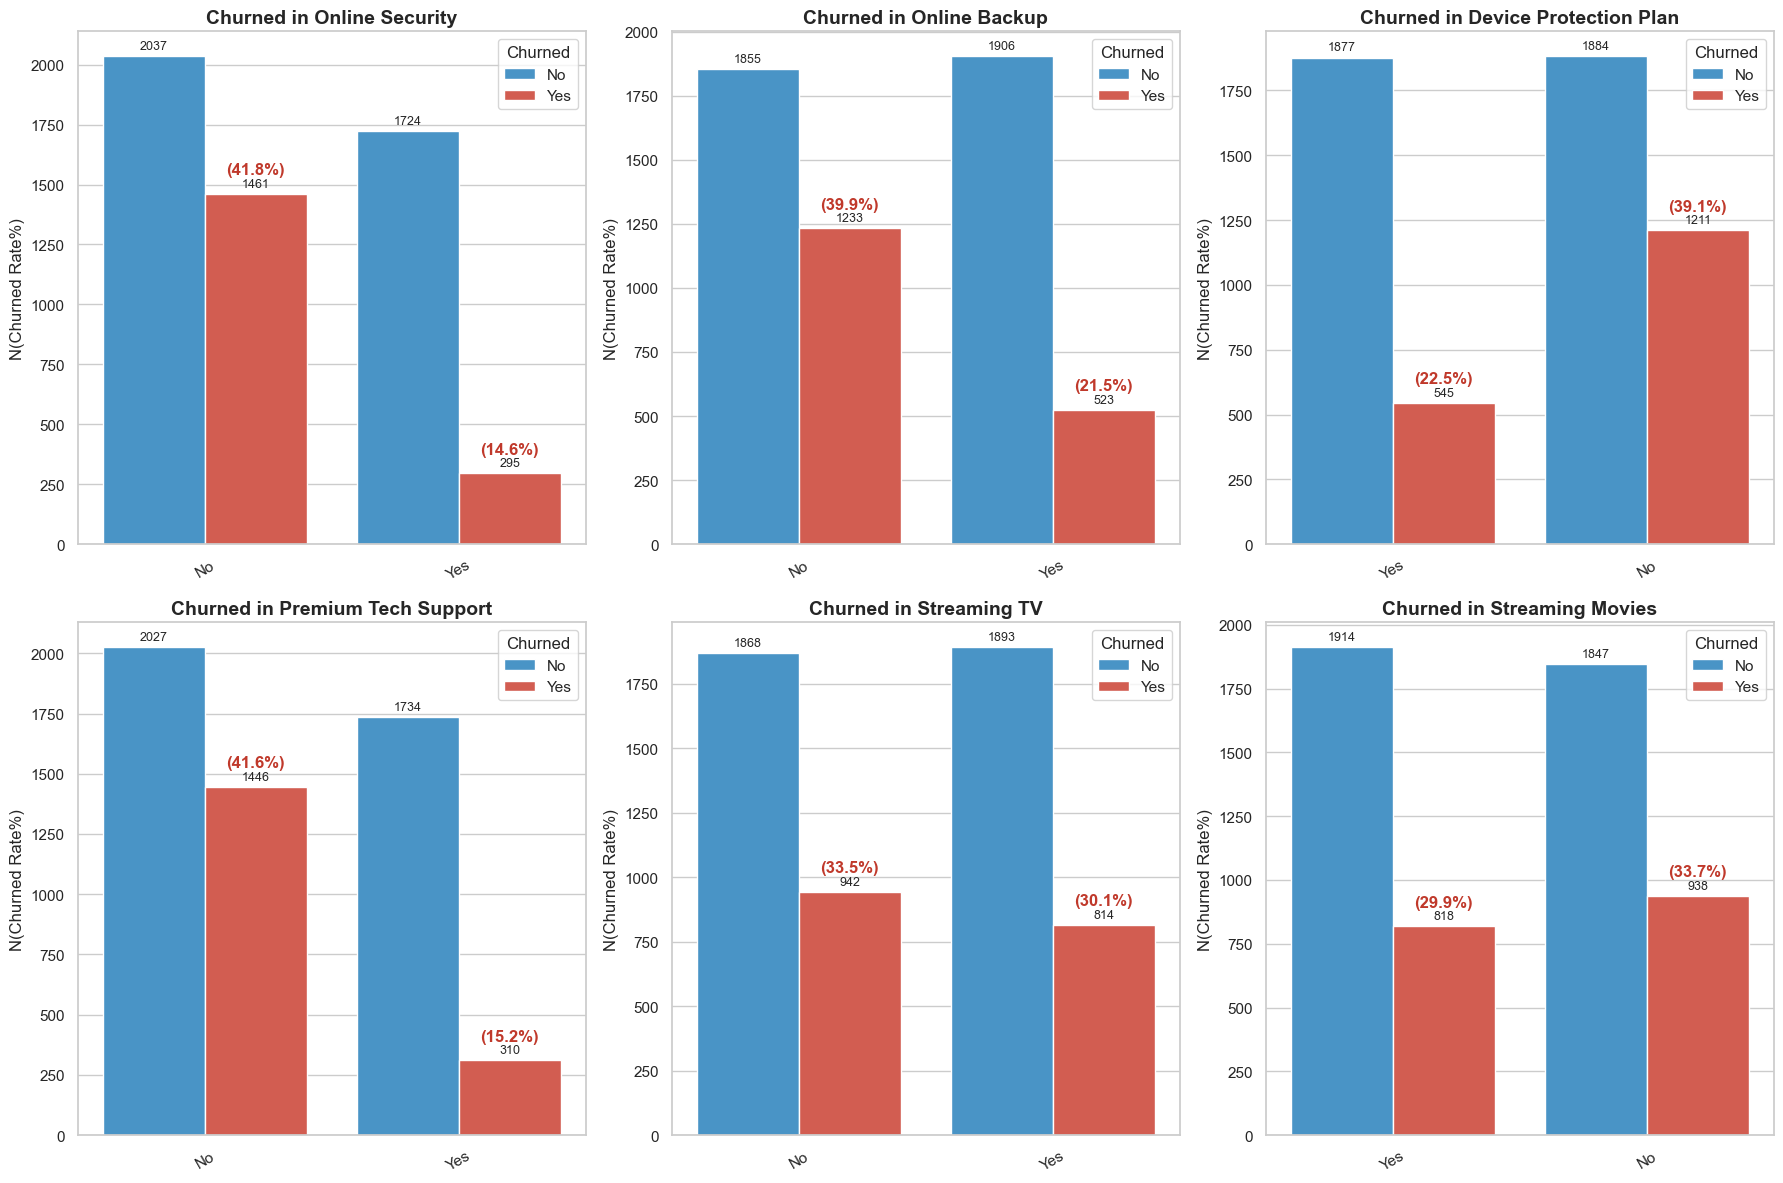

In [36]:
#protection_features = ['Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support']
#streaming_features = ['Streaming TV', 'Streaming Movies']



plt.rcParams['axes.unicode_minus'] = False

features = ['Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support','Streaming TV', 'Streaming Movies']
target_col = 'Churn Label'
hue_order = ['No', 'Yes'] # 顯式指定順序：0為No(藍), 1為Yes(紅)

# 篩選有網路服務的用戶
df_net = df[df['Internet Service'] == 'Yes'].copy()

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    # 1. 繪製計數圖，顯式指定 hue_order 確保 No 在左(0)，Yes 在右(1)
    ax = sns.countplot(
        data=df_net, 
        x=feature, 
        hue=target_col, 
        hue_order=hue_order, 
        ax=axes[i], 
        palette=['#3498db', '#e74c3c']
    )
    
    # 2. 精確計算每個類別下的流失率 (Yes / Total)
    # 使用 crosstab 確保即使某個類別流失為 0 也能正確對齊
    ct = pd.crosstab(df_net[feature], df_net[target_col])
    if 'Yes' not in ct.columns: ct['Yes'] = 0
    if 'No' not in ct.columns: ct['No'] = 0
    
    # 計算流失率：Yes / (Yes + No)
    churn_rate_map = (ct['Yes'] / (ct['Yes'] + ct['No']) * 100).round(1)

    # 3. 標注數值與流失率
    # ax.containers[0] 對應 hue_order 中的第一個 ('No')
    # ax.containers[1] 對應 hue_order 中的第二個 ('Yes')
    
    # 標注留存人數 (No)
    ax.bar_label(ax.containers[0], fmt='%d', padding=3, fontsize=9)
    
    # 標注流失人數 (Yes) 並在上方加上流失率
    yes_container = ax.containers[1]
    ax.bar_label(yes_container, fmt='%d', padding=3, fontsize=9)
    
    # 獲取當前 X 軸標籤的順序，以匹配 churn_rate_map
    x_labels = [t.get_text() for t in ax.get_xticklabels()]
    current_rates = [churn_rate_map.get(label, 0) for label in x_labels]
    
    # 額外標注流失率百分比
    labels_with_rate = [f'\n({r}%)' for r in current_rates]
    ax.bar_label(yes_container, labels=labels_with_rate, label_type='edge', 
                 color='#c0392b', fontweight='bold', padding=12)

    # 4. 樣式優化
    ax.set_title(f'Churned in {feature}', fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('N(Churned Rate%)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Churned', labels=['No', 'Yes'], loc='upper right')

# 移除多餘子圖
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 2.Dive in to the detail

#### 1. Offer E is the latest plan. And consider offer E high churned rate caused by the monthly charge? 

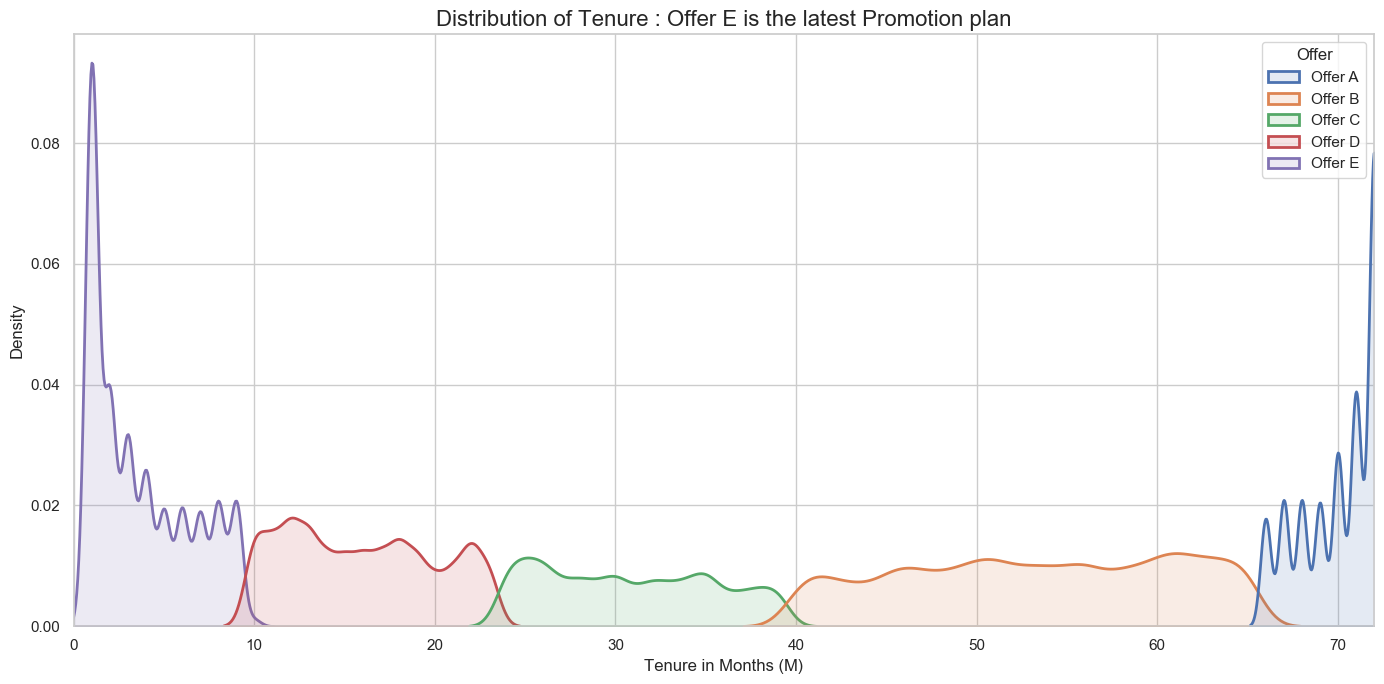

In [274]:
offers_ae = df[df['Offer'].isin(['Offer A', 'Offer B', 'Offer C', 'Offer D', 'Offer E'])].copy()

# 2. 設置繪圖風格
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# 3. 繪製 KDE Plot
# bw_adjust 调小一点（如 0.5）可以看清更细微的波动
ax = sns.kdeplot(data=offers_ae, x='Tenure in Months', hue='Offer', 
                 hue_order=['Offer A', 'Offer B', 'Offer C', 'Offer D', 'Offer E'],
                 bw_adjust=0.5, fill=True, alpha=0.15, linewidth=2)


# 5. 圖表美化
plt.title('Distribution of Tenure : Offer E is the latest Promotion plan', fontsize=16, fontweight='bold', fontname='Arial Unicode MS')
plt.xlabel('Tenure in Months (M)', fontsize=12, fontname='Arial Unicode MS')
plt.ylabel('Density', fontsize=12, fontname='Arial Unicode MS')
plt.xlim(0, 72) 

plt.tight_layout()
plt.show()

#### 2. Two points can be observed from the chart: 
1. Offer E offers the most favorable price compared to previous offers.
2. The main advantage of Offer E is not in Fiber Optic; the average monthly price is lower for the option without a plan compared to the option with a plan.

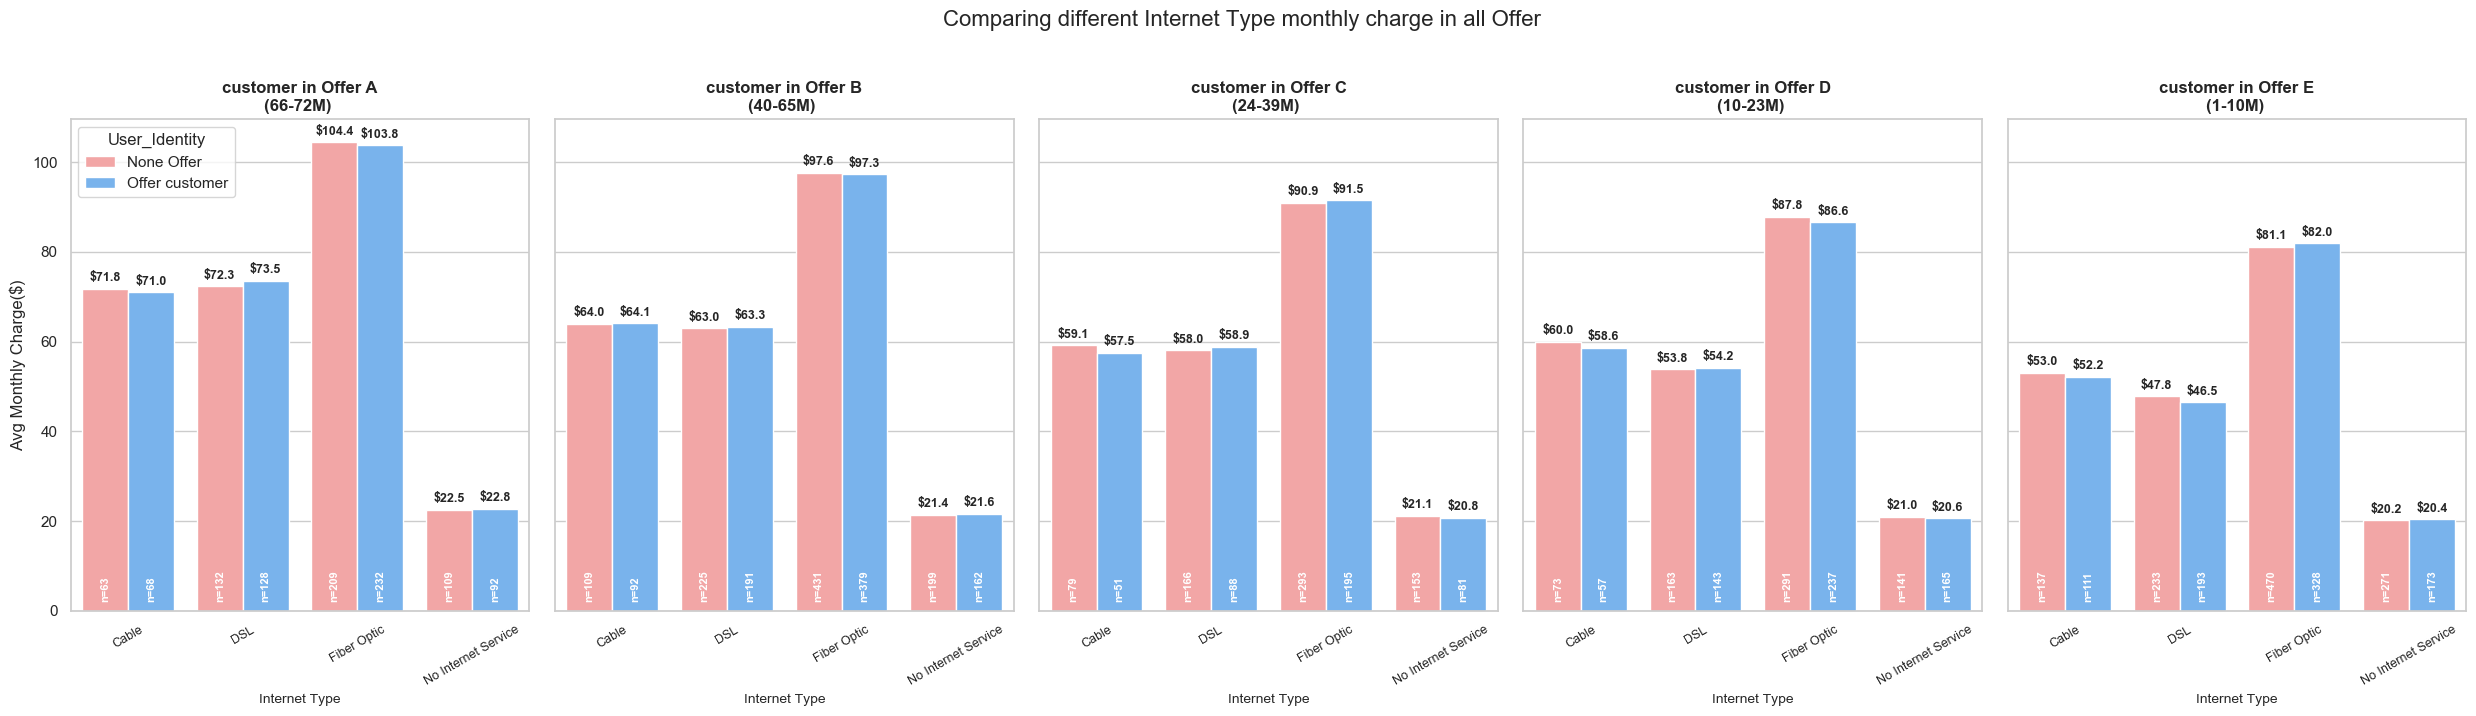

In [280]:
df_all_cohorts['Internet_Type_Clean'] = df_all_cohorts['Internet Type'].fillna('No Internet Service')

# 按同期群、网络类型、是否有套餐聚合
net_cohort_summary = df_all_cohorts.groupby(['Cohort_Label', 'Internet_Type_Clean', 'Offer_Group']).agg(
    平均月费=('Monthly Charge', 'mean'),
    样本量=('Monthly Charge', 'count')
).reset_index()

# 映射分类标签，让 Hue 的图例更容易读
net_cohort_summary['User_Identity'] = np.where(net_cohort_summary['Offer_Group'] == 'None Offer', 'None Offer', 'Offer customer')

# 创建一个 1行 5列 的子图大画布，横向一字排开对比 A, B, C, D, E 五个生命周期群
cohort_order = [c for c in df_all_cohorts['Cohort_Label'].unique() if 'Offer' in c]
fig, axes = plt.subplots(1, len(cohort_order), figsize=(25, 7), sharey=True)
sns.set_style("whitegrid")

net_order = ['Cable', 'DSL', 'Fiber Optic', 'No Internet Service']

for idx, cohort_name in enumerate(sorted(cohort_order)):
    df_sub = net_cohort_summary[net_cohort_summary['Cohort_Label'] == cohort_name]
    
    ax = sns.barplot(
        ax=axes[idx], data=df_sub, x='Internet_Type_Clean', y='平均月费', 
        hue='User_Identity', hue_order=['None Offer', 'Offer customer'],
        order=net_order, palette=['#ff9999', '#66b3ff']
    )
    
    axes[idx].set_title(f'customer in {cohort_name} ', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Internet Type', fontsize=10, fontname='Arial Unicode MS')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=30, fontsize=9)
    
    if idx == 0:
        axes[idx].set_ylabel('Avg Monthly Charge($)', fontsize=12, fontname='Arial Unicode MS')
    else:
        axes[idx].set_ylabel('')
        axes[idx].get_legend().remove() # 只保留第一个子图的图例，防止画面混乱

    # 在柱子顶部标注价格，底部标注样本量 n
    for hue_l, container in enumerate(ax.containers):
        current_identity = 'None Offer' if hue_l == 0 else 'Offer customer'
        for n_l, bar in enumerate(container):
            n_type = net_order[n_l]
            row = df_sub[(df_sub['User_Identity'] == current_identity) & (df_sub['Internet_Type_Clean'] == n_type)]
            if not row.empty:
                p_val = row['平均月费'].values[0]
                n_val = row['样本量'].values[0]
                x_c = bar.get_x() + bar.get_width() / 2
                
                # 标记价格
                axes[idx].text(x_c, p_val + 1, f"${p_val:.1f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
                # 柱子底部打印样本量
                axes[idx].text(x_c, 2, f"n={n_val}", ha='center', va='bottom', color='white', fontsize=8, fontweight='bold', rotation=90)

plt.suptitle('Comparing different Internet Type monthly charge in all Offer', fontsize=16, fontweight='bold', y=1.02, fontname='Arial Unicode MS')
plt.tight_layout()
plt.show()

#### 3. To prevent previous offers from being based on different pricing for VAS (Value Added Service), we've broken down the fiber optic pricing into options with and No VAS for comparison. 
1. Regardless of whether VAS is included, Offer E's monthly fee is higher than the option without VAS.
2. The company doesn't offer many network discounts for fiber optic connections.

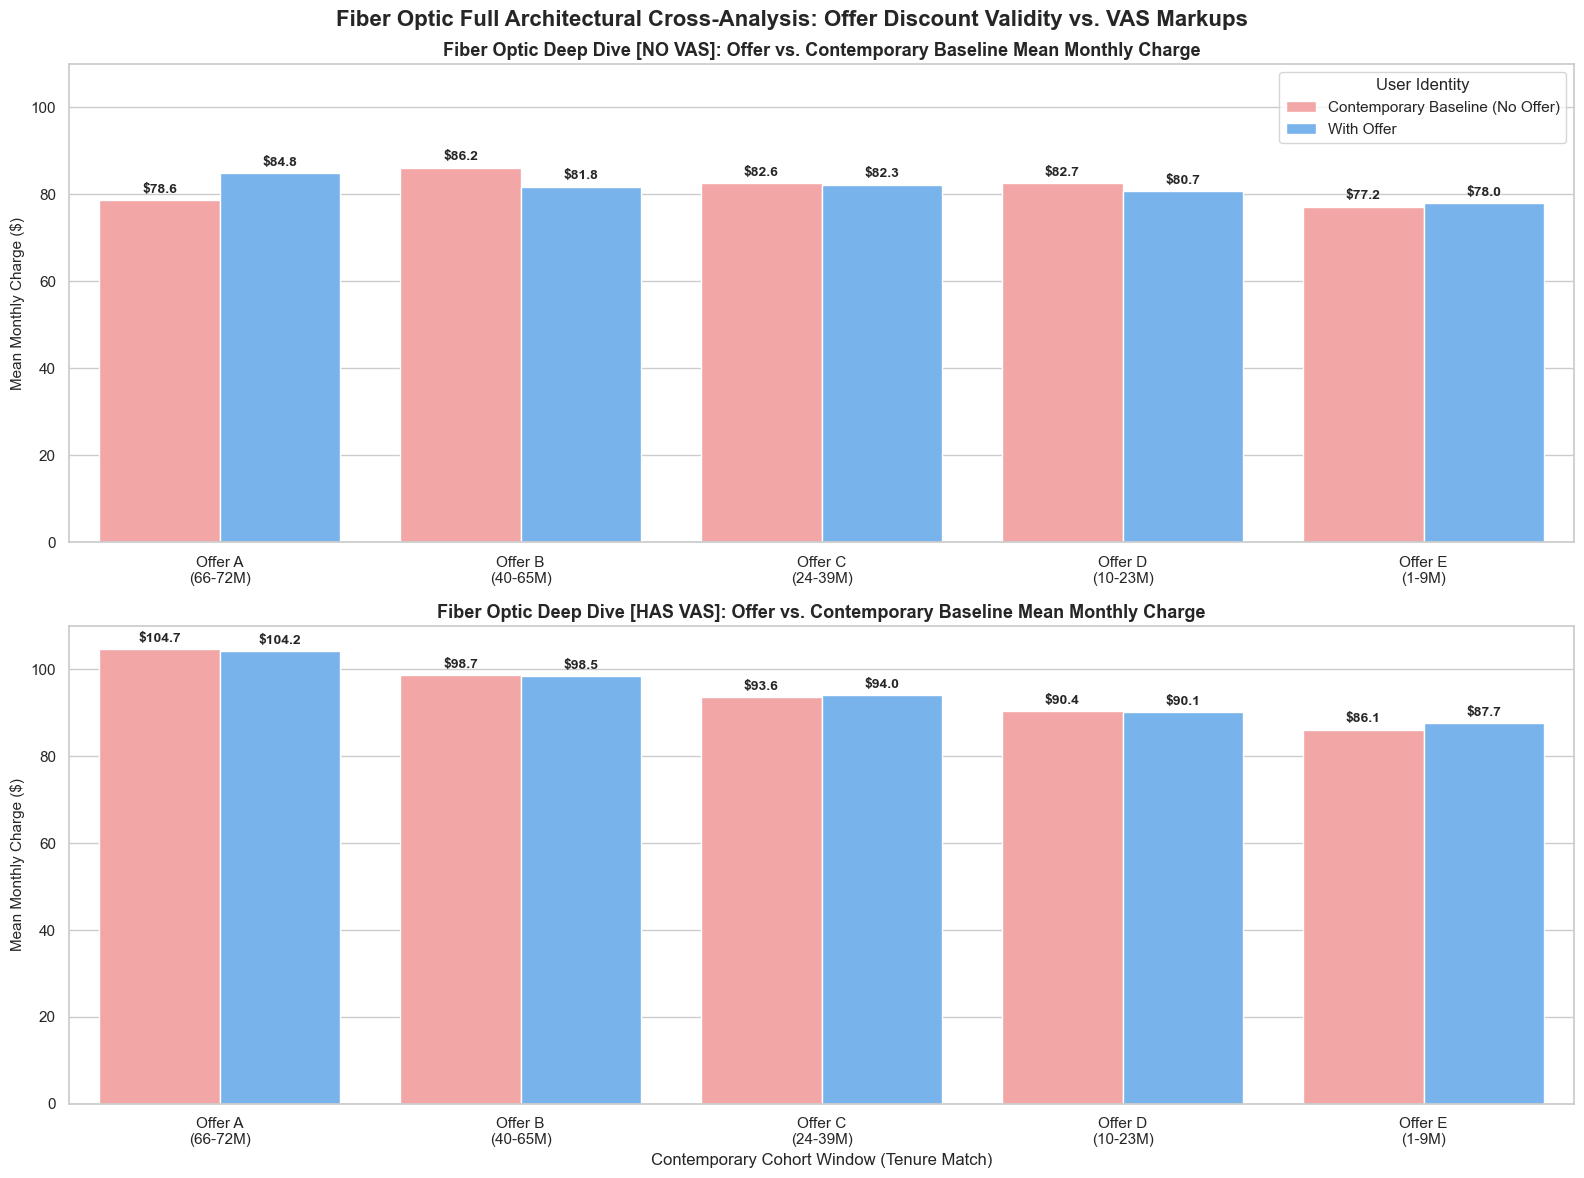

In [226]:
# =========================================================================
# 1. Data Processing: Slice Contemporary Cohorts for Fiber Optic Users
# =========================================================================
df_fiber_cohort = df[df['Internet Type'] == 'Fiber Optic'].copy()
df_fiber_cohort['Offer_Group'] = df_fiber_cohort['Offer'].fillna('None Offer')

# Define the 4 Value-Added Services (VAS) and evaluate status
vas_cols = ['Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support']
df_fiber_cohort['VAS_Count'] = (df_fiber_cohort[vas_cols] == 'Yes').sum(axis=1)
df_fiber_cohort['VAS_Status'] = np.where(df_fiber_cohort['VAS_Count'] > 0, 'Has VAS', 'No VAS')

offers = ['Offer A', 'Offer B', 'Offer C', 'Offer D', 'Offer E']
processed_chunks = []

for off in offers:
    # Dynamically capture the exact tenure boundaries for the current offer
    off_tenure = df_fiber_cohort[df_fiber_cohort['Offer_Group'] == off]['Tenure in Months']
    if len(off_tenure) == 0: continue
    
    min_t, max_t = int(off_tenure.min()), int(off_tenure.max())
    
    # 1. Slice current offer users
    df_off = df_fiber_cohort[df_fiber_cohort['Offer_Group'] == off].copy()
    df_off['Identity'] = 'With Offer'
    df_off['Cohort_Label'] = f"{off}\n({min_t}-{max_t}M)"
    
    # 2. Slice contemporary baseline (None Offer) users within the exact same tenure range
    df_base = df_fiber_cohort[
        (df_fiber_cohort['Offer_Group'] == 'None Offer') & 
        (df_fiber_cohort['Tenure in Months'] >= min_t) & 
        (df_fiber_cohort['Tenure in Months'] <= max_t)
    ].copy()
    df_base['Identity'] = 'Contemporary Baseline (No Offer)'
    df_base['Cohort_Label'] = f"{off}\n({min_t}-{max_t}M)"
    
    processed_chunks.extend([df_off, df_base])

# Combine everything into a clean analytical summary
df_final_cohort = pd.concat(processed_chunks, ignore_index=True)

fiber_summary = df_final_cohort.groupby(['Cohort_Label', 'VAS_Status', 'Identity']).agg(
    Mean_Charge=('Monthly Charge', 'mean'),
    Sample_Size=('Monthly Charge', 'count')
).reset_index()

# Sort by Offer A-E sequence
cohort_order = sorted(fiber_summary['Cohort_Label'].unique())
fiber_summary['Cohort_Label'] = pd.Categorical(fiber_summary['Cohort_Label'], categories=cohort_order, ordered=True)
fiber_summary = fiber_summary.sort_values('Cohort_Label')


# =========================================================================
# 2. Plotting: 2-Row Deep Dive Dashboard (No VAS vs. Has VAS)
# =========================================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharey=True)
sns.set_style("whitegrid")

# Color mapping: Light Blue for Offer users, Light Pink for Baseline users
color_palette = {'With Offer': '#66b3ff', 'Contemporary Baseline (No Offer)': '#ff9999'}
identity_order = ['Contemporary Baseline (No Offer)', 'With Offer']

# -------------------------------------------------------------------------
# Top Plot (Axes[0]): NO VAS (Bare Fiber Pack) Monthly Charge Comparison
# -------------------------------------------------------------------------
df_no_vas = fiber_summary[fiber_summary['VAS_Status'] == 'No VAS']
ax1 = sns.barplot(
    ax=axes[0], data=df_no_vas, x='Cohort_Label', y='Mean_Charge', 
    hue='Identity', hue_order=identity_order, palette=color_palette
)
axes[0].set_title('Fiber Optic Deep Dive [NO VAS]: Offer vs. Contemporary Baseline Mean Monthly Charge', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Mean Monthly Charge ($)', fontsize=11)
axes[0].set_xlabel('') # Clear X-label for upper row to keep it sleek
axes[0].legend(title='User Identity', loc='upper right')

# Add values & sample sizes labels on bars for Top Chart
for container in ax1.containers:
    ax1.bar_label(container, fmt='$%.1f', padding=3, fontsize=10, fontweight='bold')

# -------------------------------------------------------------------------
# Bottom Plot (Axes[1]): HAS VAS (Value-Added Pack) Monthly Charge Comparison
# -------------------------------------------------------------------------
df_has_vas = fiber_summary[fiber_summary['VAS_Status'] == 'Has VAS']
ax2 = sns.barplot(
    ax=axes[1], data=df_has_vas, x='Cohort_Label', y='Mean_Charge', 
    hue='Identity', hue_order=identity_order, palette=color_palette
)
axes[1].set_title('Fiber Optic Deep Dive [HAS VAS]: Offer vs. Contemporary Baseline Mean Monthly Charge', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mean Monthly Charge ($)', fontsize=11)
axes[1].set_xlabel('Contemporary Cohort Window (Tenure Match)', fontsize=12)
axes[1].get_legend().remove() # Remove redundant duplicate legend

# Add values & sample sizes labels on bars for Bottom Chart
for container in ax2.containers:
    ax2.bar_label(container, fmt='$%.1f', padding=3, fontsize=10, fontweight='bold')

# Global plot configurations
plt.suptitle('Fiber Optic Full Architectural Cross-Analysis: Offer Discount Validity vs. VAS Markups', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

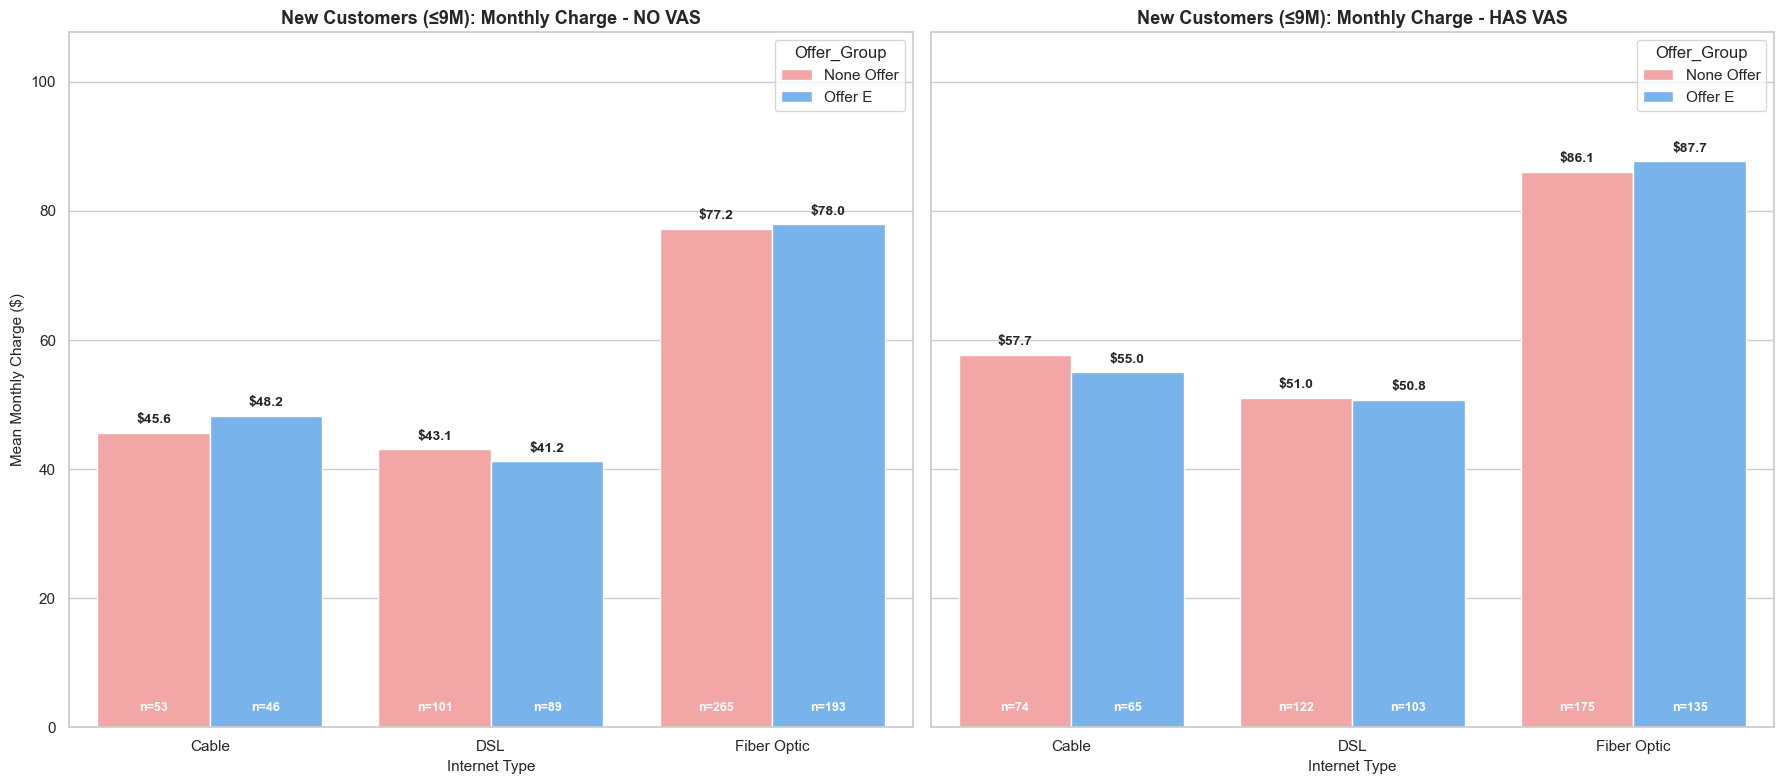

In [211]:
# Break down in internet type 
df_vas = df.copy()
df_vas['Offer_Group'] = df_vas['Offer'].fillna('None Offer')
df_new_vas = df_vas[
    (df_vas['Tenure in Months'] <= 9) & 
    (df_vas['Offer_Group'].isin(['Offer E', 'None Offer'])) & 
    (df_vas['Internet Service'] == 'Yes')  # 既然看网络类型，锁定有网络服务的用户
].copy()

# 2. 衍生变量：判断用户是否开通了任意增值服务
vas_cols = ['Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support']
# 计算每个用户开通的增值服务总数
df_new_vas['VAS_Count'] = (df_new_vas[vas_cols] == 'Yes').sum(axis=1)
# 映射为分类标签
df_new_vas['Has_VAS'] = np.where(df_new_vas['VAS_Count'] > 0, 'Has VAS (1-4)', 'No VAS (0)')

# 3. 聚合计算平均月费和样本量
vas_summary = df_new_vas.groupby(['Has_VAS', 'Internet Type', 'Offer_Group']).agg(
    平均月费=('Monthly Charge', 'mean'),
    样本量=('Monthly Charge', 'count')
).reset_index()

#print("=== 新用户 (≤9M) 在不同网络与增值服务下的平均月费统计 ===")
#print(vas_summary.round(2).to_string(index=False))


# 4. 开始画图：创建 1行 2列 的画布
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True) # 共享Y轴，方便直接肉眼对比高低
sns.set_style("whitegrid")

# 为了呼应你前序图表的色系：粉色代表 None Offer，蓝色代表 Offer E
color_map = {'None Offer': '#ff9999', 'Offer E': '#66b3ff'}
net_order = ['Cable', 'DSL', 'Fiber Optic']

# -------------------------------------------------------------------------
# 左图 (Ax 1)：纯裸机用户 (无任何增值服务 No VAS) 的月费对比
# -------------------------------------------------------------------------
df_no_vas = vas_summary[vas_summary['Has_VAS'] == 'No VAS (0)']
ax1 = sns.barplot(
    ax=axes[0], data=df_no_vas, x='Internet Type', y='平均月费', 
    hue='Offer_Group', hue_order=['None Offer', 'Offer E'], order=net_order, palette=color_map
)
axes[0].set_title('New Customers (≤9M): Monthly Charge - NO VAS', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Mean Monthly Charge ($)', fontsize=11)
axes[0].set_xlabel('Internet Type', fontsize=11)
axes[0].set_ylim(0, vas_summary['平均月费'].max() + 20)

# 为左图条形图精准贴上 价格标签 与 样本量n
for hue_idx, container in enumerate(ax1.containers):
    offer_grp = 'None Offer' if hue_idx == 0 else 'Offer E'
    for net_idx, bar in enumerate(container):
        net_type = net_order[net_idx]
        row = df_no_vas[(df_no_vas['Offer_Group'] == offer_grp) & (df_no_vas['Internet Type'] == net_type)]
        if not row.empty:
            price = row['平均月费'].values[0]
            n_sub = row['样本量'].values[0]
            x_pos = bar.get_x() + bar.get_width() / 2
            axes[0].text(x_pos, price + 1, f"${price:.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
            axes[0].text(x_pos, 2, f"n={n_sub}", ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')

# -------------------------------------------------------------------------
# 右图 (Ax 2)：有开增值服务 (Has VAS) 的月费对比
# -------------------------------------------------------------------------
df_has_vas = vas_summary[vas_summary['Has_VAS'] == 'Has VAS (1-4)']
ax2 = sns.barplot(
    ax=axes[1], data=df_has_vas, x='Internet Type', y='平均月费', 
    hue='Offer_Group', hue_order=['None Offer', 'Offer E'], order=net_order, palette=color_map
)
axes[1].set_title('New Customers (≤9M): Monthly Charge - HAS VAS', fontsize=13, fontweight='bold')
axes[1].set_ylabel('', fontsize=11) # 共享Y轴，右边不重复写Label
axes[1].set_xlabel('Internet Type', fontsize=11)

# 为右图条形图精准贴上 价格标签 与 样本量n
for hue_idx, container in enumerate(ax2.containers):
    offer_grp = 'None Offer' if hue_idx == 0 else 'Offer E'
    for net_idx, bar in enumerate(container):
        net_type = net_order[net_idx]
        row = df_has_vas[(df_has_vas['Offer_Group'] == offer_grp) & (df_has_vas['Internet Type'] == net_type)]
        if not row.empty:
            price = row['平均月费'].values[0]
            n_sub = row['样本量'].values[0]
            x_pos = bar.get_x() + bar.get_width() / 2
            axes[1].text(x_pos, price + 1, f"${price:.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
            axes[1].text(x_pos, 2, f"n={n_sub}", ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### 4. For new customers (<=9M), VAS has a certain retention effect on Cable and DSL networks, but considering the small size of n, the statistical effect is not high.Try to providing more VAS in Fiber service （with the hypthesis test, whatever New or Old)

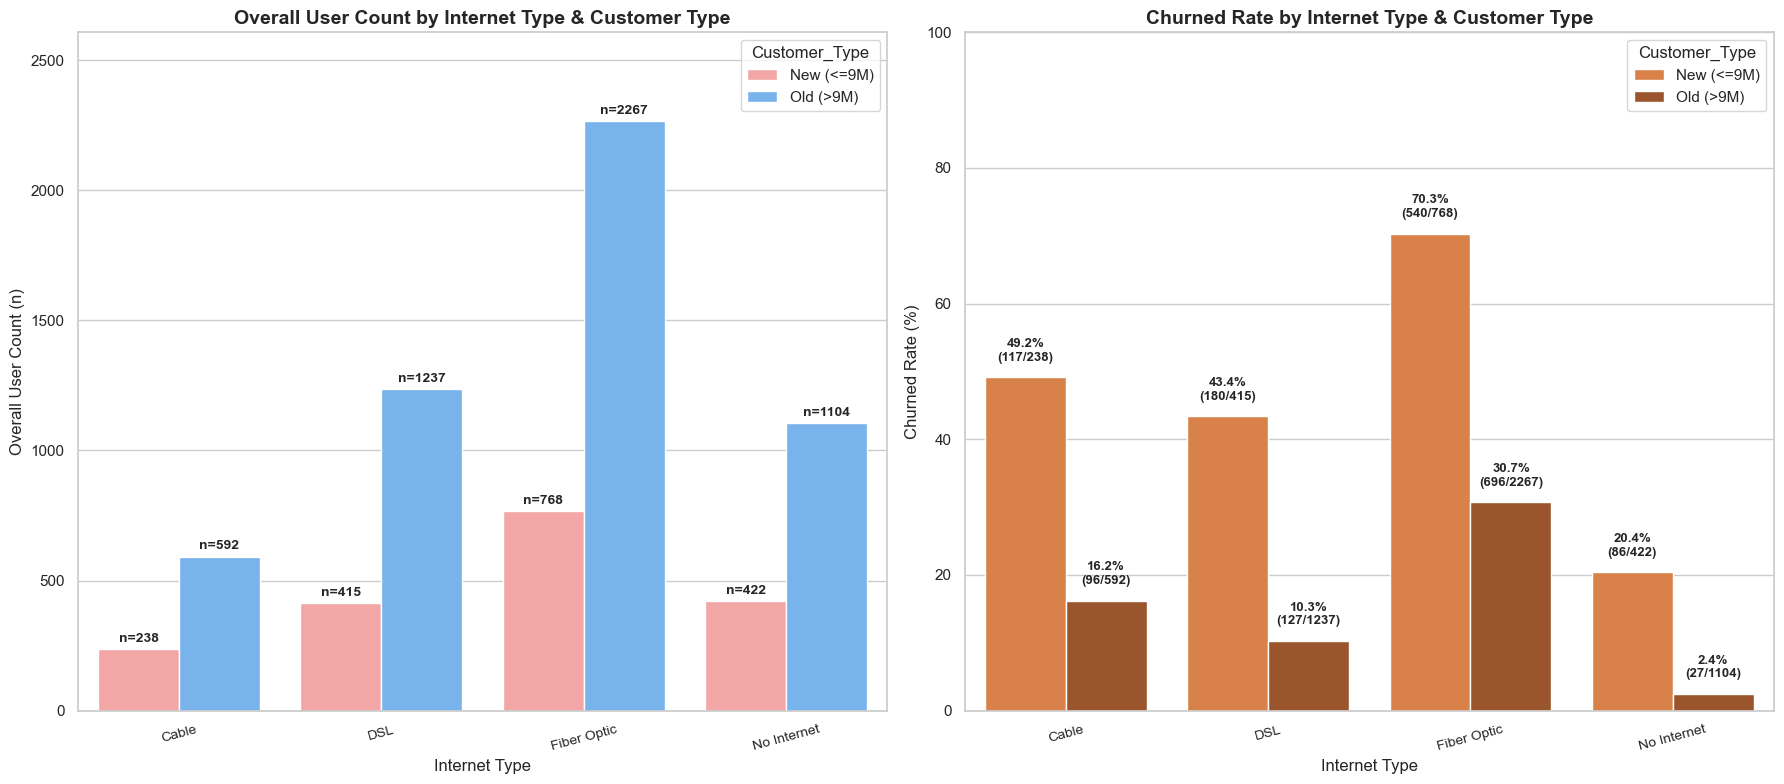

In [209]:
# =========================================================================
# 1. 數據準備：複製數據，定義新老用戶標籤 (以 9 個月為界)，處理空值
# =========================================================================
df_vis = df.copy()
tenure_threshold = 9  # 根據您截圖中的設定保持 9 個月
df_vis['Customer_Type'] = np.where(df_vis['Tenure in Months'] <= tenure_threshold, 'New (<=9M)', 'Old (>9M)')
df_vis['Internet_Type'] = df_vis['Internet Type'].fillna('No Internet') # 處理空網絡類型

# --- 數據聚合 A：用於左圖 (人數分佈) ---
all_summary = df_vis.groupby(['Customer_Type', 'Internet_Type', 'Churn Label']).size().reset_index(name='人數')

# --- 數據聚合 B：用於右圖 (流失率與流失人數對比) ---
churn_summary = df_vis.groupby(['Customer_Type', 'Internet_Type']).agg(
    总人数=('Churn Label', 'count'),
    流失人数=('Churn Label', lambda x: (x == 'Yes').sum()),
    流失率=('Churn Label', lambda x: (x == 'Yes').mean() * 100)
).reset_index()


# =========================================================================
# 2. 開始畫圖：創建 1行 2列 的畫布
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.set_style("whitegrid")

# -------------------------------------------------------------------------
# 左圖 (Ax 1)：新老用戶的 Internet Type 總人數分布 (保持您截圖中的風格)
# -------------------------------------------------------------------------
ax1 = sns.barplot(ax=axes[0], data=churn_summary, x='Internet_Type', y='总人数', hue='Customer_Type', palette=['#ff9999', '#66b3ff'])
axes[0].set_title('Overall User Count by Internet Type & Customer Type', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Overall User Count (n)', fontsize=12)
axes[0].set_xlabel('Internet Type', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, fontsize=10) 
axes[0].set_ylim(0, churn_summary['总人数'].max() * 1.15)

# 為左圖添加總人數標籤
for container in ax1.containers:
    ax1.bar_label(container, fmt='n=%d', padding=3, fontsize=10, fontweight='bold')


# -------------------------------------------------------------------------
# 右圖 (Ax 2)：不同網絡類型對應的新老用戶流失率 (精準加入流失數量明細)
# -------------------------------------------------------------------------
# 使用橘色系柱狀圖展示流失率
ax2 = sns.barplot(ax=axes[1], data=churn_summary, x='Internet_Type', y='流失率', hue='Customer_Type', palette='Oranges_d')

axes[1].set_title('Churned Rate by Internet Type & Customer Type', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Churned Rate (%)', fontsize=12)
axes[1].set_xlabel('Internet Type', fontsize=12)
axes[1].set_ylim(0, 100) 
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, fontsize=10)

# 精確計算柱子幾何中心，動態貼上【流失率】與【流失數量 / 總人數】
net_order = churn_summary['Internet_Type'].unique() # 獲取 X 軸順序

for hue_idx, container in enumerate(ax2.containers):
    # 對應你的 Hue 順序：0 是新用戶，1 是老用戶
    cust_type = 'New (<=9M)' if hue_idx == 0 else 'Old (>9M)'
    
    for net_idx, bar in enumerate(container):
        net_type = net_order[net_idx]
        
        # 從 churn_summary 中精確鎖定數據行
        row = churn_summary[(churn_summary['Customer_Type'] == cust_type) & (churn_summary['Internet_Type'] == net_type)]
        
        if not row.empty:
            rate = row['流失率'].values[0]
            total_n = row['总人数'].values[0]
            churn_n = row['流失人数'].values[0]
            
            # 獲取當前柱子的中心 X 座標
            x_pos = bar.get_x() + bar.get_width() / 2
            
            # 建立雙行標籤文字：第一行是百分比，第二行是 (流失數/總數)
            label_text = f"{rate:.1f}%\n({churn_n}/{total_n})"
            
            # 標註在柱子頂端上方
            axes[1].text(
                x_pos, 
                rate + 2, 
                label_text, 
                ha='center', va='bottom', fontsize=9.5, fontweight='bold'
            )

# 優化整體佈局並渲染
plt.tight_layout()
plt.show()

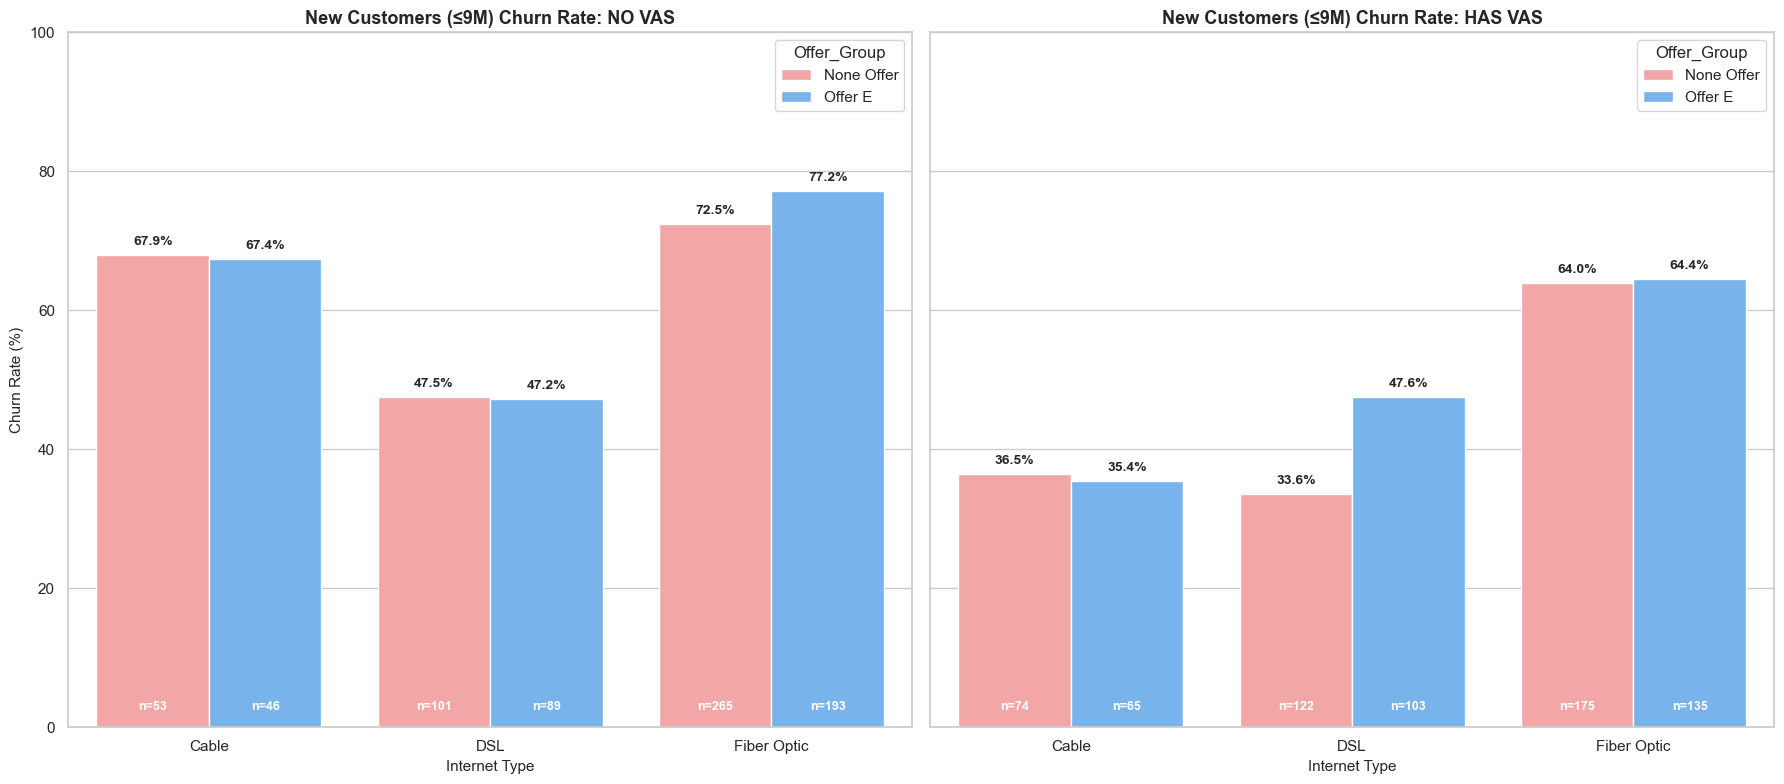

In [213]:
# =========================================================================
# 1. 數據準備與交叉聚合 (衍生 VAS 標籤並計算流失率)
# =========================================================================
df_vas_churn = df.copy()
df_vas_churn['Offer_Group'] = df_vas_churn['Offer'].fillna('None Offer')

# 鎖定 ≤ 9 個月、Offer E / None Offer 且有網絡服務的新用戶
df_new_vas = df_vas_churn[
    (df_vas_churn['Tenure in Months'] <= 9) & 
    (df_vas_churn['Offer_Group'].isin(['Offer E', 'None Offer'])) & 
    (df_vas_churn['Internet Service'] == 'Yes')
].copy()

# 定義 4 大增值服務列并計算開通數量
vas_cols = ['Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support']
df_new_vas['VAS_Count'] = (df_new_vas[vas_cols] == 'Yes').sum(axis=1)
df_new_vas['Has_VAS'] = np.where(df_new_vas['VAS_Count'] > 0, 'Has VAS (1-4)', 'No VAS (0)')

# 按 有無VAS、網絡類型、套餐分組 聚合計算流失率與樣本量
vas_churn_summary = df_new_vas.groupby(['Has_VAS', 'Internet Type', 'Offer_Group']).agg(
    總人數=('Churn Label', 'count'),
    流失人數=('Churn Label', lambda x: (x == 'Yes').sum()),
    流失率=('Churn Label', lambda x: (x == 'Yes').mean() * 100)
).reset_index()

#print("=== 新用戶 (≤9M) 在不同網絡與增值服務下的流失率統計 ===")
#print(vas_churn_summary.round(2).to_string(index=False))


# =========================================================================
# 2. 開始畫圖：創建 1行 2列 的畫布 (共享 Y 軸以便對比)
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
sns.set_style("whitegrid")

# 粉色代表 None Offer，藍色代表 Offer E (保持您一貫的視覺風格)
color_map = {'None Offer': '#ff9999', 'Offer E': '#66b3ff'}
net_order = ['Cable', 'DSL', 'Fiber Optic']

# -------------------------------------------------------------------------
# 左圖 (Ax 1)：無任何增值服務 (No VAS) 的流失率對比
# -------------------------------------------------------------------------
df_no_vas_churn = vas_churn_summary[vas_churn_summary['Has_VAS'] == 'No VAS (0)']
ax1 = sns.barplot(
    ax=axes[0], data=df_no_vas_churn, x='Internet Type', y='流失率', 
    hue='Offer_Group', hue_order=['None Offer', 'Offer E'], order=net_order, palette=color_map
)
axes[0].set_title('New Customers (≤9M) Churn Rate: NO VAS', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)', fontsize=11)
axes[0].set_xlabel('Internet Type', fontsize=11)
axes[0].set_ylim(0, 100)

# 為左圖精確貼上 流失率百分比 與 樣本量n
for hue_idx, container in enumerate(ax1.containers):
    offer_grp = 'None Offer' if hue_idx == 0 else 'Offer E'
    for net_idx, bar in enumerate(container):
        net_type = net_order[net_idx]
        row = df_no_vas_churn[(df_no_vas_churn['Offer_Group'] == offer_grp) & (df_no_vas_churn['Internet Type'] == net_type)]
        if not row.empty:
            rate = row['流失率'].values[0]
            n_sub = row['總人數'].values[0]
            x_pos = bar.get_x() + bar.get_width() / 2
            axes[0].text(x_pos, rate + 1, f"{rate:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')
            axes[0].text(x_pos, 2, f"n={n_sub}", ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')

# -------------------------------------------------------------------------
# 右圖 (Ax 2)：有開增值服務 (Has VAS) 的流失率對比
# -------------------------------------------------------------------------
df_has_vas_churn = vas_churn_summary[vas_churn_summary['Has_VAS'] == 'Has VAS (1-4)']
ax2 = sns.barplot(
    ax=axes[1], data=df_has_vas_churn, x='Internet Type', y='流失率', 
    hue='Offer_Group', hue_order=['None Offer', 'Offer E'], order=net_order, palette=color_map
)
axes[1].set_title('New Customers (≤9M) Churn Rate: HAS VAS', fontsize=13, fontweight='bold')
axes[1].set_ylabel('', fontsize=11)
axes[1].set_xlabel('Internet Type', fontsize=11)

# 為右圖精確貼上 流失率百分比 與 樣本量n
for hue_idx, container in enumerate(ax2.containers):
    offer_grp = 'None Offer' if hue_idx == 0 else 'Offer E'
    for net_idx, bar in enumerate(container):
        net_type = net_order[net_idx]
        row = df_has_vas_churn[(df_has_vas_churn['Offer_Group'] == offer_grp) & (df_has_vas_churn['Internet Type'] == net_type)]
        if not row.empty:
            rate = row['流失率'].values[0]
            n_sub = row['總人數'].values[0]
            x_pos = bar.get_x() + bar.get_width() / 2
            axes[1].text(x_pos, rate + 1, f"{rate:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')
            axes[1].text(x_pos, 2, f"n={n_sub}", ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

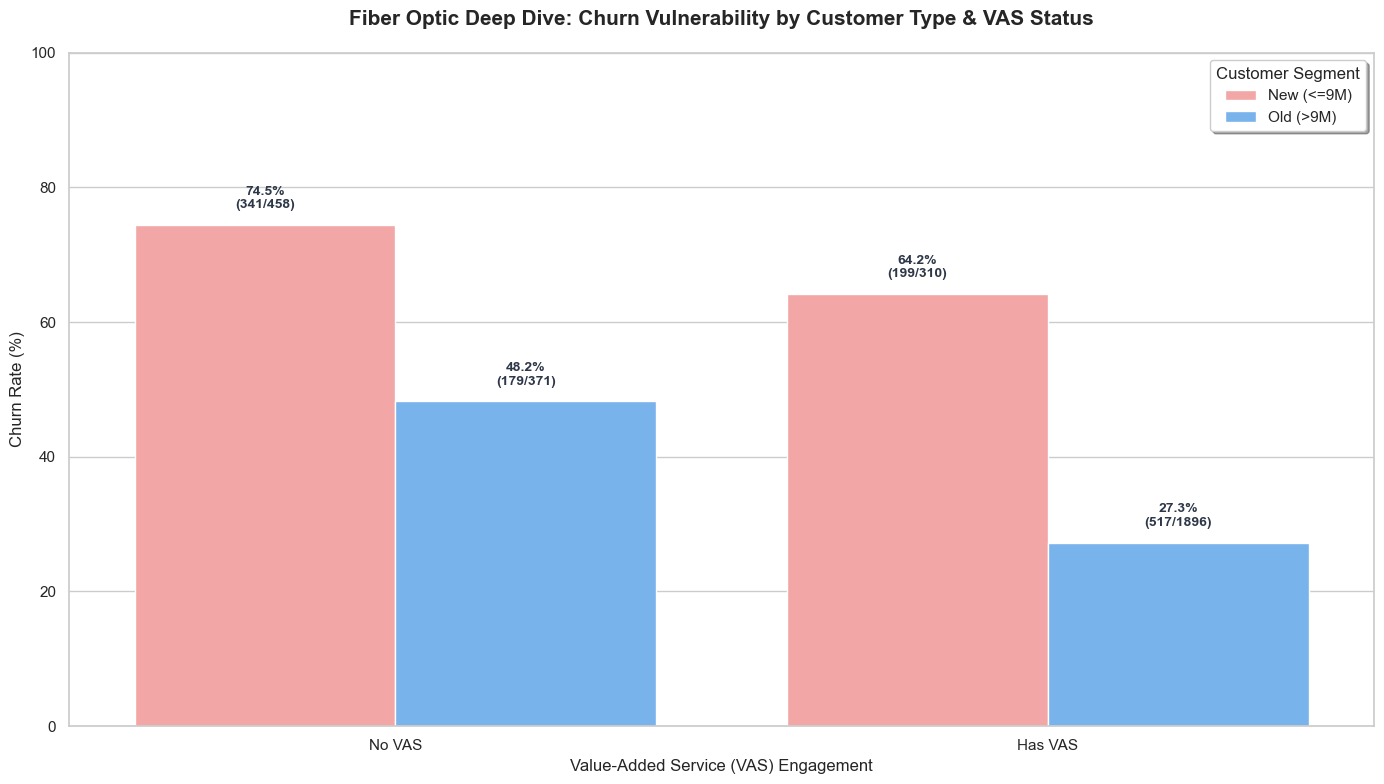

In [297]:
# =========================================================================
# 1. Data Processing: Isolate Fiber Users & Aggregate Churn Metrics
# =========================================================================
# Strictly filter for Fiber Optic users across the database
df_fiber_matrix = df[df['Internet Type'].str.strip() == 'Fiber Optic'].copy()

# Map Customer Segment based on your 9-month threshold milestone
tenure_threshold = 9
df_fiber_matrix['Customer_Type'] = np.where(
    df_fiber_matrix['Tenure in Months'] <= tenure_threshold, 
    'New (<=9M)', 
    'Old (>9M)'
)

# Define the 4 Value-Added Services (VAS) and evaluate status
vas_cols = ['Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support']
valid_vas = [col for col in vas_cols if col in df_fiber_matrix.columns]
df_fiber_matrix['VAS_Count'] = (df_fiber_matrix[valid_vas] == 'Yes').sum(axis=1) if valid_vas else 0
df_fiber_matrix['VAS_Status'] = np.where(df_fiber_matrix['VAS_Count'] > 0, 'Has VAS', 'No VAS')

# Calculate Churn Rates and Sample Sizes
fiber_matrix_summary = df_fiber_matrix.groupby(['Customer_Type', 'VAS_Status']).agg(
    Total_Users=('Churn Label', 'count'),
    Churned_Users=('Churn Label', lambda x: (x == 'Yes').sum()),
    Churn_Rate=('Churn Label', lambda x: (x == 'Yes').mean() * 100)
).reset_index()

# Ensure standard ordering for plotting alignment
segment_order = ['New (<=9M)', 'Old (>9M)']
vas_order = ['No VAS', 'Has VAS']

fiber_matrix_summary['Customer_Type'] = pd.Categorical(fiber_matrix_summary['Customer_Type'], categories=segment_order, ordered=True)
fiber_matrix_summary['VAS_Status'] = pd.Categorical(fiber_matrix_summary['VAS_Status'], categories=vas_order, ordered=True)
fiber_matrix_summary = fiber_matrix_summary.sort_values(['Customer_Type', 'VAS_Status'])


# =========================================================================
# 2. Plotting: Isolated Fiber Matrix Dashboard
# =========================================================================
fig, ax = plt.subplots(figsize=(14, 8))
sns.set_style("whitegrid")

# Palette: Soft Red/Coral for New Users, Soft Corporate Blue for Old Users
matrix_palette = {'New (<=9M)': '#ff9999', 'Old (>9M)': '#66b3ff'}

# Generate Grouped Bar Chart
ax_bar = sns.barplot(
    ax=ax, data=fiber_matrix_summary, x='VAS_Status', y='Churn_Rate',
    hue='Customer_Type', hue_order=segment_order, palette=matrix_palette, order=vas_order
)

# Axis configuration & English labels
ax.set_title('Fiber Optic Deep Dive: Churn Vulnerability by Customer Type & VAS Status', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_xlabel('Value-Added Service (VAS) Engagement', fontsize=12)
ax.set_ylim(0, 100) # Percentage scale limit
ax.legend(title='Customer Segment', loc='upper right', frameon=True, shadow=True)

# Add precise percentage and volume fraction annotations (Churned / Total) over bars
for hue_idx, container in enumerate(ax_bar.containers):
    current_segment = segment_order[hue_idx]
    
    for x_idx, bar in enumerate(container):
        target_vas = vas_order[x_idx]
        
        # Pull accurate historical row slices
        row = fiber_matrix_summary[
            (fiber_matrix_summary['Customer_Type'] == current_segment) & 
            (fiber_matrix_summary['VAS_Status'] == target_vas)
        ]
        
        if not row.empty:
            rate = row['Churn_Rate'].values[0]
            total_n = row['Total_Users'].values[0]
            churn_n = row['Churned_Users'].values[0]
            
            # Construct the executive dual-metric string label
            annotation_text = f"{rate:.1f}%\n({churn_n}/{total_n})"
            
            ax.text(
                bar.get_x() + bar.get_width() / 2, 
                rate + 2, 
                annotation_text, 
                ha='center', va='bottom', fontsize=10, fontweight='bold',
                color='#2d3748'
            )

plt.tight_layout()
plt.show()

In [301]:
# =========================================================================
# 1. Data Preprocessing: Filter Fiber Users & Define Cohort Labels
# =========================================================================
# Isolate Fiber Optic users
df_test = df[df['Internet Type'].str.strip() == 'Fiber Optic'].copy()

# Segment New vs. Old customers based on your 9-month threshold
tenure_threshold = 9
df_test['Customer_Type'] = np.where(
    df_test['Tenure in Months'] <= tenure_threshold, 
    'New (<=9M)', 
    'Old (>9M)'
)

# Evaluate Value-Added Services (VAS) status
vas_cols = ['Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support']
valid_vas = [col for col in vas_cols if col in df_test.columns]
df_test['VAS_Count'] = (df_test[valid_vas] == 'Yes').sum(axis=1) if valid_vas else 0
df_test['VAS_Status'] = np.where(df_test['VAS_Count'] > 0, 'Has VAS', 'No VAS')


# =========================================================================
# 2. Automation: Run Chi-Square Tests & Print Executive Report
# =========================================================================
customer_types = ['New (<=9M)', 'Old (>9M)']

print("=========================================================================")
print("         HYPOTHESIS TESTING REPORT: VAS CHURN SIGNIFICANCE               ")
print("=========================================================================")

for c_type in customer_types:
    print(f"\n▶ ANALYZING COHORT: {c_type}")
    
    # Filter subgroup data
    df_sub = df_test[df_test['Customer_Type'] == c_type]
    
    # Create a 2x2 Contingency Table (Observed Frequencies)
    contingency_table = pd.crosstab(df_sub['VAS_Status'], df_sub['Churn Label'])
    
    print("【1. Observed Contingency Table】")
    print(contingency_table)
    
    # Calculate baseline churn rates for intuitive comparison
    no_vas_churn_rate = (df_sub[df_sub['VAS_Status']=='No VAS']['Churn Label'] == 'Yes').mean() * 100
    has_vas_churn_rate = (df_sub[df_sub['VAS_Status']=='Has VAS']['Churn Label'] == 'Yes').mean() * 100
    print(f"   - Churn Rate WITHOUT VAS : {no_vas_churn_rate:.1f}%")
    print(f"   - Churn Rate WITH VAS    : {has_vas_churn_rate:.1f}%")
    print(f"   - Absolute Gap           : {abs(has_vas_churn_rate - no_vas_churn_rate):.1f}%")
    
    # Execute the Chi-Square Independence Test
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
    
    print("\n【2. Test Metrics】")
    print(f"   - Chi-Square Statistic : {chi2:.4f}")
    print(f"   - P-value              : {p_val:.4e}")
    
    # Render Causal / Decision Conclusions
    print("\n【3. Executive Conclusion】")
    if p_val < 0.05:
        print(f"   🔴 Statistical Status: 【 HIGHLY SIGNIFICANT 】 (P < 0.05)")
        print(f"   ⇒ Reject the Null Hypothesis ($H_0$). There is a statistically verified dependency between VAS status and Churn within the {c_type} cohort.")
        print("   ⇒ Business Interpretation: The cost markups or experience changes introduced by VAS are structurally driving customer decisions. This is NOT random fluctuation.")
    else:
        print(f"   🟢 Statistical Status: 【 NOT SIGNIFICANT 】 (P >= 0.05)")
        print(f"   ⇒ Fail to Reject the Null Hypothesis ($H_0$). The gap in churn rates between users with/without VAS is trivial in this group.")
        print("   ⇒ Business Interpretation: The observed percentage difference is likely due to random sampling error; it cannot be used as a structural justification for modifying VAS strategy for this segment.")
    print("-" * 70)

         HYPOTHESIS TESTING REPORT: VAS CHURN SIGNIFICANCE               

▶ ANALYZING COHORT: New (<=9M)
【1. Observed Contingency Table】
Churn Label   No  Yes
VAS_Status           
Has VAS      111  199
No VAS       117  341
   - Churn Rate WITHOUT VAS : 74.5%
   - Churn Rate WITH VAS    : 64.2%
   - Absolute Gap           : 10.3%

【2. Test Metrics】
   - Chi-Square Statistic : 8.8390
   - P-value              : 2.9486e-03

【3. Executive Conclusion】
   🔴 Statistical Status: 【 HIGHLY SIGNIFICANT 】 (P < 0.05)
   ⇒ Reject the Null Hypothesis ($H_0$). There is a statistically verified dependency between VAS status and Churn within the New (<=9M) cohort.
   ⇒ Business Interpretation: The cost markups or experience changes introduced by VAS are structurally driving customer decisions. This is NOT random fluctuation.
----------------------------------------------------------------------

▶ ANALYZING COHORT: Old (>9M)
【1. Observed Contingency Table】
Churn Label    No  Yes
VAS_Status           

#### 5. The churn rate for existing customers is roughly the same as that for new customers; in fact, the MRR  shows a higher churn rate for existing customers. Is this a service issue?

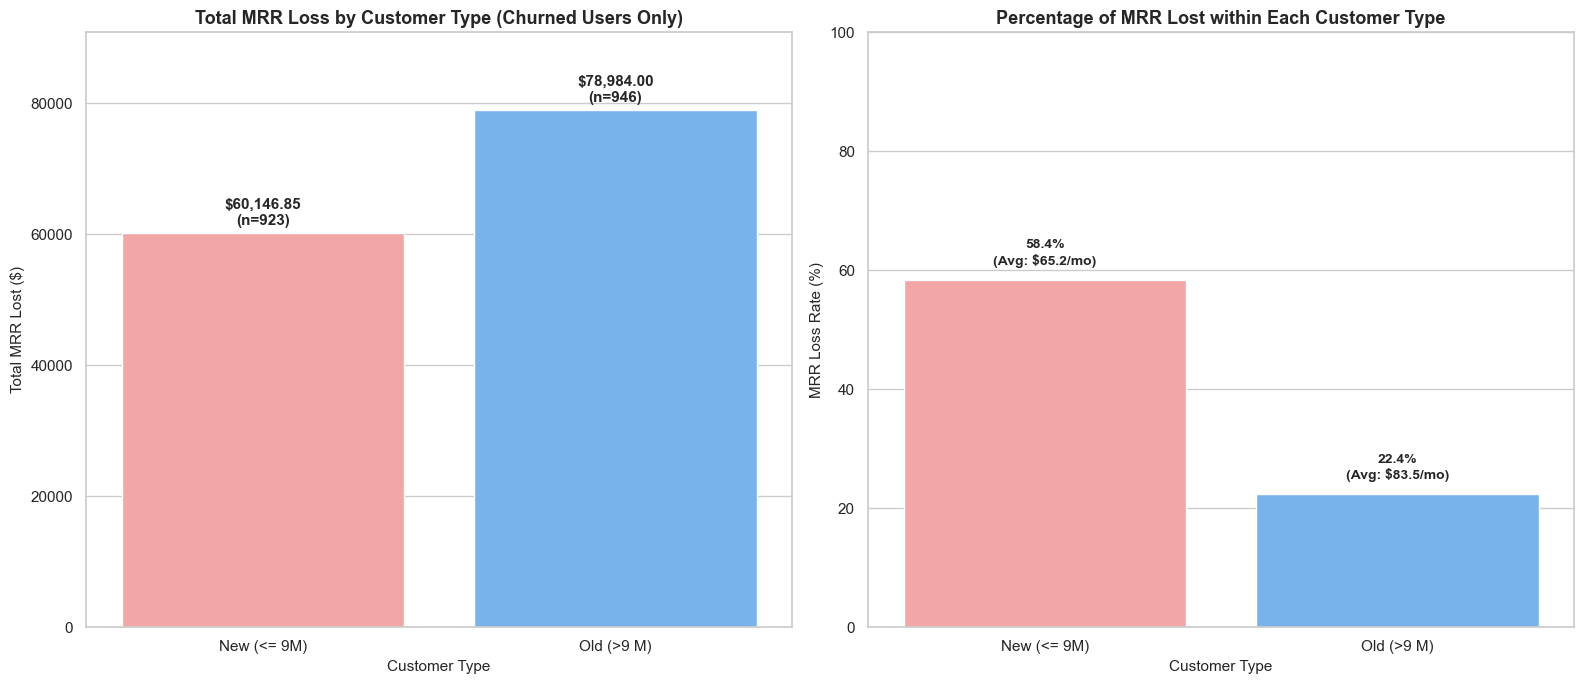

In [215]:
df_mrr = df.copy()
tenure_threshold = 9 

df_mrr['Customer_Type'] = np.where(df_mrr['Tenure in Months'] <= tenure_threshold, 'New (<= 9M)', 'Old (>9 M)')

# 2. 按 客户类型 和 流失状态 聚合计算 MRR (Monthly Charges)
# 统计总额、平均月费、以及用户数
mrr_summary = df_mrr.groupby(['Customer_Type', 'Churn Label']).agg(
    用户数=('Churn Label', 'count'),
    MRR总额=('Monthly Charge', 'sum'),
    平均月费=('Monthly Charge', 'mean')
).reset_index()

# 3. 计算流失 MRR 在各自群体中的占比
total_mrr_by_type = df_mrr.groupby('Customer_Type')['Monthly Charge'].sum().to_dict()
mrr_summary['MRR群体占比(%)'] = mrr_summary.apply(
    lambda row: (row['MRR总额'] / total_mrr_by_type[row['Customer_Type']]) * 100, axis=1
)

#print(f"=== 基于 {tenure_threshold} 個月劃分的新老用戶 MRR 流失分析 ===")
#print(mrr_summary.round(2).to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.set_style("whitegrid")

# 过滤出流失用户 (Churn Label == 'Yes') 看流失的收入结构
df_churned_mrr = mrr_summary[mrr_summary['Churn Label'] == 'Yes'].reset_index(drop=True)

# -------------------------------------------------------------------------
# 左图：新老流失用户的 MRR 总额损失 (绝对值对比)
# -------------------------------------------------------------------------
ax1 = sns.barplot(ax=axes[0], data=df_churned_mrr, x='Customer_Type', y='MRR总额', palette=['#ff9999', '#66b3ff'])
axes[0].set_title('Total MRR Loss by Customer Type (Churned Users Only)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total MRR Lost ($)', fontsize=11)
axes[0].set_xlabel('Customer Type', fontsize=11)
axes[0].set_ylim(0, df_churned_mrr['MRR总额'].max() * 1.15)

for i, bar in enumerate(ax1.patches):
    val = df_churned_mrr.loc[i, 'MRR总额']
    n_user = df_churned_mrr.loc[i, '用户数']
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (df_churned_mrr['MRR总额'].max() * 0.01),
        f"${val:,.2f}\n(n={n_user})",
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

# -------------------------------------------------------------------------
# 右图：新老客户各自的 MRR 流失率 (相对比例对比)
# -------------------------------------------------------------------------
ax2 = sns.barplot(ax=axes[1], data=df_churned_mrr, x='Customer_Type', y='MRR群体占比(%)', palette=['#ff9999', '#66b3ff'])
axes[1].set_title('Percentage of MRR Lost within Each Customer Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('MRR Loss Rate (%)', fontsize=11)
axes[1].set_xlabel('Customer Type', fontsize=11)
axes[1].set_ylim(0, 100)

for i, bar in enumerate(ax2.patches):
    rate = df_churned_mrr.loc[i, 'MRR群体占比(%)']
    avg_charge = df_churned_mrr.loc[i, '平均月费']
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{rate:.1f}%\n(Avg: ${avg_charge:.1f}/mo)",
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

#### 6. Approximately 45%+ of user churn is attributed to pressure from competitors. However, since the reasons given after churn are given, they don't necessarily reflect the true situation of the customers. It's necessary to analyze this in conjunction with whether service issues have arisen.

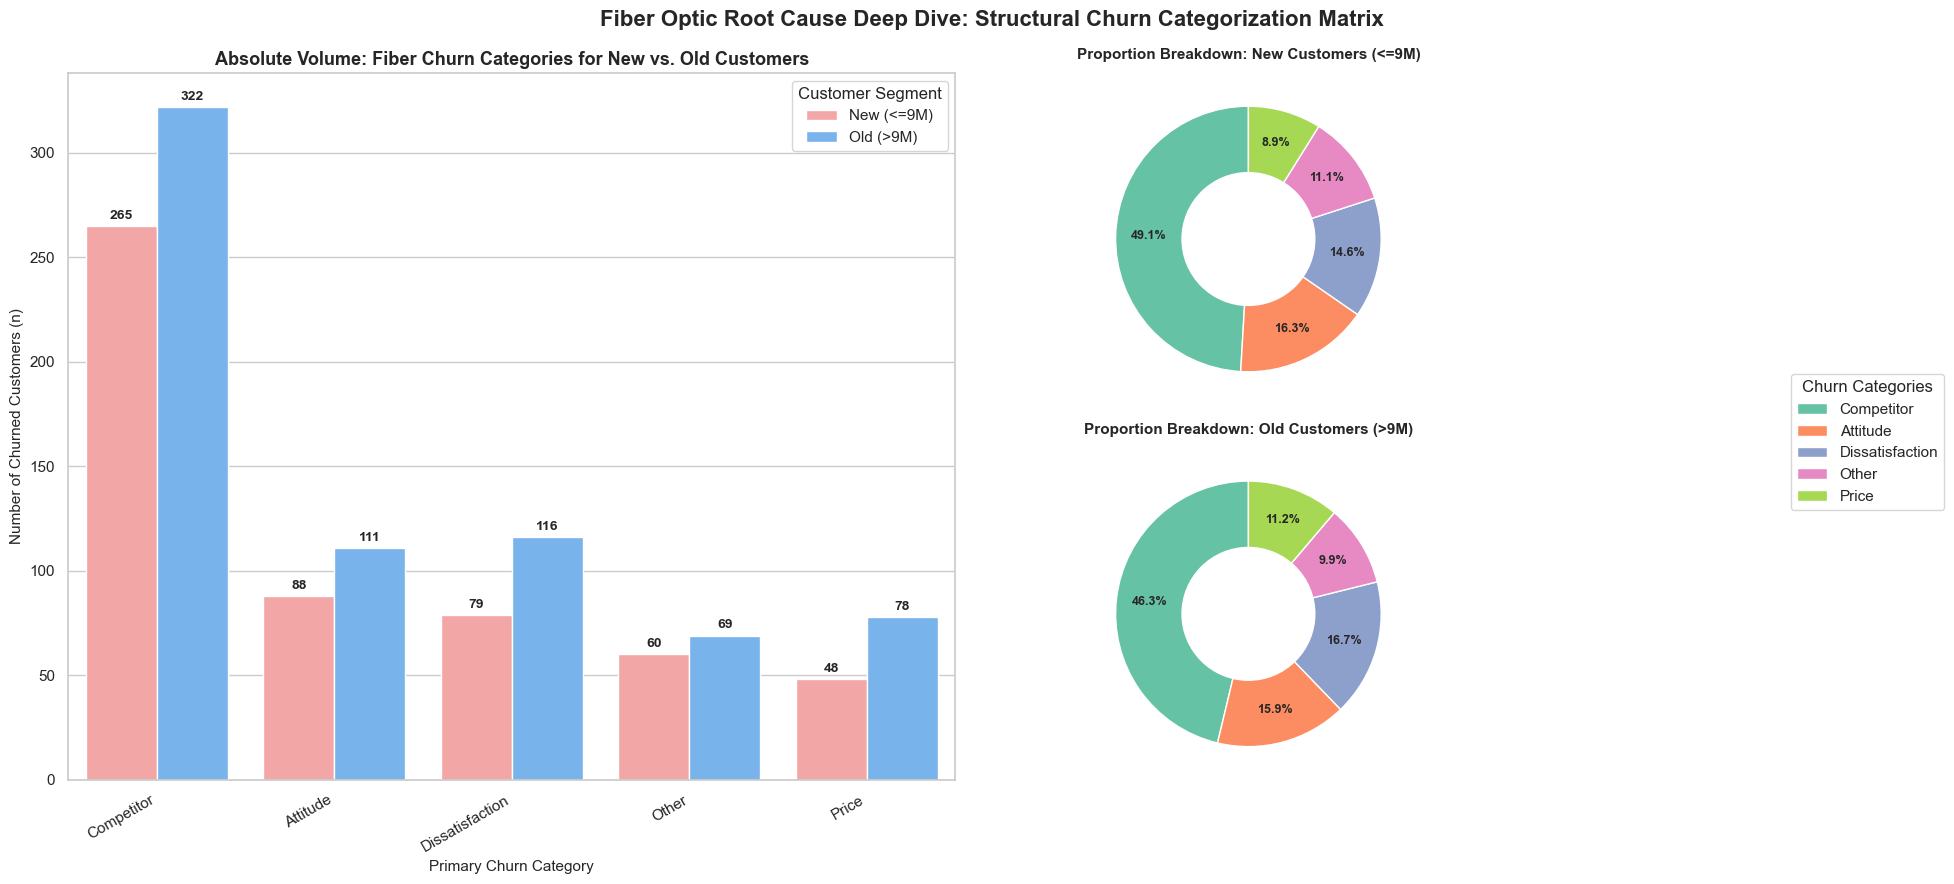

In [234]:
# =========================================================================
# 1. Data Prep: Filter Fiber Optic Churned Users & Define New/Old Segments
# =========================================================================
df_fiber_churn = df[
    (df['Internet Type'] == 'Fiber Optic') & 
    (df['Churn Label'] == 'Yes')
].copy()

# Ensure Churn Category treats missing values uniformly
df_fiber_churn['Churn Category'] = df_fiber_churn['Churn Category'].fillna('Unknown')

# Define Customer Segments based on your 9-month threshold
tenure_threshold = 9
df_fiber_churn['Customer_Type'] = np.where(
    df_fiber_churn['Tenure in Months'] <= tenure_threshold, 
    'New (<=9M)', 
    'Old (>9M)'
)

# Aggregate data by Customer Type and Churn Category
category_summary = df_fiber_churn.groupby(['Customer_Type', 'Churn Category']).size().reset_index(name='Churned_Count')

# Calculate relative percentages within each customer type for the donut charts
category_summary['Percentage'] = category_summary.groupby('Customer_Type')['Churned_Count'].transform(lambda x: (x / x.sum()) * 100)

# Sort categories by total churn volume for consistent plotting order
category_order = category_summary.groupby('Churn Category')['Churned_Count'].sum().sort_values(ascending=False).index.tolist()
category_summary['Churn Category'] = pd.Categorical(category_summary['Churn Category'], categories=category_order, ordered=True)
category_summary = category_summary.sort_values(['Customer_Type', 'Churn Category'])


# =========================================================================
# 2. Plotting: Dual Aspect Dashboard (Volume vs. Proportion Breakdown)
# =========================================================================
fig = plt.figure(figsize=(20, 9))
sns.set_style("whitegrid")

# Define crisp, professional color schemes
palette_colors = sns.color_palette("Set2", len(category_order))
color_map = dict(zip(category_order, palette_colors))

# -------------------------------------------------------------------------
# Left Subplot: Clustered Bar Chart (Absolute Churn Volume)
# -------------------------------------------------------------------------
ax1 = fig.add_subplot(1, 2, 1)
sns.barplot(
    ax=ax1, data=category_summary, x='Churn Category', y='Churned_Count',
    hue='Customer_Type', palette=['#ff9999', '#66b3ff'], order=category_order
)
ax1.set_title('Absolute Volume: Fiber Churn Categories for New vs. Old Customers', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Churned Customers (n)', fontsize=11)
ax1.set_xlabel('Primary Churn Category', fontsize=11)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right')
ax1.legend(title='Customer Segment')

# Add counts directly above the bars
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')


# -------------------------------------------------------------------------
# Right Subplot: Nested Donut Charts (Proportional Proportions)
# -------------------------------------------------------------------------
# We dynamically split the right area into two smaller pie spaces
ax2_new = fig.add_subplot(2, 2, 2)
ax2_old = fig.add_subplot(2, 2, 4)

# Data breakdown for New Customers donut
df_new_pie = category_summary[category_summary['Customer_Type'] == 'New (<=9M)'].set_index('Churn Category').reindex(category_order).fillna(0)
wedges1, texts1, autotexts1 = ax2_new.pie(
    df_new_pie['Churned_Count'], labels=None, autopct='%1.1f%%', startangle=90, 
    colors=[color_map[cat] for cat in category_order], pctdistance=0.75,
    textprops=dict(fontweight='bold', fontsize=9)
)
# Add center circle to turn it into a Donut Chart
centre_circle1 = plt.Circle((0,0), 0.50, fc='white')
ax2_new.add_artist(centre_circle1)
ax2_new.set_title('Proportion Breakdown: New Customers (<=9M)', fontsize=11, fontweight='bold', pad=10)

# Data breakdown for Old Customers donut
df_old_pie = category_summary[category_summary['Customer_Type'] == 'Old (>9M)'].set_index('Churn Category').reindex(category_order).fillna(0)
wedges2, texts2, autotexts2 = ax2_old.pie(
    df_old_pie['Churned_Count'], labels=None, autopct='%1.1f%%', startangle=90, 
    colors=[color_map[cat] for cat in category_order], pctdistance=0.75,
    textprops=dict(fontweight='bold', fontsize=9)
)
centre_circle2 = plt.Circle((0,0), 0.50, fc='white')
ax2_old.add_artist(centre_circle2)
ax2_old.set_title('Proportion Breakdown: Old Customers (>9M)', fontsize=11, fontweight='bold', pad=10)

# Add a unified legend for the categories on the far right side
fig.legend(wedges1, category_order, title="Churn Categories", loc="center right", bbox_to_anchor=(0.98, 0.5))

plt.suptitle('Fiber Optic Root Cause Deep Dive: Structural Churn Categorization Matrix', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
# Adjust layout slightly to prevent legend clipping
plt.subplots_adjust(right=0.85)
plt.show()

#### 7. A large proportion of both new and existing fiber optic customers use M2M contracts, and further attribution analysis is needed to determine whether an M2M contract or fiber optic service is used.

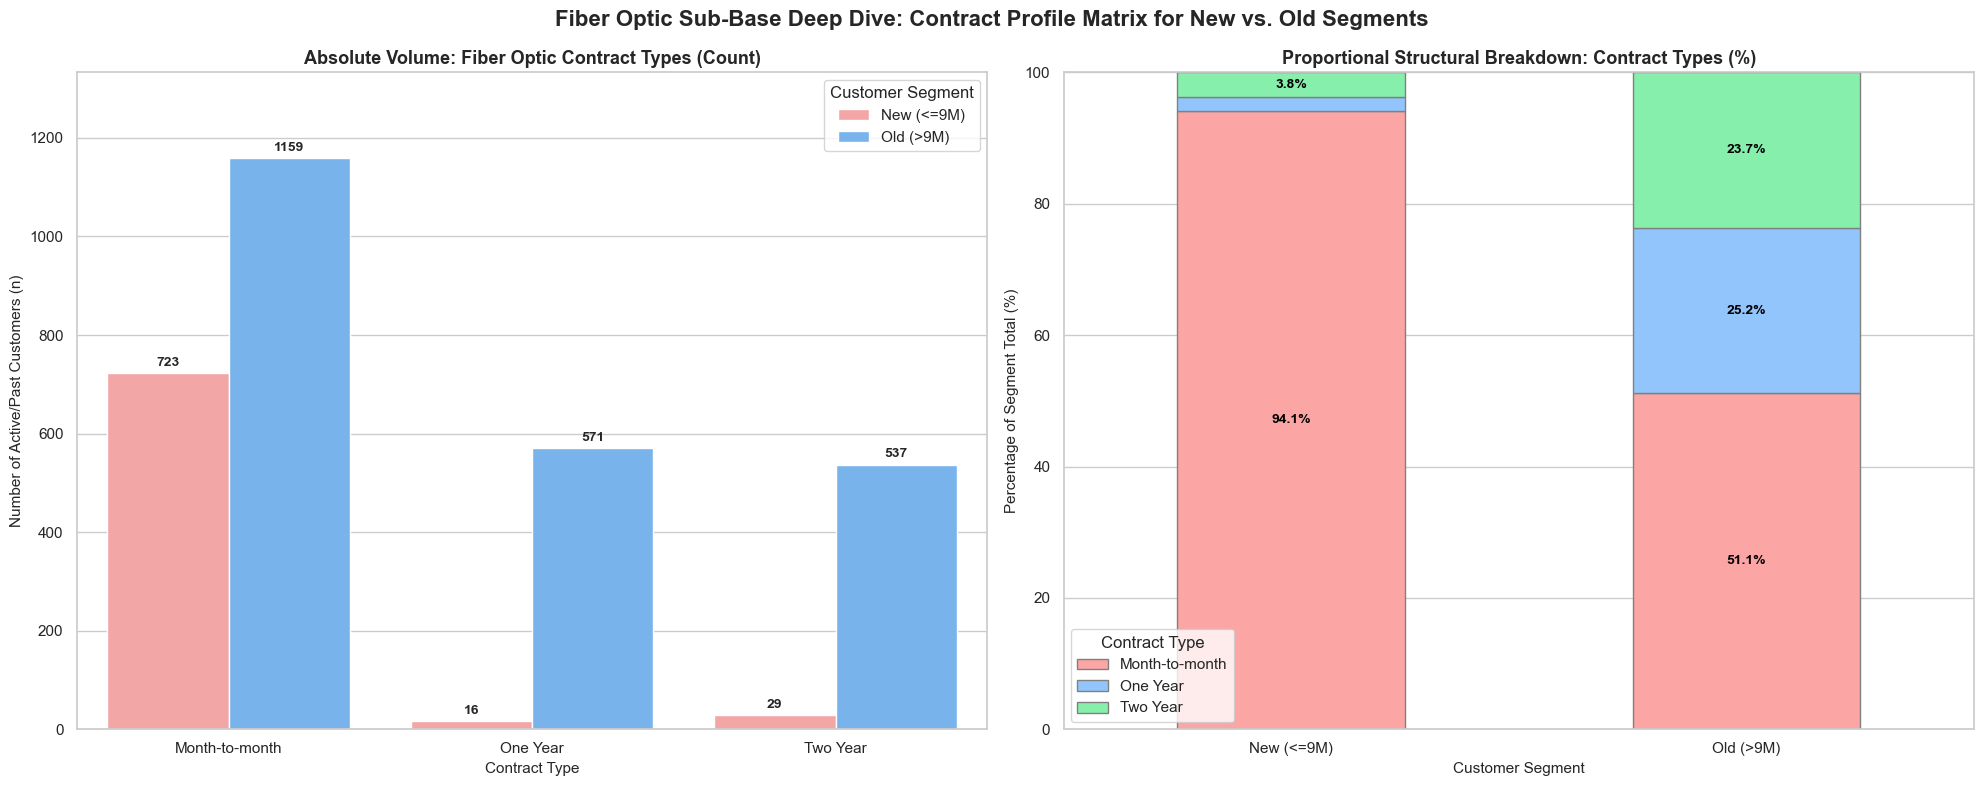

In [308]:
# =========================================================================
# 1. Data Preparation: Filter Fiber Users & Segment by Tenure (<=9M vs >9M)
# =========================================================================
# Filter for Fiber Optic users across the entire base (both churned and retained)
df_fiber_contract = df[df['Internet Type'] == 'Fiber Optic'].copy()

# Treat missing values in Contract uniformly if any exist
df_fiber_contract['Contract'] = df_fiber_contract['Contract'].fillna('Unknown')

# Define Customer Segments based on your 9-month milestone threshold
tenure_threshold = 9
df_fiber_contract['Customer_Type'] = np.where(
    df_fiber_contract['Tenure in Months'] <= tenure_threshold, 
    'New (<=9M)', 
    'Old (>9M)'
)

# Aggregate absolute counts
contract_summary = df_fiber_contract.groupby(['Customer_Type', 'Contract']).size().reset_index(name='Customer_Count')

# Define a clean, logical contract order for plotting
contract_order = ['Month-to-month', 'One Year', 'Two Year']
# Soft-handle potential lowercase variances in your underlying dataset
contract_mapping = {c.lower(): c for c in contract_order}
contract_summary['Contract_Clean'] = contract_summary['Contract'].str.lower().map(contract_mapping).fillna(contract_summary['Contract'])

# Calculate percentages within each customer type segment
contract_summary['Percentage'] = contract_summary.groupby('Customer_Type')['Customer_Count'].transform(lambda x: (x / x.sum()) * 100)


# =========================================================================
# 2. Plotting: Contract Structural Matrix Dashboard
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.set_style("whitegrid")

# Visual Palette: Light Pink for New Customers, Light Blue for Old Customers
segment_palette = {'New (<=9M)': '#ff9999', 'Old (>9M)': '#66b3ff'}
segment_order = ['New (<=9M)', 'Old (>9M)']

# -------------------------------------------------------------------------
# Left Chart (Axes[0]): Absolute Volume Count Breakdown
# -------------------------------------------------------------------------
ax1 = sns.barplot(
    ax=axes[0], data=contract_summary, x='Contract_Clean', y='Customer_Count',
    hue='Customer_Type', hue_order=segment_order, palette=segment_palette, order=contract_order
)
axes[0].set_title('Absolute Volume: Fiber Optic Contract Types (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Active/Past Customers (n)', fontsize=11)
axes[0].set_xlabel('Contract Type', fontsize=11)
axes[0].set_ylim(0, contract_summary['Customer_Count'].max() * 1.15)
axes[0].legend(title='Customer Segment')

# Add explicit count overlays on top of the bars
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')


# -------------------------------------------------------------------------
# Right Chart (Axes[1]): 100% Stacked Bar Chart (Proportion Breakdown)
# -------------------------------------------------------------------------
# Pivot data into a wide-format structure optimized for stacked plotting
pivot_df = contract_summary.pivot(index='Customer_Type', columns='Contract_Clean', values='Percentage').reindex(segment_order)
# Fill missing contract categories with 0% to prevent alignment drops
pivot_df = pivot_df.reindex(columns=contract_order).fillna(0)

# Generate custom professional color scales for the contract types
contract_colors = ['#fca5a5', '#93c5fd', '#86efac'] # Soft Red, Soft Blue, Soft Green

pivot_df.plot(
    kind='bar', stacked=True, ax=axes[1], color=contract_colors, width=0.5, edgecolor='grey'
)
axes[1].set_title('Proportional Structural Breakdown: Contract Types (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage of Segment Total (%)', fontsize=11)
axes[1].set_xlabel('Customer Segment', fontsize=11)
axes[1].set_ylim(0, 100)
axes[1].set_xticklabels(segment_order, rotation=0)
axes[1].legend(title='Contract Type', loc='lower left')

# Add percentage text labels inside the stacked segments
for p in axes[1].patches:
    width, height = p.get_width(), p.get_height()
    if height > 3: # Only display the label if the segment area is large enough to read
        x, y = p.get_xy() 
        axes[1].text(
            x + width/2, y + height/2, f'{height:.1f}%', 
            ha='center', va='center', fontsize=10, fontweight='bold', color='black'
        )

plt.suptitle('Fiber Optic Sub-Base Deep Dive: Contract Profile Matrix for New vs. Old Segments', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

#### 8. Logistic regression and attribution analysis proved that Fiber's service did not have quality issues; rather, the large number of new customers churned was due to the incorrect target audience's design of the service packages. 

In [261]:
df_model = df.copy()

# 核心自变量：创建“是否使用 Fiber”的 0/1 哑变量 (Target Tag)
df_model['Is_Fiber'] = np.where(df_model['Internet Type'].str.strip() == 'Fiber Optic', 1, 0)

# 因变量：将 Churn Label 转换为 0/1 计量单位
df_model['Is_Churned'] = np.where(df_model['Churn Label'].str.strip() == 'Yes', 1, 0)

# 核心混淆变量清洗：新老用户标签 (<=9M 为新用户)
df_model['Is_New_Customer'] = np.where(df_model['Tenure in Months'] <= 9, 1, 0)

# 其他重要的控制变量（如果不控制这些，Fiber的效应会被高月费或短期合同污染）
# A. 合同类型转换为哑变量（以最具波动性的 Month-to-month 作为基准，或直接放入分类变量）
df_model['Contract_Group'] = df_model['Contract'].fillna('Month-to-month').str.strip()

# B. 是否有 Offer
df_model['Has_Offer'] = np.where(df_model['Offer'].isna() | (df_model['Offer'] == 'None'), 0, 1)

# C. 增值服务数量 (VAS)
vas_cols = ['Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support']
valid_cols = [c for c in vas_cols if c in df_model.columns]
df_model['VAS_Count'] = (df_model[valid_cols] == 'Yes').sum(axis=1) if valid_cols else 0

# D. 基础财务指标：月费
df_model['Monthly_Charge'] = df_model['Monthly Charge']


# =========================================================================
# 2. 计量经济学建模：构建 Logit 回归模型 (控制全面变量)
# =========================================================================
# 公式：流失 ~ 是否使用Fiber + 是否新用户 + 是否有Offer + 月费 + 增值服务数 + 合同类型
formula = "Is_Churned ~ Is_Fiber + Is_New_Customer + Has_Offer + Monthly_Charge + VAS_Count + C(Contract_Group)"

model = smf.logit(formula, data=df_model).fit()

print("=========================================================================")
print("                   1. LOGIT REGRESSION STANDARD OUTPUT                   ")
print("=========================================================================")
print(model.summary())


# =========================================================================
# 3. 指标转化：计算边际效应 (Marginal Effects) —— 管理层最容易看懂的指标
# =========================================================================
# Logit的原始系数(Coef)是Log-Odds，不直观。边际效应代表：变量每变动1个单位，流失率绝对值变动多少。
marginal_effects = model.get_margeff(at='overall', method='dydx')

print("\n=========================================================================")
print("             2. MARGINAL EFFECTS (THE REAL VALUE OF FIBER EFFECT)        ")
print("=========================================================================")
print(marginal_effects.summary())


# =========================================================================
# 4. 交叉效应探索：Fiber 对 新用户 vs 老用户 的流失效应是否有显著不同？
# =========================================================================
# 引入交互项 (Is_Fiber * Is_New_Customer) 来看两者的剥离效应
formula_interaction = "Is_Churned ~ Is_Fiber * Is_New_Customer + Has_Offer + Monthly_Charge + VAS_Count + C(Contract_Group)"
model_interaction = smf.logit(formula_interaction, data=df_model).fit()

print("\n=========================================================================")
print("          3. INTERACTION MODEL (FIBER EFFECT ON NEW VS. OLD USERS)       ")
print("=========================================================================")
print(model_interaction.summary())

Optimization terminated successfully.
         Current function value: 0.409833
         Iterations 8
                   1. LOGIT REGRESSION STANDARD OUTPUT                   
                           Logit Regression Results                           
Dep. Variable:             Is_Churned   No. Observations:                 7043
Model:                          Logit   Df Residuals:                     7035
Method:                           MLE   Df Model:                            7
Date:                Fri, 29 May 2026   Pseudo R-squ.:                  0.2917
Time:                        11:31:38   Log-Likelihood:                -2886.5
converged:                       True   LL-Null:                       -4075.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------

In [251]:
### causal Effect

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_ind, chi2_contingency
import warnings
status   = pd.read_excel('Telco_customer_churn_status.xlsx')
services = pd.read_excel('Telco_customer_churn_services.xlsx')
demo     = pd.read_excel('Telco_customer_churn_demographics.xlsx')
 
df = services.merge(
    status[['Customer ID', 'Churn Value', 'CLTV',
            'Satisfaction Score', 'Churn Category']],
    on='Customer ID'
)
df = df.merge(demo[['Customer ID', 'Age', 'Married', 'Senior Citizen']], on='Customer ID')
 
# ── Feature engineering ───────────────────────────────────────────────────────
SECURITY = ['Online Security', 'Online Backup',
            'Device Protection Plan', 'Premium Tech Support']
df['protection_count']  = sum([(df[f]=='Yes').astype(int) for f in SECURITY])
df['is_mpm']            = (df['Contract']=='Month-to-Month').astype(int)
df['married_bin']       = (df['Married']=='Yes').astype(int)
df['senior_bin']        = (df['Senior Citizen']=='Yes').astype(int)
df['charge_per_tenure'] = df['Monthly Charge'] / (df['Tenure in Months']+1)
df['Offer']             = df['Offer'].fillna('None')
 
# ── The key label ─────────────────────────────────────────────────────────────
# is_fiber: binary treatment variable
#   1 = customer is on Fiber Optic internet
#   0 = customer is on DSL, Cable, or no internet
# This is the "treatment" we want to evaluate causally.
df['is_fiber'] = (df['Internet Type'] == 'Fiber Optic').astype(int)
 
# ── Stratification label ──────────────────────────────────────────────────────
# Crossing tenure stage with fiber creates four meaningful business states.
# Why not just use churn rate? Because the MECHANISM differs by group:
#   New + Fiber  → expectation gap (paid for premium, got mediocre onboarding)
#   Old + Fiber  → slow erosion (3 years in, satisfaction declining, competitor knocks)
# Treating them as one "fiber customer" masks two different interventions needed.
df['is_new']    = (df['Tenure in Months'] <= 9).astype(int)
df['fiber_new_label'] = (
    df['is_fiber'].map({1:'Fiber', 0:'Non-Fiber'}) + ' × ' +
    df['is_new'].map({1:'New(≤9mo)', 0:'Old(>9mo)'})
)
 
# ── Clean working dataset ─────────────────────────────────────────────────────
COVARIATES = [
    'Tenure in Months', 'Monthly Charge', 'Age',
    'married_bin', 'senior_bin', 'is_mpm',
    'protection_count', 'charge_per_tenure',
    'Number of Referrals'
]
 
ALL_NEEDED = list(set(
    COVARIATES +
    ['is_fiber', 'is_new', 'Churn Value', 'Customer ID',
     'Satisfaction Score', 'Monthly Charge', 'fiber_new_label',
     'Tenure in Months', 'Internet Type', 'CLTV']
))
 
df_m = (df[ALL_NEEDED]
        .dropna()
        .drop_duplicates(subset='Customer ID')
        .reset_index(drop=True))
 
print(f"Working dataset: {len(df_m):,} customers")
print(f"Overall churn  : {df_m['Churn Value'].mean():.1%}")
print(f"Fiber customers: {df_m['is_fiber'].sum():,} ({df_m['is_fiber'].mean():.1%})")
 
 
# =============================================================================
#  STEP 1 — NAIVE COMPARISON (biased baseline)
#
#  Why show this first:
#  The naive comparison is what most dashboards show. We expose it here
#  explicitly so that later, when PSM and regression give a smaller
#  number, the business understands WHY it is smaller — because the
#  naive number was inflated by the fact that fiber attracts riskier
#  customers in the first place.
# =============================================================================
print("\n" + "=" * 65)
print("STEP 1: Naive (biased) comparison")
print("=" * 65)
 
fiber     = df_m[df_m['is_fiber'] == 1]
non_fiber = df_m[df_m['is_fiber'] == 0]
 
naive_gap = fiber['Churn Value'].mean() - non_fiber['Churn Value'].mean()
print(f"Fiber churn rate    : {fiber['Churn Value'].mean():.1%}")
print(f"Non-fiber churn rate: {non_fiber['Churn Value'].mean():.1%}")
print(f"Naive gap           : {naive_gap:+.1%}  ← BIASED (confounders not removed)")
 
# Covariate imbalance — shows WHY naive comparison is wrong
print("\nCovariate imbalance (fiber vs non-fiber) — the confounders:")
print(f"  {'Feature':<28} {'Fiber':>10} {'Non-fiber':>10} {'Diff':>8}")
print("  " + "-" * 60)
for cov in ['Tenure in Months', 'Monthly Charge', 'is_mpm',
            'protection_count', 'senior_bin', 'Age']:
    tf  = float(fiber[cov].mean())
    tnf = float(non_fiber[cov].mean())
    print(f"  {cov:<28} {tf:>10.2f} {tnf:>10.2f} {tf-tnf:>+8.2f}")
 
# Stratified label breakdown
print("\nFiber × Tenure stratification:")
strat = df_m.groupby('fiber_new_label').agg(
    n=('Churn Value', 'count'),
    churn_rate=('Churn Value', 'mean'),
    avg_charge=('Monthly Charge', 'mean'),
    avg_sat=('Satisfaction Score', 'mean'),
    lost_mrr=('Monthly Charge',
              lambda x: x[df_m.loc[x.index, 'Churn Value'] == 1].sum())
).round(3)
print(strat.to_string())
 
 
# =============================================================================
#  STEP 2 — PSM: Propensity Score Matching
#
#  Why PSM for fiber:
#    Treatment = is_fiber (1=fiber, 0=non-fiber)
#    We want: ATT = E[Y(1) - Y(0) | T=1]
#    "Among fiber customers, how much did being on fiber cause churn
#     compared to if those same customers had been on non-fiber?"
#
#  Propensity score = P(is_fiber=1 | X)
#    Logistic regression learns: who tends to choose fiber?
#    (Younger, higher charge, month-to-month, urban implied by charge level)
#    Matching on this score: for each fiber customer, find a non-fiber
#    customer the model believes had an equal probability of choosing fiber.
#    After matching, the two groups are comparable on all observed factors.
#
#  Caliper = 0.2 × std(PS): prevents bad matches.
#    Without caliper, every fiber customer gets a match even if their
#    nearest non-fiber neighbour is very different. Caliper rejects
#    unacceptably distant matches — those fiber customers are excluded
#    from the ATT estimate (honest: we can only estimate where we have
#    a valid comparison group).
#
#  We run PSM TWICE:
#    Full PSM: all customers — gives overall fiber ATT
#    Stratified PSM: new vs old separately — separates the two mechanisms
# =============================================================================
print("\n" + "=" * 65)
print("STEP 2: PSM — Propensity Score Matching")
print("=" * 65)
 
 
def run_psm(df_input, label='All customers'):
    """
    Run 1:1 nearest-neighbour PSM for is_fiber treatment.
    Returns matched dataframes and ATT result.
    """
    df_ps = df_input.copy().reset_index(drop=True)
 
    # Step 2a: Estimate propensity score
    X_cov = df_ps[COVARIATES].fillna(df_ps[COVARIATES].median())
    lr    = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    lr.fit(X_cov, df_ps['is_fiber'])
    df_ps['ps'] = lr.predict_proba(X_cov)[:, 1]
 
    # Overlap check: common support
    ps_treated = df_ps[df_ps['is_fiber'] == 1]['ps']
    ps_control = df_ps[df_ps['is_fiber'] == 0]['ps']
    overlap_min = max(ps_treated.min(), ps_control.min())
    overlap_max = min(ps_treated.max(), ps_control.max())
 
    # Step 2b: 1:1 NN matching with caliper
    caliper  = 0.2 * float(df_ps['ps'].std())
    treat_df = df_ps[df_ps['is_fiber'] == 1].reset_index(drop=True)
    ctrl_df  = df_ps[df_ps['is_fiber'] == 0].reset_index(drop=True)
 
    nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
    nn.fit(ctrl_df[['ps']].values)
    dists, idxs = nn.kneighbors(treat_df[['ps']].values)
 
    mt_rows, mc_rows, used = [], [], set()
    for i in range(len(treat_df)):
        d = float(dists[i, 0])
        j = int(idxs[i, 0])
        if d <= caliper and j not in used:
            mt_rows.append(treat_df.iloc[i].to_dict())
            mc_rows.append(ctrl_df.iloc[j].to_dict())
            used.add(j)
 
    if len(mt_rows) < 10:
        print(f"  {label}: insufficient matches ({len(mt_rows)})")
        return None, None, None
 
    mt = pd.DataFrame(mt_rows)
    mc = pd.DataFrame(mc_rows)
 
    # Step 2c: SMD balance check
    smd_results = {}
    for cov in COVARIATES[:6]:
        def smd(a, b):
            pooled = np.sqrt((float(a.std())**2 + float(b.std())**2) / 2)
            return abs(float(a.mean()) - float(b.mean())) / pooled if pooled > 0 else 0.0
 
        smd_before = smd(treat_df[cov], ctrl_df[cov])
        smd_after  = smd(mt[cov], mc[cov])
        smd_results[cov] = (smd_before, smd_after)
 
    # Step 2d: ATT
    churn_t = float(mt['Churn Value'].mean())
    churn_c = float(mc['Churn Value'].mean())
    att     = churn_t - churn_c
    _, p_val = ttest_ind(mt['Churn Value'].values.astype(float),
                          mc['Churn Value'].values.astype(float))
 
    print(f"\n  [{label}]  matched_pairs={len(mt_rows)}")
    print(f"  PS range: treat=[{float(ps_treated.min()):.3f},{float(ps_treated.max()):.3f}]  "
          f"ctrl=[{float(ps_control.min()):.3f},{float(ps_control.max()):.3f}]")
    print(f"  Caliper : {caliper:.4f}")
    print(f"  Churn   : fiber={churn_t:.1%}  non-fiber={churn_c:.1%}")
    print(f"  ATT     : {att:+.4f} ({att*100:+.1f} pp)")
    print(f"  p-value : {p_val:.4f}  {'✓ significant' if p_val < 0.05 else '✗ not significant'}")
    print(f"  SMD (avg before→after): "
          f"{np.mean([v[0] for v in smd_results.values()]):.3f} → "
          f"{np.mean([v[1] for v in smd_results.values()]):.3f}")
 
    # Business interpretation
    if p_val < 0.05 and att > 0:
        monthly_mrr = float(mt['Monthly Charge'].mean())
        n_matched   = len(mt_rows)
        print(f"  Business: Fiber independently adds {att*100:.1f}pp of churn risk")
        print(f"  Monthly MRR at risk from this fiber effect: "
              f"${monthly_mrr * att * n_matched:,.0f}")
 
    return mt, mc, att
 
 
# Full population PSM
mt_all, mc_all, att_all = run_psm(df_m, 'All customers')
 
# Stratified PSM: new vs old separately
# Why separate: the mechanism differs.
# New + fiber = expectation gap problem → onboarding intervention
# Old + fiber = satisfaction erosion problem → proactive monitoring
for new_flag, label in [(1, 'New customers (≤9mo)'), (0, 'Old customers (>9mo)')]:
    sub = df_m[df_m['is_new'] == new_flag]
    fiber_n     = (sub['is_fiber'] == 1).sum()
    non_fiber_n = (sub['is_fiber'] == 0).sum()
    if fiber_n >= 10 and non_fiber_n >= 10:
        run_psm(sub, label)
 
 
# =============================================================================
#  STEP 3 — Logistic Regression + Average Marginal Effect (AME)
#
#  Why logistic regression on top of PSM:
#    PSM gives you the ATT for a matched subset.
#    Logistic regression gives you the effect across the FULL population
#    while simultaneously controlling all covariates.
#    AME (Average Marginal Effect) converts the log-odds coefficient
#    into percentage points of churn probability — more business-readable.
#
#  AME formula:
#    AME(fiber) = (1/N) Σᵢ [ f(Xᵢβ + β_fiber) - f(Xᵢβ) ]
#    where f(·) = sigmoid function
#    = average predicted churn WITH fiber - average predicted churn WITHOUT
#    = the average increase in churn probability attributable to fiber
#      holding all other covariates at their actual values
#
#  We run three model versions to show how the fiber coefficient changes
#  as we add more controls — this reveals whether fiber's effect is
#  direct or mediated through other variables:
#    Model A: fiber only (crude association)
#    Model B: fiber + structural controls (tenure, contract, demographics)
#    Model C: fiber + all controls including satisfaction
#             (if fiber effect shrinks dramatically → mostly mediated through sat)
# =============================================================================
print("\n" + "=" * 65)
print("STEP 3: Logistic Regression + Average Marginal Effect (AME)")
print("=" * 65)
 
 
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
 
 
def compute_ame(model, scaler, X_df, feature_name, feature_list):
    """
    Compute Average Marginal Effect for a binary feature.
    AME = mean predicted probability WITH feature=1 minus WITH feature=0,
    holding all other features at actual observed values.
    """
    X_arr = X_df[feature_list].fillna(X_df[feature_list].median()).values
 
    X_1 = X_arr.copy()
    idx = feature_list.index(feature_name)
    X_1[:, idx] = 1.0
    X_0 = X_arr.copy()
    X_0[:, idx] = 0.0
 
    X_1_s = scaler.transform(X_1)
    X_0_s = scaler.transform(X_0)
 
    p1 = model.predict_proba(X_1_s)[:, 1]
    p0 = model.predict_proba(X_0_s)[:, 1]
    return float((p1 - p0).mean())
 
 
# Model A: crude — fiber only
feat_A = ['is_fiber']
sc_A   = StandardScaler()
X_A    = sc_A.fit_transform(df_m[feat_A].fillna(0))
lr_A   = LogisticRegression(max_iter=1000, random_state=42)
lr_A.fit(X_A, df_m['Churn Value'])
auc_A  = roc_auc_score(df_m['Churn Value'], lr_A.predict_proba(X_A)[:, 1])
 
# Model B: structural controls (no satisfaction — our production model)
feat_B = ['is_fiber'] + COVARIATES
sc_B   = StandardScaler()
X_B    = sc_B.fit_transform(df_m[feat_B].fillna(df_m[feat_B].median()))
lr_B   = LogisticRegression(max_iter=1000, random_state=42)
lr_B.fit(X_B, df_m['Churn Value'])
auc_B  = roc_auc_score(df_m['Churn Value'], lr_B.predict_proba(X_B)[:, 1])
 
# Model C: full controls including satisfaction
# Satisfaction is a mediator — including it will absorb part of fiber's effect.
# The coefficient change from Model B to Model C reveals how much of
# fiber's effect operates THROUGH satisfaction (the indirect path).
feat_C = feat_B + ['Satisfaction Score']
sc_C   = StandardScaler()
X_C    = sc_C.fit_transform(df_m[feat_C].fillna(df_m[feat_C].median()))
lr_C   = LogisticRegression(max_iter=1000, random_state=42)
lr_C.fit(X_C, df_m['Churn Value'])
auc_C  = roc_auc_score(df_m['Churn Value'], lr_C.predict_proba(X_C)[:, 1])
 
# Coefficients and AME
coef_A = float(lr_A.coef_[0][feat_A.index('is_fiber')])
coef_B = float(lr_B.coef_[0][feat_B.index('is_fiber')])
coef_C = float(lr_C.coef_[0][feat_C.index('is_fiber')])
 
ame_A = compute_ame(lr_A, sc_A, df_m, 'is_fiber', feat_A)
ame_B = compute_ame(lr_B, sc_B, df_m, 'is_fiber', feat_B)
ame_C = compute_ame(lr_C, sc_C, df_m, 'is_fiber', feat_C)
 
print(f"\n  {'Model':<35} {'Log-Odds':>10} {'AME (pp)':>10} {'AUC':>8}")
print("  " + "-" * 65)
print(f"  {'A: Fiber only (crude)': <35} {coef_A:>+10.4f} {ame_A*100:>+9.1f}% {auc_A:>8.4f}")
print(f"  {'B: + Structural controls': <35} {coef_B:>+10.4f} {ame_B*100:>+9.1f}% {auc_B:>8.4f}")
print(f"  {'C: + Satisfaction (mediator)': <35} {coef_C:>+10.4f} {ame_C*100:>+9.1f}% {auc_C:>8.4f}")
 
pct_explained_by_sat = (ame_B - ame_C) / ame_B if ame_B != 0 else 0
print(f"\n  Fiber AME reduction from B→C (portion mediated by satisfaction):")
print(f"  {ame_B*100:.1f}pp → {ame_C*100:.1f}pp  =  {pct_explained_by_sat:.1%} of fiber effect")
print(f"  runs THROUGH satisfaction as mediator")
 
if ame_C > 0.02:
    print(f"\n  ✓ Fiber has a DIRECT effect ({ame_C*100:.1f}pp) beyond satisfaction.")
    print(f"    This is a product/network quality problem, not just a perception problem.")
else:
    print(f"\n  ~ Fiber effect mostly disappears once satisfaction controlled.")
    print(f"    The mechanism is: fiber → poor satisfaction → churn.")
    print(f"    Fix the satisfaction experience, the churn gap closes.")
 
# Stratified AME: new vs old
print(f"\n  Stratified AME by tenure:")
for new_flag, label in [(1, 'New (≤12mo)'), (0, 'Old (>12mo)')]:
    sub = df_m[df_m['is_new'] == new_flag]
    sc_sub = StandardScaler()
    X_sub  = sc_sub.fit_transform(sub[feat_B].fillna(sub[feat_B].median()))
    lr_sub = LogisticRegression(max_iter=1000, random_state=42)
    lr_sub.fit(X_sub, sub['Churn Value'])
    ame_sub = compute_ame(lr_sub, sc_sub, sub, 'is_fiber', feat_B)
    print(f"  {label}: AME = {ame_sub*100:+.1f}pp  "
          f"(fiber adds {abs(ame_sub)*100:.1f}pp of churn risk in this group)")
 
 
# =============================================================================
#  STEP 4 — Mediation Analysis
#
#  Why mediation:
#    We know fiber → churn (from PSM and logistic regression).
#    But the MECHANISM matters for intervention design.
#
#    Possible paths:
#      Path 1 (direct):   Fiber → Churn
#                         (installation failure, speed inconsistency,
#                          hardware issues — independent of how customer feels)
#      Path 2 (indirect): Fiber → Low Satisfaction → Churn
#                         (fiber creates a bad experience, that bad experience
#                          shows up as low satisfaction, which drives churn)
#
#    Total Effect = Direct Effect + Indirect Effect
#    Indirect Effect = Effect of fiber on satisfaction × Effect of satisfaction on churn
#
#  Baron-Kenny approach (three regression steps):
#    Step 1: Y ~ T         → total effect of fiber on churn (c)
#    Step 2: M ~ T         → effect of fiber on mediator satisfaction (a)
#    Step 3: Y ~ T + M     → direct effect of fiber controlling sat (c')
#                          → effect of satisfaction controlling fiber (b)
#
#    Indirect effect = a × b
#    Proportion mediated = (a × b) / c
#
#  Why NOT use statsmodels mediation package:
#    We use manual computation because:
#    1. Binary outcome (churn) requires logistic, not OLS
#    2. We want full control over the feature set for each step
#    3. More transparent for business explanation
# =============================================================================
print("\n" + "=" * 65)
print("STEP 4: Mediation Analysis — Fiber → Satisfaction → Churn")
print("=" * 65)
 
from sklearn.linear_model import LinearRegression
 
# Step 1: Total effect — T (fiber) → Y (churn)
# Use logistic regression, report as AME
# This is ame_B already computed above
total_effect = ame_B
print(f"\n  Step 1 — Total Effect (fiber → churn, AME): {total_effect*100:+.2f}pp")
 
# Step 2: T (fiber) → M (satisfaction)
# OLS is appropriate for continuous mediator (satisfaction 1–5)
feat_med = ['is_fiber'] + [c for c in COVARIATES if c != 'Satisfaction Score']
sc_med   = StandardScaler()
X_med    = sc_med.fit_transform(df_m[feat_med].fillna(df_m[feat_med].median()))
 
lr_med = LinearRegression()
lr_med.fit(X_med, df_m['Satisfaction Score'])
 
# Extract coefficient for is_fiber (first feature)
a_coef = float(lr_med.coef_[0])  # effect of fiber on satisfaction (in scaled units)
 
# Unstandardised: fit in original sat scale
from numpy.linalg import lstsq
X_raw = df_m[feat_med].fillna(df_m[feat_med].median()).values
coef_raw, _, _, _ = lstsq(
    np.column_stack([np.ones(len(X_raw)), X_raw]),
    df_m['Satisfaction Score'].values, rcond=None
)
a_unstd = float(coef_raw[1])  # fiber coefficient in satisfaction points
print(f"  Step 2 — Effect of fiber on satisfaction (a): {a_unstd:+.4f} sat points")
print(f"           (fiber customers score {abs(a_unstd):.2f} points {'lower' if a_unstd < 0 else 'higher'} on satisfaction)")
 
# Step 3: Direct effect — T + M → Y
# Already computed as ame_C (Model C includes satisfaction)
direct_effect   = ame_C
indirect_effect = total_effect - direct_effect
 
print(f"  Step 3 — Direct Effect (fiber → churn, controlling sat): {direct_effect*100:+.2f}pp")
print(f"\n  ── Decomposition ──")
print(f"  Total Effect   : {total_effect*100:+.2f}pp")
print(f"  Direct Effect  : {direct_effect*100:+.2f}pp  ({direct_effect/total_effect:.1%} of total)")
print(f"  Indirect Effect: {indirect_effect*100:+.2f}pp  ({indirect_effect/total_effect:.1%} of total)")
print(f"  (via satisfaction as mediator)")
 
print(f"\n  Business interpretation:")
if indirect_effect / total_effect > 0.5:
    print(f"  SATISFACTION IS THE PRIMARY MECHANISM ({indirect_effect/total_effect:.0%} of effect).")
    print(f"  Fiber causes poor satisfaction → that drives churn.")
    print(f"  Fix: improve the fiber experience (installation, support speed,")
    print(f"  reliability) to stop the satisfaction collapse.")
else:
    print(f"  DIRECT EFFECT DOMINATES ({direct_effect/total_effect:.0%} of total effect).")
    print(f"  Fiber has a mechanism that causes churn INDEPENDENT of satisfaction.")
    print(f"  Could be: billing complexity, technical incidents, hardware issues.")
    print(f"  Fix: requires network operations / product investigation,")
    print(f"  not just better customer service.")
 
# Satisfaction distribution for fiber vs non-fiber
print(f"\n  Satisfaction distributions:")
for grp, label in [(1,'Fiber'), (0,'Non-Fiber')]:
    sub = df_m[df_m['is_fiber']==grp]
    for sat in [1,2,3,4,5]:
        sub_s = sub[sub['Satisfaction Score']==sat]
        if len(sub_s) > 0:
            churn = sub_s['Churn Value'].mean()
            print(f"  {label} sat={sat}: n={len(sub_s):>4}  churn={churn:.1%}")
 
 
# =============================================================================
#  STEP 5 — Summary Metrics Table
#
#  Aggregates all three methods into one business-readable table.
#  This is what goes into the CEO briefing / OSM matrix update.
# =============================================================================
print("\n" + "=" * 65)
print("STEP 5: Summary — Fiber Effect Across All Methods")
print("=" * 65)
 
att_str = f"{att_all*100:+.1f}pp" if att_all is not None else "n/a"
print(f"""
  ┌───────────────────────────────────────────────────────────────┐
  │  METHOD              │  FIBER EFFECT ON CHURN  │  VERDICT    │
  ├───────────────────────────────────────────────────────────────┤
  │  Naive comparison    │  {naive_gap*100:+.1f}pp (unadjusted)  │  BIASED     │
  │  PSM (ATT)           │  {att_str:<22}  │  CAUSAL     │
  │  Logistic AME (B)    │  {ame_B*100:+.1f}pp (no sat control) │  CONTROLLED │
  │  Logistic AME (C)    │  {ame_C*100:+.1f}pp (sat controlled)  │  DIRECT     │
  ├───────────────────────────────────────────────────────────────┤
  │  Mediation                                                    │
  │    Total effect      │  {total_effect*100:+.1f}pp                      │             │
  │    Via satisfaction  │  {indirect_effect*100:+.1f}pp ({indirect_effect/total_effect:.0%} of total)       │  INDIRECT   │
  │    Direct (residual) │  {direct_effect*100:+.1f}pp ({direct_effect/total_effect:.0%} of total)       │  DIRECT     │
  └───────────────────────────────────────────────────────────────┘
 
 
""")

Working dataset: 5,517 customers
Overall churn  : 31.8%
Fiber customers: 3,035 (55.0%)

STEP 1: Naive (biased) comparison
Fiber churn rate    : 40.7%
Non-fiber churn rate: 21.0%
Naive gap           : +19.8%  ← BIASED (confounders not removed)

Covariate imbalance (fiber vs non-fiber) — the confounders:
  Feature                           Fiber  Non-fiber     Diff
  ------------------------------------------------------------
  Tenure in Months                  33.14      32.57    +0.57
  Monthly Charge                    91.53      58.88   +32.65
  is_mpm                             0.62       0.49    +0.13
  protection_count                   1.43       1.84    -0.41
  senior_bin                         0.27       0.11    +0.15
  Age                               49.80      44.78    +5.02

Fiber × Tenure stratification:
                          n  churn_rate  avg_charge  avg_sat  lost_mrr
fiber_new_label                                                       
Fiber × New(≤9mo)       7

####  9. The 13-24 month (Mid-Stage Churn) and 25-48 month (Long-Term Decay) periods are the hardest hit, accounting for over 60% of churned users. These periods represent 1- or 2-year contract expiration dates, and it's evident that the proportion of long-term contracts is gradually decreasing. Furthermore, given the increasingly fierce competition, addressing the renewal issues of existing customers is crucial; offering better deals or free VAS usage could be effective.

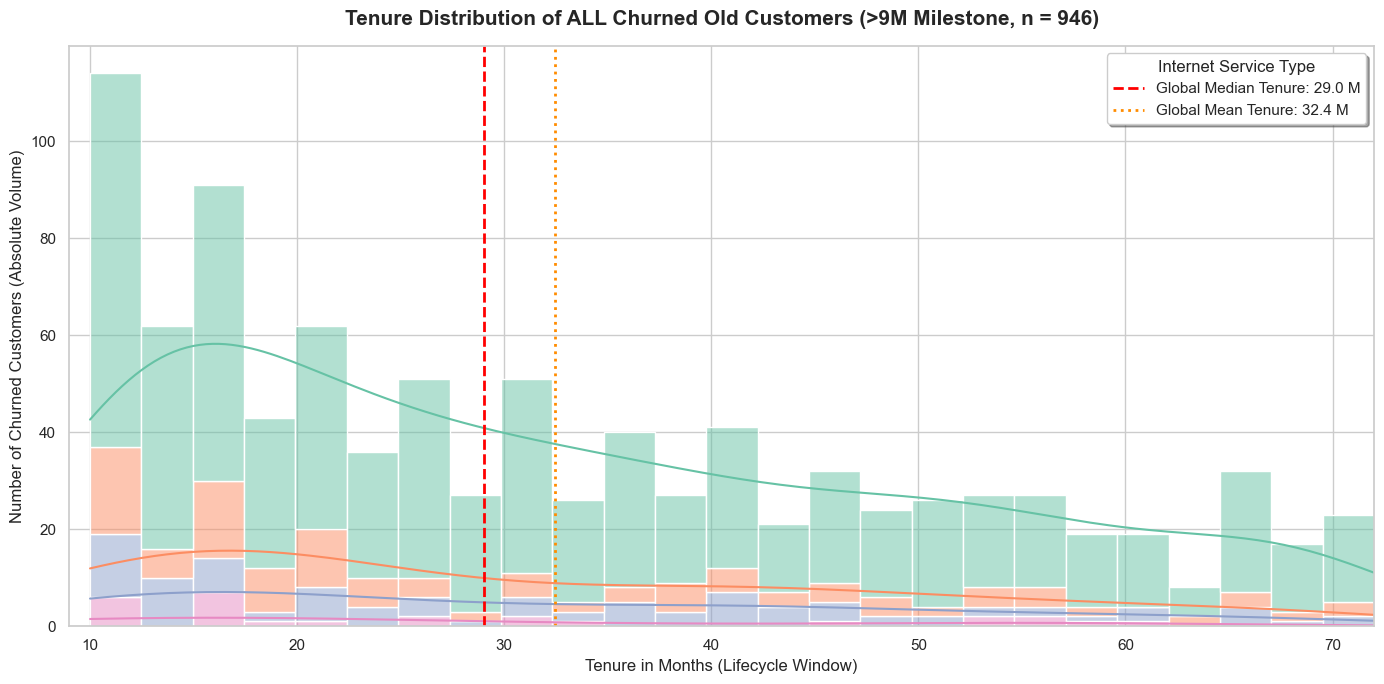

In [323]:
# =========================================================================
# 1. Data Prep: Isolate All Churned Old Customers (>9M)
# =========================================================================
# Filter strictly for Churned + Long-term (>9 Months) across all internet types
df_old_churn_all = df[
    (df['Churn Label'].str.strip() == 'Yes') & 
    (df['Tenure in Months'] > 9)
].copy()

# Standardize column strings to avoid mapping issues
df_old_churn_all['Internet_Type_Clean'] = df_old_churn_all['Internet Type'].fillna('No Internet Service').str.strip()

# =========================================================================
# 2. Plotting: Multi-Layer Tenure Distribution Matrix
# =========================================================================
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Create a stacked histogram with a smooth density curve overlay
sns.histplot(
    data=df_old_churn_all, 
    x='Tenure in Months', 
    hue='Internet_Type_Clean',
    multiple='stack', # Stacks categories to show absolute volume decomposition
    kde=True, 
    bins=25,
    edgecolor='white',
    palette='Set2' # Clean, professional distinct color palette
)

# Calculate global statistics for reference lines
median_all = df_old_churn_all['Tenure in Months'].median()
mean_all = df_old_churn_all['Tenure in Months'].mean()
total_lost_all = len(df_old_churn_all)

# Add statistical milestone reference lines
plt.axvline(median_all, color='red', linestyle='--', linewidth=2, label=f'Global Median Tenure: {median_all:.1f} M')
plt.axvline(mean_all, color='darkorange', linestyle=':', linewidth=2, label=f'Global Mean Tenure: {mean_all:.1f} M')

# Formatting and Labels (All-English)
plt.title(f'Tenure Distribution of ALL Churned Old Customers (>9M Milestone, n = {total_lost_all})', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Tenure in Months (Lifecycle Window)', fontsize=12)
plt.ylabel('Number of Churned Customers (Absolute Volume)', fontsize=12)
plt.xlim(9, df['Tenure in Months'].max()) # Lower bound locked at your 9-month threshold
plt.legend(title='Internet Service Type', loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

 * 10-12 M (1-Yr Critical Window) : 12.1%
 * 13-24 M (Mid-Stage Churn)      : 31.1%
 * 25-48 M (Long-Term Decay)      : 34.4%
 * 49+ M (High-Loyalty Loss)      : 22.5%


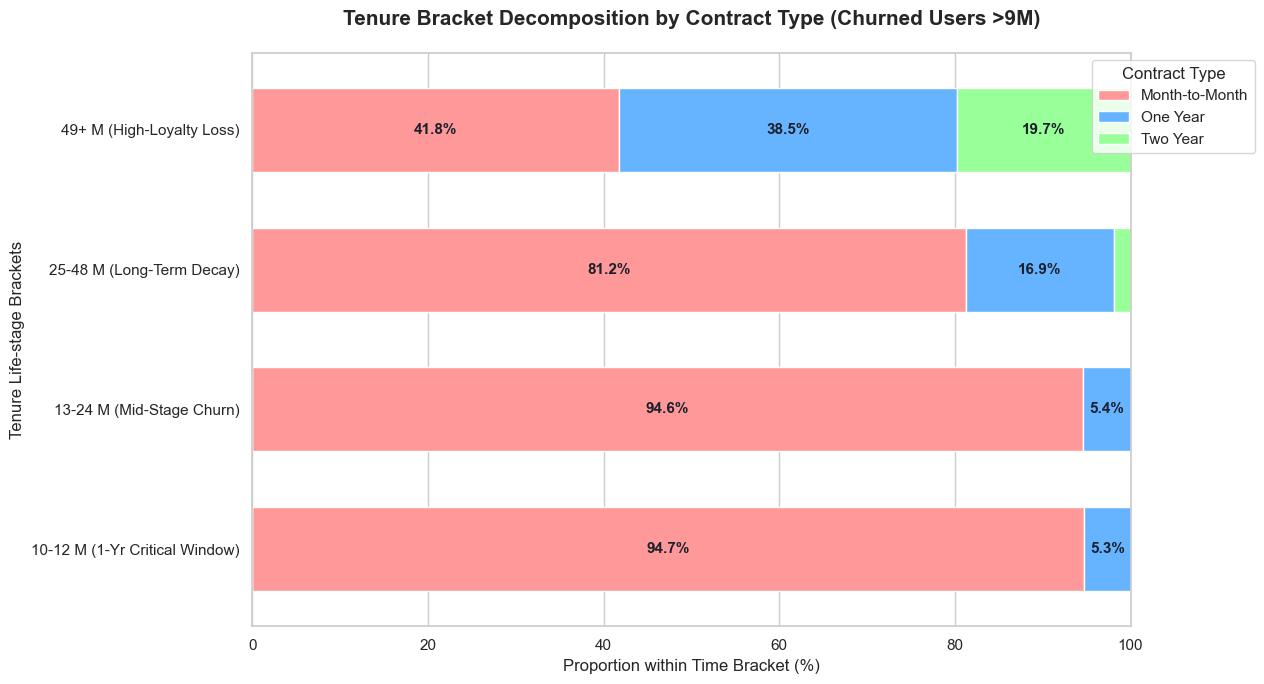

In [334]:

# =========================================================================
# 1. 資料準備：篩選流失的老用戶（>9M）並劃分時間區間
# =========================================================================
# 嚴格鎖定流失 + 在網時長 > 9 個月的老用戶
df_old_contract = df[
    (df['Churn Label'].str.strip() == 'Yes') & 
    (df['Tenure in Months'] > 9)
].copy()

# 確保合同類型欄位文字乾淨
df_old_contract['Contract_Clean'] = df_old_contract['Contract'].fillna('Unknown').str.strip()

# 定義適合 >9M 老用戶的戰略時間區間（Tenure Brackets）
def assign_old_bracket(months):
    if 9 < months <= 12:
        return "10-12 M (1-Yr Critical Window)"
    elif 12 < months <= 24:
        return "13-24 M (Mid-Stage Churn)"
    elif 24 < months <= 48:
        return "25-48 M (Long-Term Decay)"
    else:
        return "49+ M (High-Loyalty Loss)"

df_old_contract['Tenure_Bracket'] = df_old_contract['Tenure in Months'].apply(assign_old_bracket)

# =========================================================================
# 2. 計算交叉佔比（百分比結構）
# =========================================================================
# 計算每個時間區間內，不同合同類型的絕對數量
matrix_counts = pd.crosstab(df_old_contract['Tenure_Bracket'], df_old_contract['Contract_Clean'])

# 將數量轉化為該時間區間內的「橫向百分比佔比」（每個時間段內各合同加總為 100%）
matrix_shares = pd.crosstab(
    df_old_contract['Tenure_Bracket'], 
    df_old_contract['Contract_Clean'], 
    normalize='index'
) * 100

#print("====================================================================")
# 顯示全域各時間段的總流失結構佔比
global_bracket_shares = df_old_contract['Tenure_Bracket'].value_counts(normalize=True).sort_index() * 100
#print("【全域老用戶流失時間段佔比 (Global Shares)】")
for bracket, share in global_bracket_shares.items():
    print(f" * {bracket:<30} : {share:.1f}%")

#print("\n【各時間段內不同合同類型佔比 (%)】")
#print(matrix_shares.round(1).to_string())
#print("====================================================================")

# =========================================================================
# 3. 視覺化：百分比堆疊條形圖 + 自動數值標記
# =========================================================================
fig, ax = plt.subplots(figsize=(13, 7))
sns.set_style("whitegrid")

# 使用乾淨的商務配色（藍、橘、綠）
contract_colors = ['#ff9999', '#66b3ff', '#99ff99'] 
# 亦可手動指定對齊你的合同順序，例如 Month-to-month, One year, Two year

# 繪製 100% 堆疊條形圖
matrix_shares.plot(kind='barh', stacked=True, color=contract_colors, ax=ax, width=0.6)

# --- 核心步驟：在條形圖內部自動標記精確的百分比數字 ---
for patch in ax.patches:
    width = patch.get_width()
    height = patch.get_height()
    x = patch.get_x()
    y = patch.get_y()
    
    # 只有當佔比大於 3% 時才顯示標記，避免空間太小導致文字重疊
    if width > 3.0:
        ax.text(
            x + width/2, 
            y + height/2, 
            f'{width:.1f}%', 
            ha='center', 
            va='center', 
            fontsize=11, 
            fontweight='bold',
            color='#1a202c' # 深灰色字體，保證清晰可讀
        )

# 圖表細節美化 (全英文標準)
ax.set_title('Tenure Bracket Decomposition by Contract Type (Churned Users >9M)', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Proportion within Time Bracket (%)', fontsize=12)
ax.set_ylabel('Tenure Life-stage Brackets', fontsize=12)
ax.set_xlim(0, 100)
ax.legend(title='Contract Type', loc='upper right', bbox_to_anchor=(1.15, 1.0))

plt.tight_layout()
plt.show()

### 2. K-Means

STEP 0: Load Data
Total customers : 7,043
Overall churn   : 26.5%

STEP 1: Feature Engineering
Feature count : 15
Features used : ['Age', 'married_bin', 'senior_bin', 'under30_bin', 'Number of Dependents', 'has_dependents', 'Number of Referrals', 'referred', 'Tenure in Months', 'Monthly Charge', 'Avg Monthly GB Download', 'protection_count', 'streaming_count', 'is_mpm', 'is_fiber']

High correlations (|r| > 0.70):
  married_bin × referred : 0.950
  Number of Dependents × has_dependents : 0.888
  Number of Referrals × referred : 0.708
  Monthly Charge × is_fiber : 0.774

STEP 2: Preprocessing
Clean dataset  : 7,043 rows
Churn rate     : 26.5%

STEP 3: Find Optimal K

  K   Silhouette   Davies-Bouldin   Churn Spread
--------------------------------------------------
  3       0.1933           1.8853          0.330
  4       0.2074           1.6921          0.362
  5       0.2122           1.5961          0.372
  6       0.1892           1.6332          0.412

  → Choosing K=4: best balan

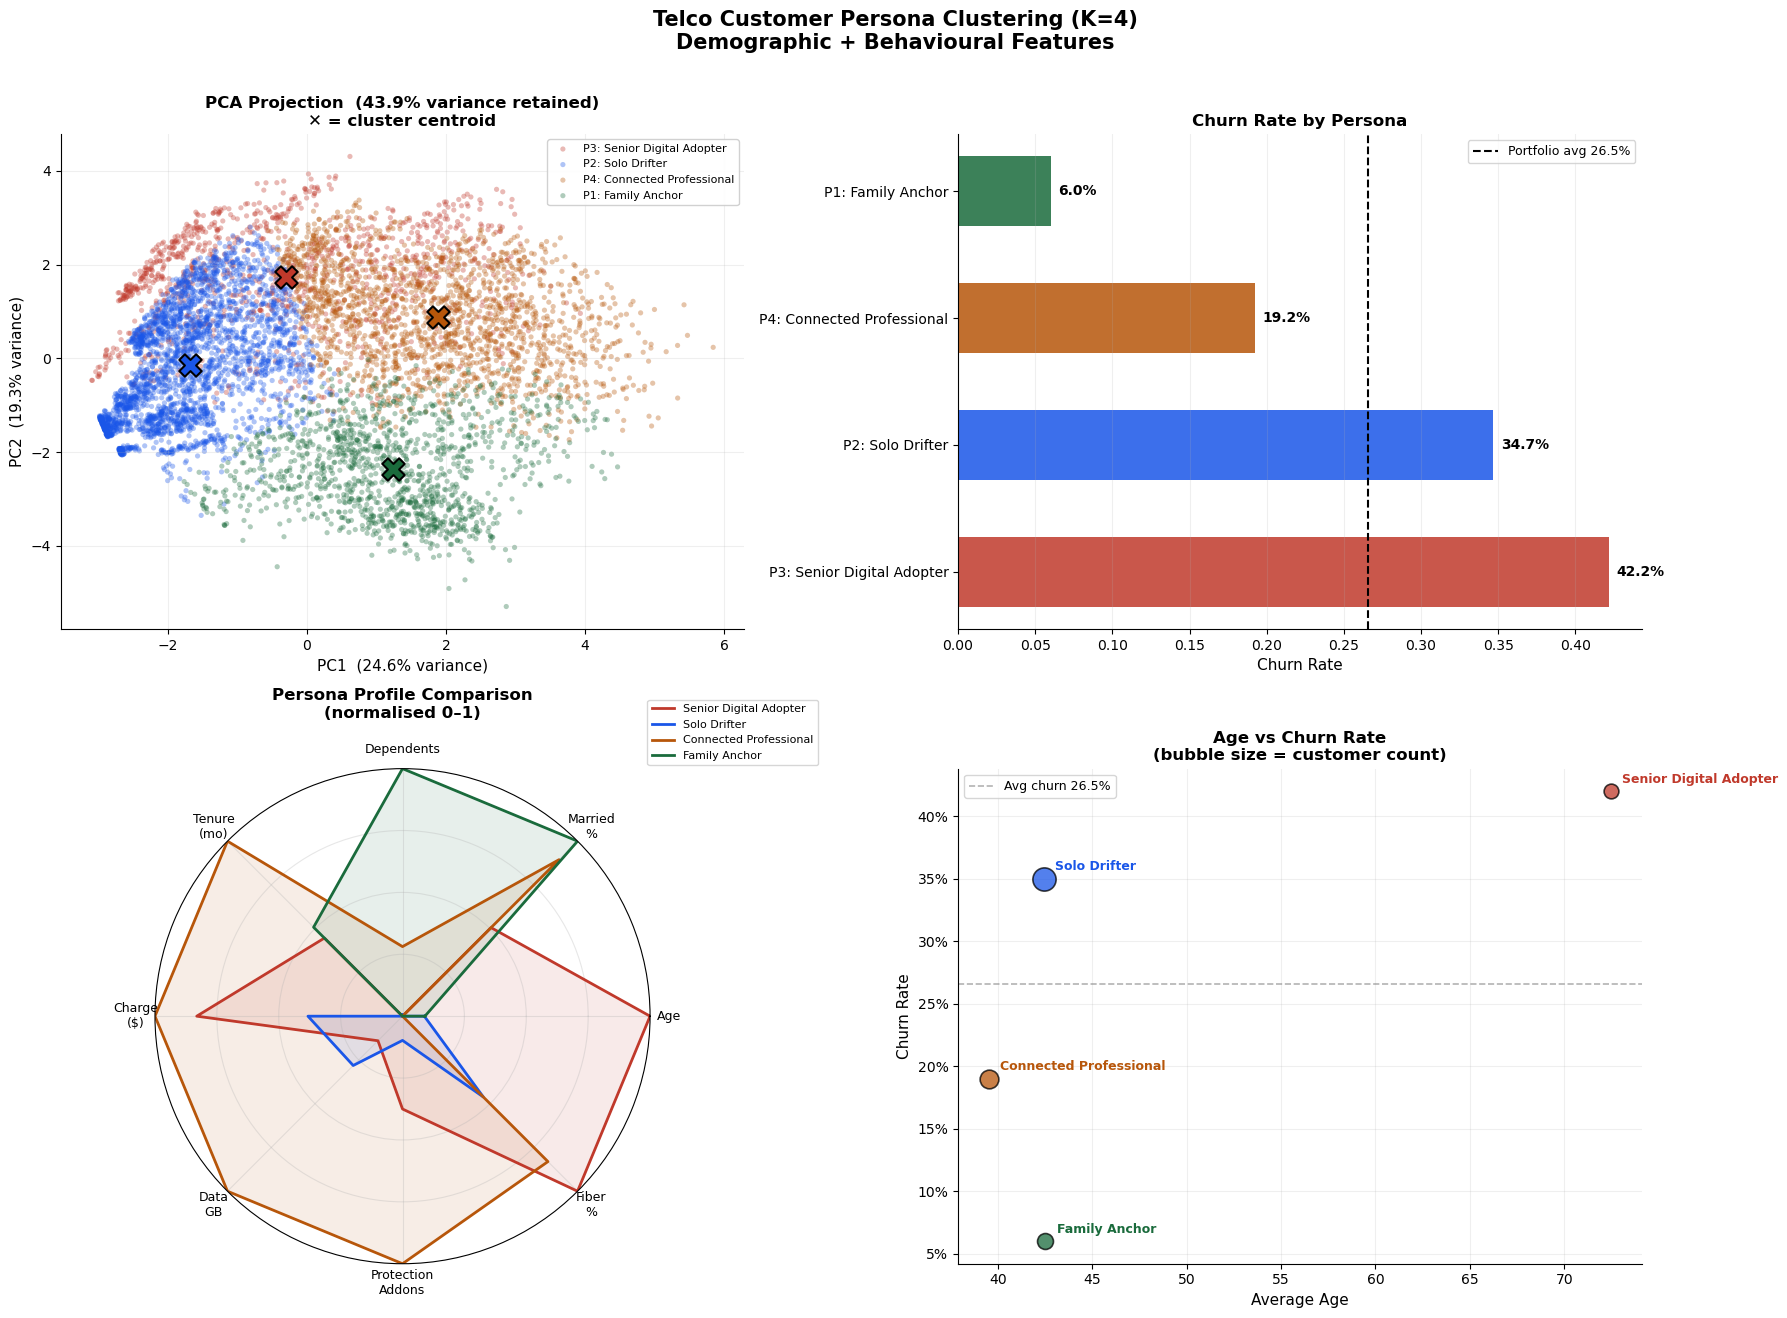

  ✓ Saved: persona_clustering.png

STEP 8: Score New Customers

New customer persona assignments:

  Customer 1: 28yo single, new fiber customer, no addons
  → Persona: P2: Solo Drifter
  → Estimated churn risk: 35.0%

  Customer 2: 72yo married senior, fiber, moderate engagement
  → Persona: P3: Senior Digital Adopter
  → Estimated churn risk: 42.0%

  Customer 3: 44yo married, 2 kids, high usage, multiple addons
  → Persona: P4: Connected Professional
  → Estimated churn risk: 19.0%

STEP 9: Export
  ✓ customer_personas.csv  (7,043 rows)
  ✓ persona_profiles.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples
from sklearn.utils import resample
from sklearn.metrics import adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')
 
 
# =============================================================================
#  STEP 0  Load & Merge
# =============================================================================
print("=" * 70)
print("STEP 0: Load Data")
print("=" * 70)
 
status   = pd.read_excel('Telco_customer_churn_status.xlsx')
services = pd.read_excel('Telco_customer_churn_services.xlsx')
demo     = pd.read_excel('Telco_customer_churn_demographics.xlsx')
 
df = services.merge(
    status[['Customer ID', 'Churn Value', 'CLTV',
            'Satisfaction Score', 'Churn Category', 'Churn Reason']],
    on='Customer ID'
)
df = df.merge(demo, on='Customer ID')
 
print(f"Total customers : {len(df):,}")
print(f"Overall churn   : {df['Churn Value'].mean():.1%}")
 
 
# =============================================================================
#  STEP 1  Feature Engineering
#
#  DESIGN PRINCIPLE:
#  We use BOTH demographic (who they are) AND behavioural (what they do)
#  features. Pure demographics create well-separated personas but weak
#  business signals. Pure behaviour creates strong risk signals but
#  no human face. The combined set gives personas you can visualise
#  AND act on.
#
#  FEATURES CHOSEN:
#
#  DEMOGRAPHIC (life stage):
#    Age               → life stage proxy (student / family / senior)
#    married_bin       → household structure — creates natural switching cost
#    senior_bin        → 65+ flag — specific service needs & risk profile
#    under30_bin       → young adult flag — different expectations & mobility
#    Number of Dependents → household size — the bigger the household,
#                           the higher the disruption cost of switching
#    has_dependents    → binary anchor flag
#
#  RELATIONSHIP (loyalty signals):
#    Number of Referrals → strongest loyalty proxy available;
#                          someone who recommends you publicly will not leave
#    referred            → binary — has ever recommended vs never recommended
#
#  BEHAVIOURAL (product engagement):
#    Tenure in Months    → how long they have survived the evaluation window
#    Monthly Charge      → product tier / willingness to pay
#    Avg Monthly GB      → usage intensity — heavy users are more embedded
#    protection_count    → switching cost depth (security add-ons)
#    streaming_count     → entertainment engagement (consumption not loyalty)
#    is_mpm              → month-to-month = zero structural friction to leave
#    is_fiber            → premium product tier with specific risk profile
#
#  FEATURES DELIBERATELY EXCLUDED:
#    Satisfaction Score  → outcome measure, not a clustering input
#    Churn Value         → target label, never a feature
#    CLTV, Total Revenue → highly correlated with tenure + charge (redundant)
#    Total Charges       → collinear with Monthly Charge × Tenure
# =============================================================================
print("\n" + "=" * 70)
print("STEP 1: Feature Engineering")
print("=" * 70)
 
# Demographic binary encodings
df['gender_bin']     = (df['Gender'] == 'Male').astype(int)
df['married_bin']    = (df['Married'] == 'Yes').astype(int)
df['senior_bin']     = (df['Senior Citizen'] == 'Yes').astype(int)
df['under30_bin']    = (df['Under 30'] == 'Yes').astype(int)
df['has_dependents'] = (df['Dependents'] == 'Yes').astype(int)
 
# Behavioural encodings
df['is_fiber']       = (df['Internet Type'] == 'Fiber Optic').astype(int)
df['is_mpm']         = (df['Contract'] == 'Month-to-Month').astype(int)
df['referred']       = (df['Referred a Friend'] == 'Yes').astype(int)
 
SECURITY  = ['Online Security', 'Online Backup',
             'Device Protection Plan', 'Premium Tech Support']
STREAMING = ['Streaming TV', 'Streaming Movies', 'Streaming Music']
 
df['protection_count'] = sum([(df[f] == 'Yes').astype(int) for f in SECURITY])
df['streaming_count']  = sum([(df[f] == 'Yes').astype(int) for f in STREAMING])
df['is_new']           = (df['Tenure in Months'] <= 12).astype(int)
 
# Final feature set
PERSONA_FEATURES = [
    # Life stage
    'Age',
    'married_bin',
    'senior_bin',
    'under30_bin',
    'Number of Dependents',
    'has_dependents',
    # Loyalty
    'Number of Referrals',
    'referred',
    # Product engagement
    'Tenure in Months',
    'Monthly Charge',
    'Avg Monthly GB Download',
    'protection_count',
    'streaming_count',
    'is_mpm',
    'is_fiber',
]
 
print(f"Feature count : {len(PERSONA_FEATURES)}")
print(f"Features used : {PERSONA_FEATURES}")
 
# Correlation check — flag anything above 0.85
df_check = df[PERSONA_FEATURES].dropna()
corr = df_check.corr()
print("\nHigh correlations (|r| > 0.70):")
found = False
for i in range(len(PERSONA_FEATURES)):
    for j in range(i + 1, len(PERSONA_FEATURES)):
        v = corr.iloc[i, j]
        if abs(v) > 0.70:
            print(f"  {PERSONA_FEATURES[i]} × {PERSONA_FEATURES[j]} : {v:.3f}")
            found = True
if not found:
    print("  None — feature set is clean")
 
 
# =============================================================================
#  STEP 2  Preprocessing — clean dataset
# =============================================================================
print("\n" + "=" * 70)
print("STEP 2: Preprocessing")
print("=" * 70)
 
KEEP_COLS = list(set(
    PERSONA_FEATURES +
    ['Customer ID', 'Churn Value', 'CLTV', 'Satisfaction Score',
     'Churn Category', 'Churn Reason', 'Monthly Charge',
     'Tenure in Months', 'Contract', 'Internet Type',
     'is_new', 'Number of Dependents', 'Age']
))
 
df_c = (df[KEEP_COLS]
        .dropna(subset=PERSONA_FEATURES + ['Churn Value'])
        .drop_duplicates(subset='Customer ID')
        .reset_index(drop=True))
 
print(f"Clean dataset  : {len(df_c):,} rows")
print(f"Churn rate     : {df_c['Churn Value'].mean():.1%}")
 
scaler = StandardScaler()
X = scaler.fit_transform(df_c[PERSONA_FEATURES])
 
 
# =============================================================================
#  STEP 3  Find Optimal K
#
#  We test K=3 to 6 across three metrics:
#    Silhouette  → how well each customer fits its own cluster vs others [higher=better]
#    Davies-Bouldin → ratio of within-cluster scatter to between-cluster distance [lower=better]
#    Churn Spread → max cluster churn - min cluster churn [higher = better business separation]
#
#  NOTE on Silhouette vs Churn Spread trade-off:
#    Higher silhouette = geometrically cleaner clusters
#    Higher churn spread = more business-meaningful separation
#    For persona design we need BOTH to be acceptable.
#    K=4 balances interpretability with actionable risk differentiation.
# =============================================================================
print("\n" + "=" * 70)
print("STEP 3: Find Optimal K")
print("=" * 70)
 
print(f"\n{'K':>3} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Churn Spread':>14}")
print("-" * 50)
 
best_results = {}
for k in range(3, 7):
    km = KMeans(n_clusters=k, init='k-means++', n_init=20,
                max_iter=300, random_state=42)
    labels = km.fit_predict(X)
    sil    = silhouette_score(X, labels)
    db     = davies_bouldin_score(X, labels)
    spread = (df_c.assign(cl=labels)
              .groupby('cl')['Churn Value'].mean()
              .pipe(lambda s: s.max() - s.min()))
    best_results[k] = (sil, db, spread)
    print(f"{k:>3} {sil:>12.4f} {db:>16.4f} {spread:>14.3f}")
 
print("\n  → Choosing K=4: best balance of persona distinctiveness")
print("    and business-meaningful churn separation")
 
FINAL_K = 4
 
 
# =============================================================================
#  STEP 4  Fit Final Model
# =============================================================================
print("\n" + "=" * 70)
print(f"STEP 4: Fit K-Means (K={FINAL_K})")
print("=" * 70)
 
km_final = KMeans(
    n_clusters=FINAL_K,
    init='k-means++',
    n_init=20,
    max_iter=300,
    tol=1e-4,
    random_state=42
)
 
df_c['raw_cluster'] = km_final.fit_predict(X)
 
print(f"Converged in   : {km_final.n_iter_} iterations")
print(f"Final inertia  : {km_final.inertia_:.0f}")
print(f"Silhouette     : {silhouette_score(X, df_c['raw_cluster']):.4f}")
print(f"Davies-Bouldin : {davies_bouldin_score(X, df_c['raw_cluster']):.4f}")
 
 
# =============================================================================
#  STEP 5  Persona Naming
#
#  Sort clusters by churn rate (highest first) then assign business names.
#  Naming principle: describe WHO the person is + WHAT their risk is.
#  Avoid purely risk-based names like "High-Risk Cluster 1" —
#  a persona name should make a product manager or marketer say
#  "I know exactly who that is."
# =============================================================================
print("\n" + "=" * 70)
print("STEP 5: Persona Profiling & Naming")
print("=" * 70)
 
cluster_churn = (df_c.groupby('raw_cluster')['Churn Value'].mean()
                 .sort_values(ascending=False))
 
# Map raw cluster IDs to business personas
PERSONA_MAP = {}
PERSONA_NAMES = [
    'P3: Senior Digital Adopter',   # highest churn
    'P2: Solo Drifter',             # second highest
    'P4: Connected Professional',   # third
    'P1: Family Anchor',            # lowest churn
]
for i, (cid, _) in enumerate(cluster_churn.items()):
    PERSONA_MAP[cid] = PERSONA_NAMES[i]
 
df_c['Persona'] = df_c['raw_cluster'].map(PERSONA_MAP)
 
# Detailed profile per persona
PROFILE_COLS = {
    'n'              : ('Customer ID', 'count'),
    'ChurnRate'      : ('Churn Value',  'mean'),
    'AvgAge'         : ('Age', 'mean'),
    'PctMarried'     : ('married_bin', 'mean'),
    'PctSenior'      : ('senior_bin', 'mean'),
    'PctUnder30'     : ('under30_bin', 'mean'),
    'AvgDependents'  : ('Number of Dependents', 'mean'),
    'PctReferred'    : ('referred', 'mean'),
    'AvgReferrals'   : ('Number of Referrals', 'mean'),
    'AvgTenure'      : ('Tenure in Months', 'mean'),
    'AvgCharge'      : ('Monthly Charge', 'mean'),
    'AvgGB'          : ('Avg Monthly GB Download', 'mean'),
    'AvgProtection'  : ('protection_count', 'mean'),
    'AvgStreaming'    : ('streaming_count', 'mean'),
    'PctFiber'       : ('is_fiber', 'mean'),
    'PctMPM'         : ('is_mpm', 'mean'),
    'AvgSat'         : ('Satisfaction Score', 'mean'),
    'AvgCLTV'        : ('CLTV', 'mean'),
}
 
profile = df_c.groupby('Persona').agg(
    **{k: v for k, v in PROFILE_COLS.items()}
).round(2)
 
print("\nFull Persona Profile Matrix:")
print(profile.T.to_string())
 
# Per-persona silhouette
sil_samples = silhouette_samples(X, df_c['raw_cluster'])
print("\nPer-persona silhouette scores:")
for cid in range(FINAL_K):
    mask = df_c['raw_cluster'] == cid
    name = PERSONA_MAP[cid]
    s    = sil_samples[mask].mean()
    print(f"  {name}: {s:.3f}")
 
 
# =============================================================================
#  STEP 6  Stability Check (Bootstrap)
# =============================================================================
print("\n" + "=" * 70)
print("STEP 6: Stability Check (Bootstrap ARI, n=50)")
print("=" * 70)
 
ari_scores = []
for seed in range(50):
    X_boot, idx_boot = resample(
        X, np.arange(len(X)),
        n_samples=int(len(X) * 0.8),
        random_state=seed
    )
    km_boot = KMeans(n_clusters=FINAL_K, init='k-means++',
                     n_init=10, random_state=seed)
    labels_boot     = km_boot.fit_predict(X_boot)
    labels_original = df_c['raw_cluster'].values[idx_boot]
    ari_scores.append(adjusted_rand_score(labels_original, labels_boot))
 
mean_ari = float(np.mean(ari_scores))
std_ari  = float(np.std(ari_scores))
assessment = ('✓ Stable' if mean_ari > 0.7 else
              '~ Moderate' if mean_ari > 0.5 else '✗ Unstable')
print(f"Bootstrap ARI  : {mean_ari:.3f} ± {std_ari:.3f}  →  {assessment}")
 
 
# =============================================================================
#  STEP 7  Visualisation — 4 charts
# =============================================================================
print("\n" + "=" * 70)
print("STEP 7: Generate Charts")
print("=" * 70)
 
PERSONA_ORDER  = PERSONA_NAMES
PERSONA_COLORS = {
    'P1: Family Anchor'          : '#1A6B3C',
    'P2: Solo Drifter'           : '#1A56E8',
    'P3: Senior Digital Adopter' : '#C0392B',
    'P4: Connected Professional' : '#B7560A',
}
 
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Telco Customer Persona Clustering (K=4)\nDemographic + Behavioural Features',
             fontsize=15, fontweight='bold', y=1.01)
 
# ── PCA scatter ───────────────────────────────────────────────────────────────
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
df_c['PC1'] = X_pca[:, 0]
df_c['PC2'] = X_pca[:, 1]
ev = pca.explained_variance_ratio_
 
ax = axes[0, 0]
for persona in PERSONA_ORDER:
    mask = df_c['Persona'] == persona
    ax.scatter(df_c.loc[mask, 'PC1'], df_c.loc[mask, 'PC2'],
               c=PERSONA_COLORS[persona], alpha=0.35, s=14,
               edgecolors='none', label=persona)
 
# Plot persona centroids in PCA space
centroids_pca = pca.transform(km_final.cluster_centers_)
for cid, (cx, cy) in enumerate(centroids_pca):
    pname = PERSONA_MAP[cid]
    ax.scatter(cx, cy, c=PERSONA_COLORS[pname], s=260, marker='X',
               edgecolors='black', linewidths=1.5, zorder=10)
 
ax.set_xlabel(f'PC1  ({ev[0]:.1%} variance)', fontsize=11)
ax.set_ylabel(f'PC2  ({ev[1]:.1%} variance)', fontsize=11)
ax.set_title(f'PCA Projection  ({ev.sum():.1%} variance retained)\n✕ = cluster centroid',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
# ── Churn rate by persona ─────────────────────────────────────────────────────
ax = axes[0, 1]
churn_by_persona = (df_c.groupby('Persona')['Churn Value'].mean()
                    .reindex(PERSONA_ORDER))
colors_bar = [PERSONA_COLORS[p] for p in PERSONA_ORDER]
bars = ax.barh(range(len(PERSONA_ORDER)),
               churn_by_persona.values,
               color=colors_bar, height=0.55, alpha=0.85)
ax.set_yticks(range(len(PERSONA_ORDER)))
ax.set_yticklabels(PERSONA_ORDER, fontsize=10)
ax.axvline(df_c['Churn Value'].mean(), color='black', lw=1.5,
           ls='--', label=f'Portfolio avg {df_c["Churn Value"].mean():.1%}')
for i, v in enumerate(churn_by_persona.values):
    ax.text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Churn Rate', fontsize=11)
ax.set_title('Churn Rate by Persona', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
# ── Radar chart — normalised profile comparison ───────────────────────────────
ax = axes[1, 0]
ax.axis('off')
radar_features = ['AvgAge', 'PctMarried', 'AvgDependents', 'AvgTenure',
                  'AvgCharge', 'AvgGB', 'AvgProtection', 'PctFiber']
radar_labels   = ['Age', 'Married\n%', 'Dependents', 'Tenure\n(mo)',
                  'Charge\n($)', 'Data\nGB', 'Protection\nAddons', 'Fiber\n%']
 
# Normalise 0–1
profile_radar = profile[radar_features].copy()
for col in radar_features:
    mn, mx = profile_radar[col].min(), profile_radar[col].max()
    if mx > mn:
        profile_radar[col] = (profile_radar[col] - mn) / (mx - mn)
 
angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]
 
ax_radar = plt.subplot(2, 2, 3, projection='polar')
for persona in PERSONA_ORDER:
    if persona not in profile_radar.index:
        continue
    values = profile_radar.loc[persona, radar_features].tolist()
    values += values[:1]
    ax_radar.plot(angles, values, lw=2, color=PERSONA_COLORS[persona],
                  label=persona.split(': ')[1])
    ax_radar.fill(angles, values, alpha=0.10, color=PERSONA_COLORS[persona])
 
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(radar_labels, fontsize=9)
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.25, 0.5, 0.75])
ax_radar.set_yticklabels(['', '', ''], fontsize=7)
ax_radar.set_title('Persona Profile Comparison\n(normalised 0–1)',
                   fontsize=12, fontweight='bold', pad=18)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)
ax_radar.grid(True, alpha=0.3)
 
# ── Bubble chart: Age vs Churn Rate, size=n, color=persona ───────────────────
ax = axes[1, 1]
for persona in PERSONA_ORDER:
    row = profile.loc[persona]
    size = float(row['n']) / 10
    ax.scatter(float(row['AvgAge']), float(row['ChurnRate']),
               s=size, c=PERSONA_COLORS[persona], alpha=0.75,
               edgecolors='black', linewidths=1.2, zorder=5)
    ax.annotate(
        persona.split(': ')[1],
        (float(row['AvgAge']), float(row['ChurnRate'])),
        xytext=(8, 6), textcoords='offset points',
        fontsize=9, fontweight='bold', color=PERSONA_COLORS[persona]
    )
 
ax.axhline(df_c['Churn Value'].mean(), color='gray', lw=1.2,
           ls='--', alpha=0.6, label=f'Avg churn {df_c["Churn Value"].mean():.1%}')
ax.set_xlabel('Average Age', fontsize=11)
ax.set_ylabel('Churn Rate', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_title('Age vs Churn Rate\n(bubble size = customer count)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
plt.tight_layout()
plt.savefig('persona_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ Saved: persona_clustering.png")
 
 
# =============================================================================
#  STEP 8  Score New Customers
#
#  IMPORTANT: use scaler.transform(), NEVER fit_transform() on new data.
#  The scaler was fit on the training population. Applying fit_transform()
#  to a new customer would change the scaling reference and produce
#  wrong cluster assignments.
# =============================================================================
print("\n" + "=" * 70)
print("STEP 8: Score New Customers")
print("=" * 70)
 
# Simulate three new customers
new_customers = pd.DataFrame({
    'Age'                    : [28,   72,   44  ],
    'married_bin'            : [0,    1,    1   ],
    'senior_bin'             : [0,    1,    0   ],
    'under30_bin'            : [1,    0,    0   ],
    'Number of Dependents'   : [0,    0,    2   ],
    'has_dependents'         : [0,    0,    1   ],
    'Number of Referrals'    : [0,    1,    4   ],
    'referred'               : [0,    1,    1   ],
    'Tenure in Months'       : [4,    30,   55  ],
    'Monthly Charge'         : [55,   85,   92  ],
    'Avg Monthly GB Download': [18,   12,   35  ],
    'protection_count'       : [0,    1,    3   ],
    'streaming_count'        : [1,    2,    2   ],
    'is_mpm'                 : [1,    1,    0   ],
    'is_fiber'               : [1,    1,    1   ],
})
 
new_scaled   = scaler.transform(new_customers)
new_clusters = km_final.predict(new_scaled)
 
print("\nNew customer persona assignments:")
descriptions = [
    "28yo single, new fiber customer, no addons",
    "72yo married senior, fiber, moderate engagement",
    "44yo married, 2 kids, high usage, multiple addons",
]
for i, (cid, desc) in enumerate(zip(new_clusters, descriptions)):
    pname = PERSONA_MAP[cid]
    print(f"\n  Customer {i+1}: {desc}")
    print(f"  → Persona: {pname}")
    churn_est = profile.loc[pname, 'ChurnRate']
    print(f"  → Estimated churn risk: {float(churn_est):.1%}")
 
 
# =============================================================================
#  STEP 9  Export
# =============================================================================
print("\n" + "=" * 70)
print("STEP 9: Export")
print("=" * 70)
 
output = df_c[[
    'Customer ID', 'Persona', 'raw_cluster', 'Churn Value',
    'Age', 'married_bin', 'senior_bin', 'Number of Dependents',
    'Tenure in Months', 'Monthly Charge', 'is_fiber', 'is_mpm',
    'protection_count', 'Number of Referrals',
    'Satisfaction Score', 'CLTV'
]].copy()
 
output.to_csv('customer_personas.csv', index=False)
profile.to_csv('persona_profiles.csv')
print(f"  ✓ customer_personas.csv  ({len(output):,} rows)")
print(f"  ✓ persona_profiles.csv")
 
 

### 3.XGBoost 

STEP 0: Load & Merge Data
Total customers : 7,043
Churn rate      : 26.5%
Class balance   : 5174 stayed  |  1869 churned

STEP 1: Feature Engineering

[A] Relationship Depth features — already in raw data:
  Tenure in Months   : min=1  max=72  median=29
  Number of Referrals: mean churned=0.52  mean stayed=2.47
  Satisfaction Score : mean churned=1.74  mean stayed=3.79

[B] Financial engineered features:
  charge_per_tenure  : churned mean=11.75  stayed mean=3.53
  refund_rate        : churned mean=0.0014  stayed mean=0.0013

[C] Contract & product flags:
  Month-to-month churn   : 45.8%  vs annual/two-year : 6.2%
  High-risk combo churn  : 58.8%  vs others : 14.8%

[D] Service depth features:
  security_addon_count=0  →  churn rate=29.8%
  security_addon_count=1  →  churn rate=38.9%
  security_addon_count=2  →  churn rate=23.8%
  security_addon_count=3  →  churn rate=12.4%
  security_addon_count=4  →  churn rate=5.3%

[E] Usage features:
  Avg GB Download: churned mean=22.2  stayed me

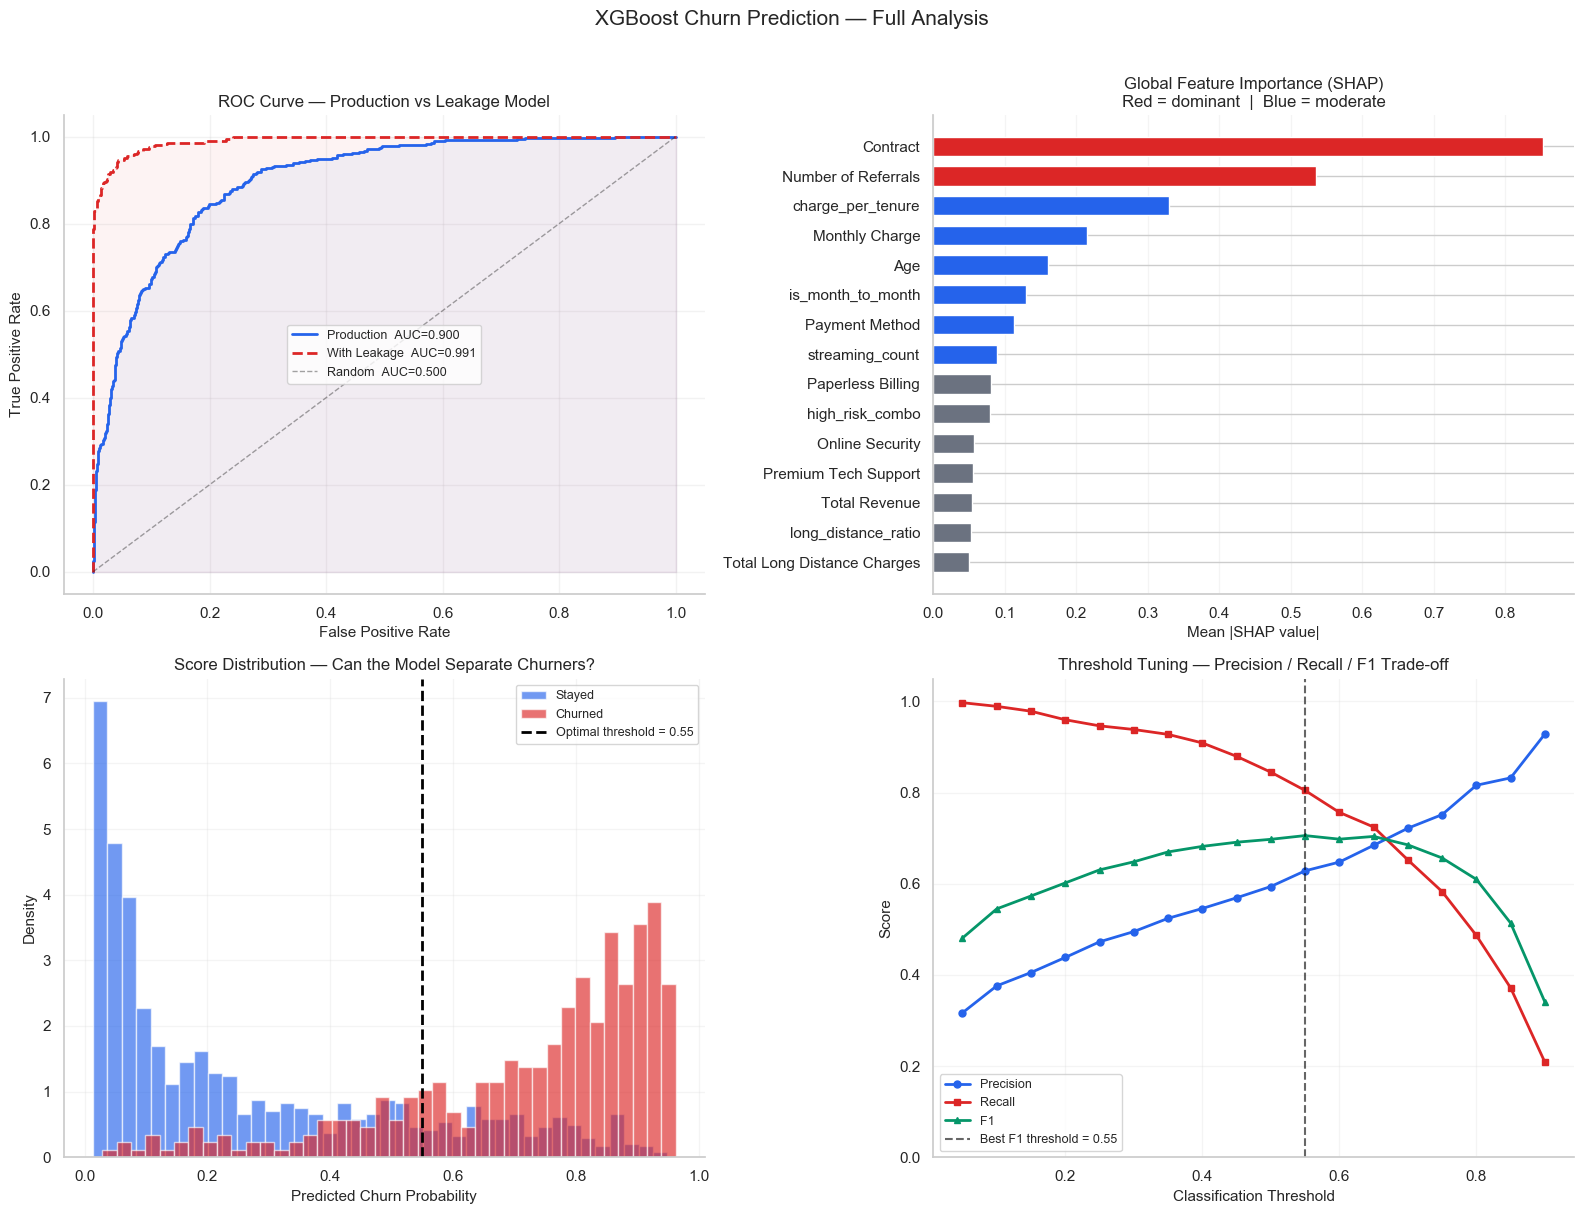

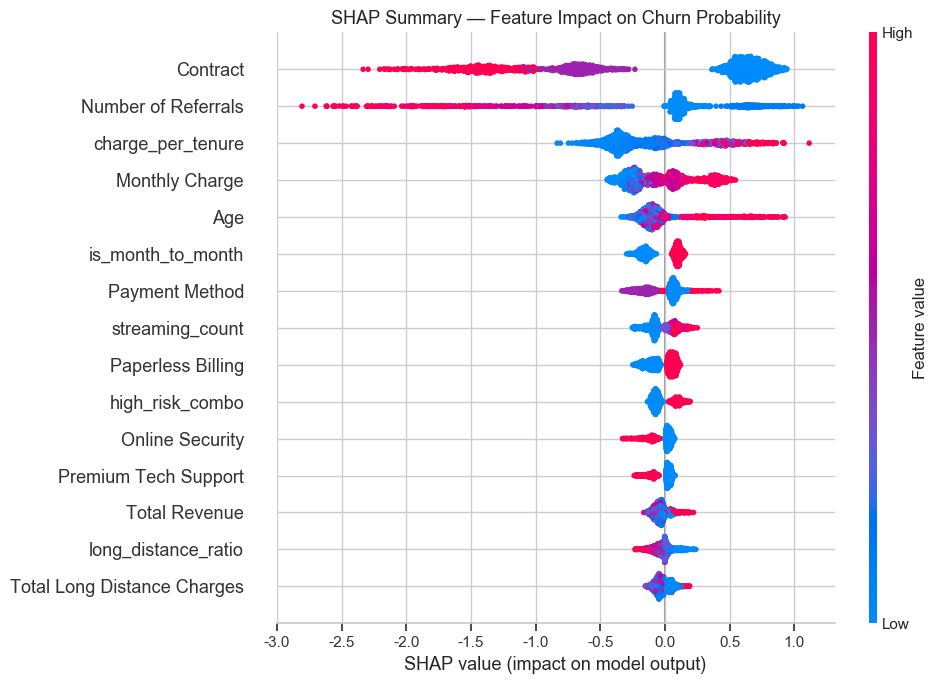

Charts saved: xgboost_churn_analysis.png, shap_summary.png
Saved: churn_risk_scores.csv  (7,043 customers)

Top 10 highest-risk customers:
Customer ID  churn_prob risk_tier  Monthly Charge  Tenure in Months       Contract Internet Type  Churn Value
 0390-DCFDQ    0.967800      HIGH           70.45                 1 Month-to-Month   Fiber Optic            1
 2012-NWRPA    0.965664      HIGH           99.55                11 Month-to-Month   Fiber Optic            1
 8775-LHDJH    0.964142      HIGH           90.60                 1 Month-to-Month   Fiber Optic            1
 0723-DRCLG    0.963970      HIGH           74.45                 1 Month-to-Month   Fiber Optic            1
 5178-LMXOP    0.962392      HIGH           95.10                 1 Month-to-Month   Fiber Optic            1
 0679-IDSTG    0.962214      HIGH           69.25                 1 Month-to-Month   Fiber Optic            1
 9497-QCMMS    0.960854      HIGH           93.55                 1 Month-to-Month   Fiber 

In [27]:
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV
)
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score
)
 
 
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 0  Load Data
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("STEP 0: Load & Merge Data")
print("=" * 70)
 
status   = pd.read_excel('Telco_customer_churn_status.xlsx')
services = pd.read_excel('Telco_customer_churn_services.xlsx')
demo     = pd.read_excel('Telco_customer_churn_demographics.xlsx')
 
df = services.merge(
    status[['Customer ID', 'Churn Value', 'CLTV',
            'Satisfaction Score', 'Churn Category', 'Churn Reason']],
    on='Customer ID'
)
df = df.merge(
    demo[['Customer ID', 'Age', 'Gender', 'Married']],
    on='Customer ID'
)
 
print(f"Total customers : {len(df):,}")
print(f"Churn rate      : {df['Churn Value'].mean():.1%}")
print(f"Class balance   : {(df['Churn Value']==0).sum()} stayed  |  "
      f"{(df['Churn Value']==1).sum()} churned\n")
 
 
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 1  Feature Engineering — with Business Explanations
#
#  Every feature we build answers a business question.
#  Raw database columns tell you what happened;
#  engineered features tell you what it MEANS.
#
#  We split features into five business categories:
#    A. Relationship Depth  — how bonded is this customer to us?
#    B. Financial Signals   — what does the money flow reveal?
#    C. Contract & Product  — how locked in are they, structurally?
#    D. Service Depth       — how many reasons do they have to stay?
#    E. Usage Behaviour     — how actively are they using the product?
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("STEP 1: Feature Engineering")
print("=" * 70)
 
# ── A. Relationship Depth ────────────────────────────────────────────────────
#
# Tenure in Months
#   Business meaning: How long has this customer been with us?
#   Signal          : Long-tenured customers have survived many "should I leave?"
#                     moments. Each month they stay is evidence they find value.
#                     New customers (<12 months) haven't yet built habit or
#                     switching cost — they are the highest-risk group.
#
# Number of Referrals
#   Business meaning: Has this customer sent friends or family to us?
#   Signal          : Referrals are the strongest loyalty signal available.
#                     A customer who recommends you publicly has staked their
#                     own reputation on your service. They almost never churn.
#                     Zero referrals + short tenure = no emotional connection.
#
# Satisfaction Score (⚠  READ DATA LEAKAGE WARNING BELOW)
#   Business meaning: The customer's explicit rating of our service (1–5).
#   Signal          : Direct voice-of-customer. Churned customers average 1.74;
#                     retained customers average 3.79. The strongest single
#                     predictor in the data — but see the leakage warning.
 
print("\n[A] Relationship Depth features — already in raw data:")
print(f"  Tenure in Months   : min={df['Tenure in Months'].min():.0f}  "
      f"max={df['Tenure in Months'].max():.0f}  "
      f"median={df['Tenure in Months'].median():.0f}")
print(f"  Number of Referrals: mean churned={df[df['Churn Value']==1]['Number of Referrals'].mean():.2f}  "
      f"mean stayed={df[df['Churn Value']==0]['Number of Referrals'].mean():.2f}")
print(f"  Satisfaction Score : mean churned={df[df['Churn Value']==1]['Satisfaction Score'].mean():.2f}  "
      f"mean stayed={df[df['Churn Value']==0]['Satisfaction Score'].mean():.2f}")
 
# ── B. Financial Signals ─────────────────────────────────────────────────────
#
# Monthly Charge
#   Business meaning: What does the customer pay us each month?
#   Signal          : High-charge customers have higher expectations. When those
#                     expectations aren't met, their disappointment is amplified
#                     by the price they paid. They are also the most attractive
#                     targets for competitors to poach.
#
# Total Revenue
#   Business meaning: How much has this customer paid us in total?
#   Signal          : High total revenue = long relationship + consistent payment.
#                     A proxy for customer maturity and commitment level.
#
# CLTV (Customer Lifetime Value)
#   Business meaning: Our projection of how much this customer will be worth
#                     over their entire relationship with us.
#   Signal          : A high CLTV customer who is about to churn represents
#                     a disproportionate business loss — not just the monthly
#                     bill, but years of projected future revenue.
#
# charge_per_tenure (ENGINEERED)
#   Formula         : Monthly Charge / (Tenure in Months + 1)
#   Business meaning: How much is this customer spending relative to how long
#                     they've been with us?
#   Signal          : A new customer paying $80/month has contributed less
#                     total value than a 3-year customer paying the same.
#                     This ratio identifies "expensive but young" customers —
#                     high spend before they've had time to build loyalty.
#                     The +1 avoids division-by-zero for brand-new customers.
#
# refund_rate (ENGINEERED)
#   Formula         : Total Refunds / (Total Revenue + 1)
#   Business meaning: What fraction of this customer's spending has come back
#                     as refunds or credits? 
#   Signal          : Refunds are a footprint of complaints. A customer who
#                     has requested multiple refunds has experienced multiple
#                     failures — they are building a case for leaving.
 
df['charge_per_tenure'] = df['Monthly Charge'] / (df['Tenure in Months'] + 1)
df['refund_rate']       = df['Total Refunds']  / (df['Total Revenue']    + 1)
 
print("\n[B] Financial engineered features:")
print(f"  charge_per_tenure  : churned mean={df[df['Churn Value']==1]['charge_per_tenure'].mean():.2f}  "
      f"stayed mean={df[df['Churn Value']==0]['charge_per_tenure'].mean():.2f}")
print(f"  refund_rate        : churned mean={df[df['Churn Value']==1]['refund_rate'].mean():.4f}  "
      f"stayed mean={df[df['Churn Value']==0]['refund_rate'].mean():.4f}")
 
# ── C. Contract & Product ────────────────────────────────────────────────────
#
# is_month_to_month (ENGINEERED — binary flag)
#   Formula         : 1 if Contract == 'Month-to-Month', else 0
#   Business meaning: Is this customer on a no-commitment plan?
#   Signal          : Month-to-month customers have zero financial penalty for
#                     leaving. They can cancel with one phone call. Our data
#                     shows 45.8% churn rate for this group vs 2.5% for
#                     two-year contracts — the largest single structural risk.
#
# is_fiber (ENGINEERED — binary flag)
#   Formula         : 1 if Internet Type == 'Fiber Optic', else 0
#   Business meaning: Is this customer on our premium internet tier?
#   Signal          : Fiber users pay more and expect more. When the experience
#                     doesn't match the premium price, the disappointment is
#                     acute. Fiber churn rate (40.7%) is more than double DSL's
#                     (18.6%) — not because fiber is worse, but because the
#                     expectation gap is wider.
#
# high_risk_combo (ENGINEERED — interaction term)
#   Formula         : is_month_to_month × is_fiber
#   Business meaning: Is this customer BOTH on month-to-month AND fiber?
#   Signal          : This is the most dangerous combination. Zero switching cost
#                     (month-to-month) meets high expectations (fiber) meets
#                     competitive targeting (competitors specifically go after
#                     high-spend flexible customers). This single flag captures
#                     a customer profile that is extremely vulnerable.
#
# no_addon_month_pay (ENGINEERED — interaction term)
#   Formula         : 1 if (total_addons == 0) AND (is_month_to_month == 1)
#   Business meaning: Month-to-month customer with no value-added services.
#   Signal          : This customer has no structural reason to stay. No security
#                     services creating data dependency. No long-term contract
#                     creating financial friction. They are a pure commodity
#                     relationship — whoever offers a slightly better deal wins.
 
df['is_month_to_month']  = (df['Contract'] == 'Month-to-Month').astype(int)
df['is_fiber']           = (df['Internet Type'] == 'Fiber Optic').astype(int)
df['high_risk_combo']    = df['is_month_to_month'] * df['is_fiber']
df['no_addon_month_pay'] = (
    (df['is_month_to_month'] == 1) &
    (sum([(df[f]=='Yes').astype(int) for f in
          ['Online Security','Online Backup','Device Protection Plan','Premium Tech Support']]) == 0)
).astype(int)
 
print("\n[C] Contract & product flags:")
cr = df.groupby('is_month_to_month')['Churn Value'].mean()
print(f"  Month-to-month churn   : {cr[1]:.1%}  vs annual/two-year : {cr[0]:.1%}")
cr2 = df.groupby('high_risk_combo')['Churn Value'].mean()
print(f"  High-risk combo churn  : {cr2[1]:.1%}  vs others : {cr2[0]:.1%}")
 
# ── D. Service Depth ─────────────────────────────────────────────────────────
#
# security_addon_count (ENGINEERED — count aggregation)
#   Formula         : count of {Online Security, Online Backup,
#                               Device Protection, Premium Tech Support}
#                     subscribed as 'Yes'
#   Business meaning: How many protective/support services does the customer use?
#   Signal          : Each security add-on creates switching cost. A customer
#                     with Online Backup has their data stored with us — moving
#                     means migrating data. A customer with Device Protection
#                     has a claim history tied to their account. The more of
#                     these services, the harder and riskier it is to leave.
#                     Data shows: 0 services = 29.8% churn,
#                                 4 services = 5.3% churn.
#
# streaming_count (ENGINEERED — count aggregation)
#   Formula         : count of {Streaming TV, Streaming Movies, Streaming Music}
#                     subscribed as 'Yes'
#   Business meaning: How many streaming services does the customer use?
#   Signal          : Unlike security add-ons, streaming services create NO
#                     switching cost — Netflix, Disney+ can instantly replace
#                     any telecom's streaming offering. The data confirms this:
#                     streaming subscriptions show almost no correlation with
#                     reduced churn when security add-ons are absent.
#                     They are consumption products, not loyalty anchors.
 
df['security_addon_count'] = sum(
    [(df[f] == 'Yes').astype(int)
     for f in ['Online Security', 'Online Backup',
               'Device Protection Plan', 'Premium Tech Support']]
)
df['streaming_count'] = sum(
    [(df[f] == 'Yes').astype(int)
     for f in ['Streaming TV', 'Streaming Movies', 'Streaming Music']]
)
df['total_addons'] = df['security_addon_count'] + df['streaming_count']
 
print("\n[D] Service depth features:")
sec_churn = df.groupby('security_addon_count')['Churn Value'].mean()
for n, rate in sec_churn.items():
    print(f"  security_addon_count={n}  →  churn rate={rate:.1%}")
 
# ── E. Usage Behaviour ───────────────────────────────────────────────────────
#
# Avg Monthly GB Download
#   Business meaning: How much data does this customer consume each month?
#   Signal          : Heavy data users are deeply embedded in the service —
#                     they stream, work, and live on their connection.
#                     Switching disrupts their digital life, raising the
#                     perceived cost of leaving. Very low usage may signal
#                     a customer who barely uses the service and wouldn't
#                     miss it if they cancelled.
#
# long_distance_ratio (ENGINEERED)
#   Formula         : Total Long Distance Charges / (Total Revenue + 1)
#   Business meaning: What share of this customer's bill is long-distance calls?
#   Signal          : High long-distance usage indicates a specific, hard-to-
#                     replace communication need. These customers are harder
#                     for competitors to replicate because their usage pattern
#                     is more specialised than pure internet/data customers.
 
df['long_distance_ratio'] = (
    df['Total Long Distance Charges'] / (df['Total Revenue'] + 1)
)
 
print("\n[E] Usage features:")
print(f"  Avg GB Download: churned mean={df[df['Churn Value']==1]['Avg Monthly GB Download'].mean():.1f}  "
      f"stayed mean={df[df['Churn Value']==0]['Avg Monthly GB Download'].mean():.1f}")
 
 
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 2  Data Leakage Warning
#
#  Satisfaction Score has a Pearson correlation of -0.76 with Churn Value.
#  When included, the model reaches AUC ~0.99 — suspiciously perfect.
#
#  WHY THIS IS A PROBLEM:
#    In a real production system, you collect the Satisfaction Score AFTER
#    the customer has already decided to churn (via exit survey) or on a
#    periodic basis that may not be available at prediction time.
#
#    If you deploy a model that relies on Satisfaction Score, it will fail
#    in production because you won't have a score for customers BEFORE
#    they churn — which is exactly the moment you need the prediction.
#
#  WHAT TO DO:
#    Option A (Leakage version)  : Include it — useful for understanding
#                                  what drives churn (retrospective analysis)
#                                  but NOT for real-time prediction.
#    Option B (Production version): Exclude it — lower AUC (~0.88) but
#                                  genuinely predictive from available data.
#
#  We train BOTH and compare. The production version is what you deploy.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 2: Data Leakage Warning — Satisfaction Score")
print("=" * 70)
 
corr_sat = df[['Satisfaction Score', 'Churn Value']].corr().iloc[0, 1]
print(f"Correlation: Satisfaction Score ↔ Churn Value = {corr_sat:.3f}")
print("⚠  Strong correlation — including this makes the model look perfect")
print("   but it's a data leakage risk in production deployment.")
print("   We will train and compare BOTH versions.\n")
 
 
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 3  Preprocessing
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("STEP 3: Preprocessing")
print("=" * 70)
 
# Full feature list
FEATURES_PRODUCTION = [
    # Relationship depth
    'Tenure in Months', 'Number of Referrals',
    # Financial
    'Monthly Charge', 'Total Revenue', 'CLTV',
    'Total Refunds', 'charge_per_tenure', 'refund_rate',
    # Contract & product
    'Contract', 'Payment Method', 'Offer',
    'Internet Type', 'Internet Service',
    'is_month_to_month', 'is_fiber', 'high_risk_combo', 'no_addon_month_pay',
    # Service depth
    'security_addon_count', 'streaming_count', 'total_addons',
    'Online Security', 'Premium Tech Support',
    'Unlimited Data', 'Paperless Billing',
    # Usage
    'Avg Monthly GB Download', 'Total Long Distance Charges',
    'long_distance_ratio', 'Multiple Lines',
    # Demographics
    'Age', 'Gender', 'Married',
]
 
FEATURES_WITH_LEAKAGE = FEATURES_PRODUCTION + ['Satisfaction Score']
 
def preprocess(df, feature_list):
    """
    Label-encode categoricals, fill missing with median.
    Returns X (feature matrix), y (target), le_store (encoders for reuse).
 
    Why LabelEncoder for tree models?
      XGBoost handles ordinal integers natively via split thresholds.
      One-Hot Encoding is unnecessary here and balloons dimensionality.
      For linear models (logistic regression) you would use One-Hot instead.
    """
    subset = df[feature_list + ['Churn Value']].copy()
    cat_cols = subset.select_dtypes(include='object').columns.tolist()
    le_store = {}
    for col in cat_cols:
        le = LabelEncoder()
        subset[col] = le.fit_transform(subset[col].fillna('Unknown').astype(str))
        le_store[col] = le
    num_cols = subset.select_dtypes(include=[np.number]).columns
    num_cols = [c for c in num_cols if c != 'Churn Value']
    subset[num_cols] = subset[num_cols].fillna(subset[num_cols].median())
    X = subset.drop('Churn Value', axis=1)
    y = subset['Churn Value']
    return X, y, le_store
 
X_prod, y, le_prod = preprocess(df, FEATURES_PRODUCTION)
X_leak, _, le_leak = preprocess(df, FEATURES_WITH_LEAKAGE)
 
X_train, X_test, y_train, y_test = train_test_split(
    X_prod, y, test_size=0.2, stratify=y, random_state=42
)
X_train_l, X_test_l, _, _ = train_test_split(
    X_leak, y, test_size=0.2, stratify=y, random_state=42
)
 
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
 
print(f"Train : {len(X_train):,} rows  |  "
      f"churned={y_train.sum()}  stayed={(y_train==0).sum()}")
print(f"Test  : {len(X_test):,} rows")
print(f"scale_pos_weight = {scale_pos_weight:.3f}  "
      f"(tells XGBoost to weight churned customers ~{scale_pos_weight:.1f}× more)")
 
 
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 4  XGBoost — Parameter Guide
#
#  XGBoost builds trees sequentially, each correcting the errors of the last.
#  Unlike sklearn GBM, it uses SECOND-ORDER gradients (Newton steps), making
#  each correction more precise and allowing faster convergence.
#
#  PARAMETER EXPLANATIONS:
#
#  n_estimators     : How many trees to build.
#                     Business analogy: each tree is a new "analyst" reviewing
#                     the same customers and adding their opinion.
#                     More analysts = more thorough, but slower.
#
#  learning_rate    : How much weight each new tree gets (shrinkage).
#                     Low = cautious, stable, needs more trees.
#                     High = aggressive, risks overfitting.
#                     Rule of thumb: learning_rate × n_estimators ≈ 10–15.
#
#  max_depth        : Maximum depth of each decision tree.
#                     Deeper = can learn more complex patterns, but risks
#                     memorising noise. For tabular churn data, 4–6 works well.
#
#  subsample        : What fraction of customers to sample per tree.
#                     0.8 = each tree sees 80% of customers (randomly chosen).
#                     Prevents any single unusual customer from dominating.
#
#  colsample_bytree : Fraction of features to use per tree.
#                     Forces the model to discover diverse patterns rather than
#                     always relying on the same top features.
#
#  reg_alpha        : L1 regularisation — forces small features toward zero.
#                     Useful when you have many weak/irrelevant features.
#                     Business analogy: tells the model "if a feature barely
#                     helps, ignore it entirely".
#
#  reg_lambda       : L2 regularisation — keeps all feature weights small.
#                     Prevents any single feature from dominating predictions.
#
#  gamma            : Minimum gain required to make a split.
#                     Acts as post-pruning — splits that don't meaningfully
#                     improve predictions are discarded.
#                     Helps when data is noisy (e.g., customer behaviour data).
#
#  scale_pos_weight : Compensates for class imbalance.
#                     = (# stayed) / (# churned) = 2.77 in our data.
#                     Without this, the model learns to predict "no churn" for
#                     everyone (gets 73.5% accuracy but catches 0% of churners).
#                     With this, churned customers are treated as 2.77× more
#                     important — the model is penalised harder for missing them.
#
#  eval_metric      : What to track during early stopping.
#                     'auc' = Area Under the ROC Curve — the right metric when
#                     classes are imbalanced (which they always are in churn).
#
#  early_stopping_rounds: Stop training if validation AUC hasn't improved
#                     for N consecutive rounds. Prevents overfitting without
#                     needing to manually tune n_estimators.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 4: Train XGBoost Models")
print("=" * 70)
 
# ── 4a. Validation split for early stopping ───────────────────────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42
)
 
# ── 4b. Production model (no leakage) ────────────────────────────────────
print("\nTraining PRODUCTION model (no Satisfaction Score)...")
 
model_prod = xgb.XGBClassifier(
    n_estimators          = 1000,      # Upper limit; early stopping will find best
    learning_rate         = 0.05,      # Low + many trees = smooth, stable model
    max_depth             = 5,         # Moderate depth for tabular churn data
    subsample             = 0.80,      # 80% customer sample per tree
    colsample_bytree      = 0.80,      # 80% feature sample per tree
    reg_alpha             = 0.10,      # L1: prune uninformative features
    reg_lambda            = 1.00,      # L2: keep weights from exploding
    gamma                 = 0.10,      # Minimum gain threshold for splits
    min_child_weight      = 5,         # Min customers in a leaf node
    scale_pos_weight      = scale_pos_weight,  # Handle class imbalance
    eval_metric           = 'auc',
    early_stopping_rounds = 30,        # Stop if no improvement for 30 rounds
    tree_method           = 'hist',    # Faster histogram-based tree building
    random_state          = 42,
    n_jobs                = -1,        # Use all CPU cores
    verbosity             = 0
)
 
model_prod.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)
 
best_iter_prod = model_prod.best_iteration
print(f"  Best iteration : {best_iter_prod}  (early stopping saved "
      f"{1000 - best_iter_prod} rounds)")
 
# ── 4c. Leakage model (with Satisfaction Score — for comparison) ──────────
X_tr_l, X_val_l, _, _ = train_test_split(
    X_train_l, y_train, test_size=0.15, stratify=y_train, random_state=42
)
 
print("\nTraining LEAKAGE model (with Satisfaction Score — comparison only)...")
 
model_leak = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, gamma=0.1, min_child_weight=5,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc', early_stopping_rounds=30,
    tree_method='hist', random_state=42, n_jobs=-1, verbosity=0
)
model_leak.fit(X_tr_l, y_tr, eval_set=[(X_val_l, y_val)], verbose=False)
 
 
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 5  Evaluate — What the Metrics Mean in Business Terms
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 5: Model Evaluation")
print("=" * 70)
 
def evaluate(model, X_te, y_te, name):
    prob = model.predict_proba(X_te)[:, 1]
    pred = model.predict(X_te)
    auc  = roc_auc_score(y_te, prob)
    ap   = average_precision_score(y_te, prob)
    rep  = classification_report(y_te, pred, output_dict=True)
    cm   = confusion_matrix(y_te, pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n  [{name}]")
    print(f"  AUC-ROC     : {auc:.4f}")
    print(f"  Avg Precision: {ap:.4f}")
    print(f"  Accuracy    : {rep['accuracy']:.4f}")
    print(f"  Precision   : {rep['1']['precision']:.4f}  "
          f"← Of customers we FLAG as likely-churners, this % actually churn")
    print(f"  Recall      : {rep['1']['recall']:.4f}  "
          f"← Of all actual churners, this % we correctly identified")
    print(f"  F1          : {rep['1']['f1-score']:.4f}")
    print(f"  Confusion   : TP={tp}  FP={fp}  FN={fn}  TN={tn}")
    print(f"\n  Business interpretation of the confusion matrix:")
    print(f"    TP={tp:>4} : Churners we correctly flagged → CAN intervene ✓")
    print(f"    FP={fp:>4} : Stayed customers we flagged  → Wasted intervention cost")
    print(f"    FN={fn:>4} : Churners we MISSED           → Lost without warning  ✗")
    print(f"    TN={tn:>4} : Stayed customers we ignored  → Correct, no cost")
    return prob
 
prob_prod = evaluate(model_prod, X_test,   y_test, "PRODUCTION (no leakage)")
prob_leak = evaluate(model_leak, X_test_l, y_test, "LEAKAGE (with Satisfaction)")
 
print("""
  ─────────────────────────────────────────────────────────────
  METRIC GUIDE FOR CHURN:
 
  AUC-ROC  : "If I randomly pick one churner and one stayer,
              how often does the model rank the churner higher?"
              AUC=0.88 means 88% of the time → strong discrimination.
 
  Precision: "When we call a customer at risk, how often are we right?"
              High precision → fewer wasted calls / interventions.
 
  Recall   : "Of all the customers who DID churn, how many did we catch?"
              High recall → fewer customers slip away undetected.
 
  In churn, RECALL is usually more important than Precision.
  Missing a churner (FN) costs you a customer permanently.
  A false alarm (FP) just costs one unnecessary retention call.
 
  Set your threshold accordingly:
    Default threshold = 0.5 (XGBoost default)
    For churn retention: try threshold = 0.35–0.40 (more aggressive)
  ─────────────────────────────────────────────────────────────
""")
 
 
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 6  SHAP — Why Did the Model Make This Prediction?
#
#  SHAP (SHapley Additive exPlanations) answers the question:
#    "How much did each feature contribute to THIS customer's churn score?"
#
#  SHAP value = the marginal contribution of one feature,
#               averaged across all possible orderings of features
#
#  Business interpretation:
#    SHAP > 0  → this feature is PUSHING the probability UP (toward churn)
#    SHAP < 0  → this feature is PULLING the probability DOWN (toward staying)
#    SHAP = 0  → this feature had no effect on this prediction
#
#  Unlike feature importance (which is global), SHAP works at the
#  INDIVIDUAL CUSTOMER level — you can explain exactly why Customer #4521
#  got a 78% churn probability.
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("STEP 6: SHAP Explanations")
print("=" * 70)
 
explainer   = shap.TreeExplainer(model_prod)
shap_values = explainer.shap_values(X_test)
 
print(f"SHAP computed for {len(X_test)} test customers")
 
# Global: mean |SHAP| per feature
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)
 
print("\nGlobal Feature Importance (mean |SHAP|) — TOP 15:")
print("─" * 55)
for rank, (feat, val) in enumerate(mean_abs_shap.head(15).items(), 1):
    bar = '█' * int(val / mean_abs_shap.max() * 30)
    print(f"  {rank:>2}. {feat:<30} {val:.4f}  {bar}")
 
# Individual explanation — show 2 example customers
print("\nIndividual SHAP explanations (example customers):")
print("─" * 55)
for idx in [0, 5]:  # Change these indices to inspect specific customers
    prob_val = model_prod.predict_proba(X_test.iloc[[idx]])[0, 1]
    shap_row  = pd.Series(shap_values[idx], index=X_test.columns)
    top_pos   = shap_row.nlargest(5)    # Top 5 features pushing TOWARD churn
    top_neg   = shap_row.nsmallest(5)   # Top 5 features pulling AWAY from churn
 
    print(f"\n  Customer #{idx + 1}  |  Churn probability = {prob_val:.1%}")
    print(f"  Actual outcome  = {'CHURNED' if y_test.iloc[idx]==1 else 'STAYED'}")
    print(f"\n  Features INCREASING churn risk (SHAP > 0):")
    for feat, sv in top_pos.items():
        raw_val = X_test.iloc[idx][feat]
        print(f"    {feat:<35} raw={raw_val:.2f}  SHAP=+{sv:.4f}")
    print(f"\n  Features DECREASING churn risk (SHAP < 0):")
    for feat, sv in top_neg.items():
        raw_val = X_test.iloc[idx][feat]
        print(f"    {feat:<35} raw={raw_val:.2f}  SHAP={sv:.4f}")
 
 
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 7  Threshold Tuning
#
#  The default prediction threshold is 0.5 — "flag anyone with >50% churn prob".
#  In churn, you usually want to lower this to catch more churners
#  at the cost of more false alarms.
#
#  How to choose threshold:
#    - High retention intervention budget → lower threshold (catch more)
#    - Expensive intervention (account manager calls) → higher threshold
#    - Free intervention (automated email) → lower threshold
#
#  F1-maximising threshold is a good starting point.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 7: Threshold Tuning")
print("=" * 70)
 
thresholds = np.arange(0.05, 0.95, 0.05)
results_th = []
for th in thresholds:
    pred_th = (prob_prod >= th).astype(int)
    rep_th  = classification_report(y_test, pred_th, output_dict=True, zero_division=0)
    results_th.append({
        'threshold' : round(th, 2),
        'precision' : rep_th['1']['precision'],
        'recall'    : rep_th['1']['recall'],
        'f1'        : rep_th['1']['f1-score'],
        'flagged'   : pred_th.sum()
    })
 
th_df = pd.DataFrame(results_th)
best_f1_row = th_df.loc[th_df['f1'].idxmax()]
 
print(f"\n  {'Threshold':>10} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Flagged':>9}")
print("  " + "-" * 50)
for _, row in th_df.iterrows():
    marker = " ← best F1" if row['threshold'] == best_f1_row['threshold'] else ""
    print(f"  {row['threshold']:>10.2f} {row['precision']:>10.3f} "
          f"{row['recall']:>8.3f} {row['f1']:>8.3f} "
          f"{row['flagged']:>9.0f}{marker}")
 
print(f"\n  Recommended threshold: {best_f1_row['threshold']}")
print(f"  At this threshold:")
print(f"    Precision = {best_f1_row['precision']:.1%}  → 1 in "
      f"{1/best_f1_row['precision']:.0f} flagged customers actually churns")
print(f"    Recall    = {best_f1_row['recall']:.1%}  → we catch "
      f"{best_f1_row['recall']:.0f}% of all churners before they leave")
print(f"    Flagged   = {best_f1_row['flagged']:.0f} customers for intervention")
 
 
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 8  Score All Customers & Build Risk Tiers
# ─────────────────────────────────────────────────────────────────────────────

# ✓ FIX: Score directly from df (which already has all engineered features).
#   Never re-slice df into a new dataframe that duplicates columns already
#   present in FEATURES_PRODUCTION — that creates duplicate column names,
#   and when preprocess() drops 'Churn Value' pandas returns shape (N, 2).

X_all, y_all, _ = preprocess(df, FEATURES_PRODUCTION)

df['churn_prob'] = model_prod.predict_proba(X_all)[:, 1]

def risk_tier(p):
    if p >= 0.70: return 'HIGH'
    if p >= 0.40: return 'MEDIUM'
    return 'LOW'

df['risk_tier'] = df['churn_prob'].apply(risk_tier)

summary = df.groupby('risk_tier').agg(
    Customers    = ('Customer ID',    'count'),
    Actual_Churn = ('Churn Value',    'mean'),
    Monthly_Rev  = ('Monthly Charge', 'sum'),
    Avg_Tenure   = ('Tenure in Months', 'mean'),
    Avg_Prob     = ('churn_prob',     'mean'),
).round(2)

print("\n  Risk Tier Summary:")
print(summary.to_string())

print(f"\n  Monthly revenue AT RISK from HIGH-risk tier: "
      f"${df[df['risk_tier']=='HIGH']['Monthly Charge'].sum():,.0f}")
print(f"  HIGH-risk   : {(df['risk_tier']=='HIGH').sum()} customers")
print(f"  MEDIUM-risk : {(df['risk_tier']=='MEDIUM').sum()} customers")
print(f"  LOW-risk    : {(df['risk_tier']=='LOW').sum()} customers")
 
 
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 9  Visualisation — 4 Charts
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 9: Visualisation")
print("=" * 70)
 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('XGBoost Churn Prediction — Full Analysis',
             fontsize=15, fontweight='bold', y=1.01)
 
BLUE, RED, GREEN, GRAY = '#2563EB', '#DC2626', '#059669', '#6B7280'
 
# ── Chart 1: ROC Curve ────────────────────────────────────────────────────
ax1 = axes[0, 0]
for prob, auc_val, name, color, ls in [
    (prob_prod, roc_auc_score(y_test, prob_prod), 'Production', BLUE, '-'),
    (prob_leak, roc_auc_score(y_test, prob_leak), 'With Leakage', RED,  '--'),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax1.plot(fpr, tpr, lw=2, color=color, ls=ls,
             label=f'{name}  AUC={auc_val:.3f}')
    ax1.fill_between(fpr, tpr, alpha=0.05, color=color)
 
ax1.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Random  AUC=0.500')
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curve — Production vs Leakage Model', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
 
# ── Chart 2: SHAP Global Bar ─────────────────────────────────────────────
ax2 = axes[0, 1]
top15 = mean_abs_shap.head(15)
colors_bar = [RED if v >= top15.max() * 0.4 else
              BLUE if v >= top15.max() * 0.1 else GRAY
              for v in top15.values]
ax2.barh(top15.index[::-1], top15.values[::-1], color=colors_bar[::-1], height=0.65)
ax2.set_xlabel('Mean |SHAP value|', fontsize=11)
ax2.set_title('Global Feature Importance (SHAP)\nRed = dominant  |  Blue = moderate',
              fontsize=12, fontweight='bold')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
ax2.grid(True, alpha=0.2, axis='x')
 
# ── Chart 3: Churn Probability Distribution ───────────────────────────────
ax3 = axes[1, 0]
ax3.hist(prob_prod[y_test == 0], bins=40, alpha=0.65, color=BLUE,
         density=True, label='Stayed')
ax3.hist(prob_prod[y_test == 1], bins=40, alpha=0.65, color=RED,
         density=True, label='Churned')
ax3.axvline(best_f1_row['threshold'], color='black', lw=2, ls='--',
            label=f"Optimal threshold = {best_f1_row['threshold']}")
ax3.set_xlabel('Predicted Churn Probability', fontsize=11)
ax3.set_ylabel('Density', fontsize=11)
ax3.set_title('Score Distribution — Can the Model Separate Churners?',
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)
ax3.grid(True, alpha=0.2)
 
# ── Chart 4: Threshold Precision-Recall Trade-off ────────────────────────
ax4 = axes[1, 1]
ax4.plot(th_df['threshold'], th_df['precision'], 'o-', color=BLUE, lw=2,
         ms=5, label='Precision')
ax4.plot(th_df['threshold'], th_df['recall'],    's-', color=RED,  lw=2,
         ms=5, label='Recall')
ax4.plot(th_df['threshold'], th_df['f1'],        '^-', color=GREEN,lw=2,
         ms=5, label='F1')
ax4.axvline(best_f1_row['threshold'], color='black', lw=1.5, ls='--',
            alpha=0.6, label=f"Best F1 threshold = {best_f1_row['threshold']}")
ax4.set_xlabel('Classification Threshold', fontsize=11)
ax4.set_ylabel('Score', fontsize=11)
ax4.set_title('Threshold Tuning — Precision / Recall / F1 Trade-off',
              fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.set_ylim(0, 1.05)
ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)
ax4.grid(True, alpha=0.2)
 
plt.tight_layout()
plt.savefig('xgboost_churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
 
# SHAP summary plot (separate figure)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, show=False,
                  max_display=15, plot_size=(10, 7))
plt.title('SHAP Summary — Feature Impact on Churn Probability',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved: xgboost_churn_analysis.png, shap_summary.png")
 
 
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 10  Export — Actionable Customer List
# ─────────────────────────────────────────────────────────────────────────────
output = df[['Customer ID', 'churn_prob', 'risk_tier',
             'Monthly Charge', 'Tenure in Months', 'Contract',
             'Internet Type', 'Churn Value']].copy()
output = output.sort_values('churn_prob', ascending=False)
output.to_csv('churn_risk_scores.csv', index=False)

print(f"Saved: churn_risk_scores.csv  ({len(output):,} customers)")
print("\nTop 10 highest-risk customers:")
print(output.head(10).to_string(index=False))
 

In [34]:
risk_score = pd.read_csv('./churn_risk_scores.csv')

In [277]:


# 2. 转换为 DataFrame 方便处理 (如果是二分类，shap_values 是一个数组或列表)
# 对于 XGBoost，shap_values 通常直接是 (n_samples, n_features) 的数组
shap_df = pd.DataFrame(shap_values, columns=X_all.columns)

# 3. 获取每一行绝对值最大的特征名及其对应的 SHAP 值
# 使用 idxmax 获取最大特征名，使用 max 获取最大贡献值
#top_feature_names = shap_df.abs().idxmax(axis=1)
#top_feature_values = shap_df.lookup(top_feature_names.index, top_feature_names) # 过时方法替代方案见下

# 更加健壮的提取方式：
results = []
for i in range(len(shap_df)):
    row = shap_df.iloc[i]
    # 找到绝对值最大的特征索引
    idx = row.abs().argmax()
    feature_name = X_all.columns[idx]
    feature_val = row[idx]
    results.append({
        'Top_Feature': feature_name,
        'SHAP_Value': feature_val,
        'Influence': 'Positive (促使流失)' if feature_val > 0 else 'Negative (抑制流失)'
    })

# 4. 合并回原数据
analysis_result = pd.concat([df.reset_index(drop=True), pd.DataFrame(results)], axis=1)

# 查看前几行结果
print(analysis_result[['Top_Feature', 'SHAP_Value', 'Influence']].head())

           Top_Feature  SHAP_Value        Influence
0             Contract   -2.144601  Negative (抑制流失)
1             Contract   -1.359965  Negative (抑制流失)
2  Number of Referrals   -1.565016  Negative (抑制流失)
3  Number of Referrals   -1.530170  Negative (抑制流失)
4  Number of Referrals   -1.354164  Negative (抑制流失)


In [279]:

output = analysis_result[['Customer ID','Top_Feature','SHAP_Value','Influence']]
output.to_csv('churn_risk_feature.csv', index=False)